# Real Estate Market Analysis: Brno, Czech Republic

A comprehensive analysis of apartment prices, rental markets, economic indicators, and demographic trends in Brno from 2015-2025.

## Project Introduction

### Overview

This project provides a comprehensive analysis of the real estate market in Brno, Czech Republic, examining the relationships between economic indicators, demographic trends, and property prices. The analysis combines multiple data sources to understand market dynamics, forecast future trends, and provide insights for investors, policymakers, and residents.

### Objectives

1. **Market Analysis**: Analyze trends in apartment sale and rental prices from 2015 to 2025
2. **Economic Relationships**: Examine correlations between salary growth, economic activity, and real estate prices
3. **Demographic Impact**: Understand how population changes and aging affect housing demand
4. **Business Environment**: Analyze economic entities and business growth patterns in Brno
5. **Future Projections**: Use Monte Carlo simulations to forecast potential price trajectories

### Data Sources

The project utilizes five main datasets:

1. **Salary Data (platy_brno.csv)**: Annual salary information from two sources:
   - ČSÚ (Czech Statistical Office) - official statistics on full-time equivalent employees
   - PLATY.CZ - market-based salary data
   - Time period: 2010-2025

2. **Apartment Sale Data (prodej_brno.csv)**: Monthly data on:
   - Offer prices per square meter (Kč/m²)
   - Number of sale offers per month
   - Time period: 2015-2025 (monthly, aggregated to yearly)

3. **Apartment Rental Data (pronajem_brno.csv)**: Monthly data on:
   - Rental prices per square meter (Kč/m²)
   - Number of rental offers per month
   - Time period: 2015-2025 (monthly, aggregated to yearly)

4. **Economic Entities Data (ekonomicke_subjekty_brno.csv)**: Annual data on:
   - Total number of economic entities
   - Distribution by company size (number of employees)
   - Time period: 2007-2025

5. **Demographic Data (obyvatelstvo_brno.csv)**: Annual population data by:
   - Age groups (0 to 95+ years)
   - Total population
   - Time period: 2000-2024

### Methodology

The analysis employs several analytical techniques:

- **Log Differences**: Calculate annual percentage changes using log differences (log(t/t-1)) to normalize growth rates
- **Correlation Analysis**: Examine relationships between economic variables using correlation matrices and scatter plots
- **Time Series Analysis**: Track trends and patterns over time for all variables
- **Monte Carlo Simulation**: Project future price trajectories based on historical volatility and growth patterns
- **Demographic Analysis**: Study population structure, aging trends, and dependency ratios
- **Business Ecosystem Analysis**: Examine company size distributions and economic activity patterns

### Key Questions Addressed

- How do salary changes relate to real estate price movements?
- What is the relationship between sale prices and rental prices?
- How does the aging population affect housing demand?
- What role does business growth play in real estate markets?
- What are the potential future price trajectories for apartments in Brno?
- How sustainable are current price growth trends relative to economic fundamentals?

### Structure

The notebook is organized into the following sections:

1. **Data Loading**: Import and prepare all datasets
2. **Data Preparation**: Convert to yearly format, calculate log differences, align time periods
3. **Correlation Analysis**: Examine relationships between variables
4. **Cumulative Analysis**: Track long-term trends and accumulated changes
5. **Monte Carlo Projections**: Forecast future price scenarios
6. **Economic Entities Analysis**: Study business environment and company distributions
7. **Demographic Analysis**: Analyze population trends and aging patterns

### Expected Insights

This analysis will reveal:
- The strength of relationships between economic indicators and real estate prices
- Whether current price trends are sustainable relative to salary growth
- Demographic shifts that will shape future housing demand
- Business growth patterns that drive economic activity
- Potential risks and opportunities in the Brno real estate market

---

*Note: All prices are in Czech Koruna (Kč). The analysis focuses on the period 2015-2025 where all datasets overlap, ensuring consistent comparisons across variables.*

## Import Required Libraries

Import necessary libraries for data manipulation, analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')
sns.set_palette("husl")

### Load Salary Data (Platy Brno)

Load the salary data CSV file into a DataFrame. This contains salary information from ČSÚ and PLATY.CZ sources.

In [2]:
df_platy = pd.read_csv('platy_brno.csv', index_col=0)
df_platy.head()

,ČSÚ (na přepočtené počty zaměstnanců),PLATY.CZ
2010,22956,23 641
2011,23306,24 712
2012,23953,25 116
2013,24211,25 416
2014,24770,23 579


### Load Apartment Sale Data (Prodej Brno)

Load the apartment sale data CSV file into a DataFrame. This contains offer prices per m² and number of sale offers per month.

In [3]:
df_prodej = pd.read_csv('prodej_brno.csv', index_col=0)
df_prodej.head()

,Nabídková cena prodeje bytů [Kč za m²],Počet nabídek prodeje bytů za měsíc
01/2015,40 657,2 049
02/2015,41 385,1 818
03/2015,41 908,1 757
04/2015,41 713,1 696
05/2015,42 508,1 654


### Load Apartment Rental Data (Pronajem Brno)

Load the apartment rental data CSV file into a DataFrame. This contains rental prices per m² and number of rental offers per month.

In [4]:
df_pronajem = pd.read_csv('pronajem_brno.csv', index_col=0)
df_pronajem.head()

,Nabídková cena pronájmu bytů [Kč za m²],Počet nabídek pronájmu bytů za měsíc
01/2015,184,2667
02/2015,186,2483
03/2015,187,2570
04/2015,184,2692
05/2015,183,2757


## Data Overview

Display basic information about each DataFrame including shape, column names, and data types.

In [5]:
print("Salary Data (df_platy):")
print(f"Shape: {df_platy.shape}")
print(f"Columns: {list(df_platy.columns)}")
print("\n" + "="*50 + "\n")

print("Sale Data (df_prodej):")
print(f"Shape: {df_prodej.shape}")
print(f"Columns: {list(df_prodej.columns)}")
print("\n" + "="*50 + "\n")

print("Rental Data (df_pronajem):")
print(f"Shape: {df_pronajem.shape}")
print(f"Columns: {list(df_pronajem.columns)}")

Salary Data (df_platy):
Shape: (16, 2)
Columns: ['ČSÚ (na přepočtené počty zaměstnanců)', 'PLATY.CZ']


Sale Data (df_prodej):
Shape: (132, 2)
Columns: ['Nabídková cena prodeje bytů [Kč za m²]', 'Počet nabídek prodeje bytů za měsíc']


Rental Data (df_pronajem):
Shape: (132, 2)
Columns: ['Nabídková cena pronájmu bytů [Kč za m²]', 'Počet nabídek pronájmu bytů za měsíc']


## Create Yearly Data

Convert all DataFrames to yearly format by aggregating monthly data to annual averages/sums.

### Prepare Salary Data

Salary data is already yearly, just ensure numeric columns are cleaned.

In [6]:
# Convert index to datetime
#df_platy.index = pd.to_datetime(df_platy.index, format='%m/Y')
df_platy.index = pd.to_datetime(df_platy.index, format='%Y')
df_platy.index = df_platy.index + pd.offsets.YearEnd(0)

# Clean numeric columns (remove spaces and convert to numeric)
for col in df_platy.columns:
    df_platy[col] = df_platy[col].astype(str).str.replace(' ', '').astype(float)

# Salary data is already yearly, no resampling needed
df_platy_yearly = pd.DataFrame()
df_platy_yearly['ČSÚ (na přepočtené počty zaměstnanců)'] = df_platy['ČSÚ (na přepočtené počty zaměstnanců)']
df_platy_yearly['PLATY.CZ'] = df_platy['PLATY.CZ']
#df_platy_yearly.index = df_platy_yearly.index.to_period('Y')
df_platy_yearly.head()

,ČSÚ (na přepočtené počty zaměstnanců),PLATY.CZ
2010-12-31,22956.0,23641.0
2011-12-31,23306.0,24712.0
2012-12-31,23953.0,25116.0
2013-12-31,24211.0,25416.0
2014-12-31,24770.0,23579.0


### Create Yearly Sale Data

Aggregate monthly sale data to yearly. Use mean for prices and sum for number of offers.

In [7]:
# Convert index to datetime
df_prodej.index = pd.to_datetime(df_prodej.index, format='%m/%Y')

# Clean numeric columns (remove spaces and convert to numeric)
for col in df_prodej.columns:
    df_prodej[col] = df_prodej[col].astype(str).str.replace(' ', '').astype(float)

# Aggregate to yearly: mean for prices, sum for counts
df_prodej_yearly = pd.DataFrame()
df_prodej_yearly['Nabídková cena prodeje bytů [Kč za m²]'] = df_prodej['Nabídková cena prodeje bytů [Kč za m²]'].resample('Y').last()
df_prodej_yearly['Počet nabídek prodeje bytů za měsíc'] = df_prodej['Počet nabídek prodeje bytů za měsíc'].resample('Y').sum()
#df_prodej_yearly.index = df_prodej_yearly.index.to_period('Y')
df_prodej_yearly.head()

C:\Users\galet\AppData\Local\Temp\ipykernel_20652\3555123611.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_prodej_yearly['Nabídková cena prodeje bytů [Kč za m²]'] = df_prodej['Nabídková cena prodeje bytů [Kč za m²]'].resample('Y').last()
C:\Users\galet\AppData\Local\Temp\ipykernel_20652\3555123611.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_prodej_yearly['Počet nabídek prodeje bytů za měsíc'] = df_prodej['Počet nabídek prodeje bytů za měsíc'].resample('Y').sum()


,Nabídková cena prodeje bytů [Kč za m²],Počet nabídek prodeje bytů za měsíc
2015-12-31,46516.0,19264.0
2016-12-31,50912.0,15092.0
2017-12-31,56213.0,14837.0
2018-12-31,60994.0,15868.0
2019-12-31,68645.0,12776.0


### Create Yearly Rental Data

Aggregate monthly rental data to yearly. Use mean for prices and sum for number of offers.

In [8]:
# Convert index to datetime
df_pronajem.index = pd.to_datetime(df_pronajem.index, format='%m/%Y')

# Clean numeric columns (remove spaces and convert to numeric)
for col in df_pronajem.columns:
    df_pronajem[col] = df_pronajem[col].astype(str).str.replace(' ', '').astype(float)

# Aggregate to yearly: mean for prices, sum for counts
df_pronajem_yearly = pd.DataFrame()
df_pronajem_yearly['Nabídková cena pronájmu bytů [Kč za m²]'] = df_pronajem['Nabídková cena pronájmu bytů [Kč za m²]'].resample('Y').last()
df_pronajem_yearly['Počet nabídek pronájmu bytů za měsíc'] = df_pronajem['Počet nabídek pronájmu bytů za měsíc'].resample('Y').sum()
#df_pronajem_yearly.index = df_pronajem_yearly.index.to_period('Y')
df_pronajem_yearly.head()

C:\Users\galet\AppData\Local\Temp\ipykernel_20652\4174207510.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_pronajem_yearly['Nabídková cena pronájmu bytů [Kč za m²]'] = df_pronajem['Nabídková cena pronájmu bytů [Kč za m²]'].resample('Y').last()
C:\Users\galet\AppData\Local\Temp\ipykernel_20652\4174207510.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_pronajem_yearly['Počet nabídek pronájmu bytů za měsíc'] = df_pronajem['Počet nabídek pronájmu bytů za měsíc'].resample('Y').sum()


,Nabídková cena pronájmu bytů [Kč za m²],Počet nabídek pronájmu bytů za měsíc
2015-12-31,196.0,30237.0
2016-12-31,207.0,19301.0
2017-12-31,226.0,15814.0
2018-12-31,242.0,16176.0
2019-12-31,257.0,15951.0


## Calculate Log Differences

Calculate log changes (log differences) for all yearly data using the formula: log(t/t-1) = log(t) - log(t-1). This represents the percentage change in the data.

### Calculate Log Differences for Salary Data

Calculate log differences for yearly salary data. This shows the annual percentage change in salaries.

In [9]:
# Calculate log differences: log(t/t-1) = log(t) - log(t-1)
df_platy_yearly_diff = pd.DataFrame()
for col in df_platy_yearly.columns:
    df_platy_yearly_diff[f'{col}_difference'] = np.log(df_platy_yearly[col] / df_platy_yearly[col].shift(1))
df_platy_yearly_diff.index = df_platy_yearly.index
# Replace first row (NaN) with zeros

df_platy_yearly_diff.head()

,ČSÚ (na přepočtené počty zaměstnanců)_difference,PLATY.CZ_difference
2010-12-31,NaN,NaN
2011-12-31,0.015131,0.044306
2012-12-31,0.027383,0.016216
2013-12-31,0.010713,0.011874
2014-12-31,0.022826,-0.075022


In [10]:
df_platy_yearly_diff


,ČSÚ (na přepočtené počty zaměstnanců)_difference,PLATY.CZ_difference
2010-12-31,NaN,NaN
2011-12-31,0.015131,0.044306
2012-12-31,0.027383,0.016216
2013-12-31,0.010713,0.011874
2014-12-31,0.022826,-0.075022
2015-12-31,0.037830,0.107233
2016-12-31,0.041424,0.097531
2017-12-31,0.067209,0.090091
2018-12-31,0.073819,0.088902
2019-12-31,0.083093,0.108257


### Calculate Log Differences for Sale Data

Calculate log differences for yearly sale data. This shows the annual percentage change in sale prices and number of offers.

In [11]:
# Calculate log differences: log(t/t-1) = log(t) - log(t-1)
df_prodej_yearly_diff = pd.DataFrame()
for col in df_prodej_yearly.columns:
    df_prodej_yearly_diff[f'{col}_difference'] = np.log(df_prodej_yearly[col] / df_prodej_yearly[col].shift(1))
df_prodej_yearly_diff.index = df_prodej_yearly.index
# Replace first row (NaN) with zeros

df_prodej_yearly_diff.head()

,Nabídková cena prodeje bytů [Kč za m²]_difference,Počet nabídek prodeje bytů za měsíc_difference
2015-12-31,NaN,NaN
2016-12-31,0.090302,-0.244073
2017-12-31,0.099049,-0.017041
2018-12-31,0.081627,0.067180
2019-12-31,0.118173,-0.216736


### Calculate Log Differences for Rental Data

Calculate log differences for yearly rental data. This shows the annual percentage change in rental prices and number of offers.

In [12]:
# Calculate log differences: log(t/t-1) = log(t) - log(t-1)
df_pronajem_yearly_diff = pd.DataFrame()
for col in df_pronajem_yearly.columns:
    df_pronajem_yearly_diff[f'{col}_difference'] = np.log(df_pronajem_yearly[col] / df_pronajem_yearly[col].shift(1))
df_pronajem_yearly_diff.index = df_pronajem_yearly.index
# Replace first row (NaN) with zeros

df_pronajem_yearly_diff.head()

,Nabídková cena pronájmu bytů [Kč za m²]_difference,Počet nabídek pronájmu bytů za měsíc_difference
2015-12-31,NaN,NaN
2016-12-31,0.054604,-0.448909
2017-12-31,0.087816,-0.199261
2018-12-31,0.068403,0.022633
2019-12-31,0.060138,-0.014007


## Align DataFrames to Same Length

Find the common date range across all yearly DataFrames and trim them to have the same length.

### Find Common Date Range

Determine the intersection of all yearly DataFrames' date ranges to ensure they have the same length.

In [13]:
# Find common date range across all yearly DataFrames
# Get year values from PeriodIndex
starts = [
    df_platy_yearly.index.min().year,
    df_prodej_yearly.index.min().year,
    df_pronajem_yearly.index.min().year
]
ends = [
    df_platy_yearly.index.max().year,
    df_prodej_yearly.index.max().year,
    df_pronajem_yearly.index.max().year
]

# Find the latest start year and earliest end year
common_start_year = max(starts)
common_end_year = min(ends)

# Convert back to Period objects
common_start = pd.Period(year=common_start_year, freq='Y')
common_end = pd.Period(year=common_end_year, freq='Y')

print(f"Common date range: {common_start} to {common_end}")
print(f"Number of years: {len(pd.period_range(common_start, common_end, freq='Y'))}")

Common date range: 2015 to 2025
Number of years: 11


### Trim Yearly DataFrames to Common Range

Trim all yearly DataFrames to the common date range so they have the same length.

In [14]:
# Trim yearly DataFrames to start from 2015
# Use year values for filtering to handle different index types (DatetimeIndex vs PeriodIndex)
df_platy_yearly = df_platy_yearly[df_platy_yearly.index.year >= 2015]
df_prodej_yearly = df_prodej_yearly[df_prodej_yearly.index.year >= 2015]
df_pronajem_yearly = df_pronajem_yearly[df_pronajem_yearly.index.year >= 2015]

print("Yearly DataFrames after trimming (from 2015):")
print(f"df_platy_yearly shape: {df_platy_yearly.shape}")
print(f"df_prodej_yearly shape: {df_prodej_yearly.shape}")
print(f"df_pronajem_yearly shape: {df_pronajem_yearly.shape}")

Yearly DataFrames after trimming (from 2015):
df_platy_yearly shape: (11, 2)
df_prodej_yearly shape: (11, 2)
df_pronajem_yearly shape: (11, 2)


### Trim Log Difference DataFrames to Common Range

Trim all yearly log difference DataFrames to match the common date range.

In [16]:
# Trim log difference DataFrames to common date range

df_platy_yearly_diff = df_platy_yearly_diff[df_platy_yearly_diff.index.year >= 2015]
df_prodej_yearly_diff = df_prodej_yearly_diff[df_prodej_yearly_diff.index.year >= 2015]
df_pronajemdf_pronajem_yearly_diffyearly = df_pronajem_yearly_diff[df_pronajem_yearly_diff.index.year >= 2015]

print("Log Difference DataFrames after trimming:")
print(f"df_platy_yearly_diff shape: {df_platy_yearly_diff.shape}")
print(f"df_prodej_yearly_diff shape: {df_prodej_yearly_diff.shape}")
print(f"df_pronajem_yearly_diff shape: {df_pronajem_yearly_diff.shape}")

Log Difference DataFrames after trimming:
df_platy_yearly_diff shape: (11, 2)
df_prodej_yearly_diff shape: (11, 2)
df_pronajem_yearly_diff shape: (11, 2)


In [17]:
# Reset index of every DataFrame to datetime
df_platy_yearly_diff.index = pd.to_datetime(df_platy_yearly_diff.index.to_timestamp() if isinstance(df_platy_yearly_diff.index, pd.PeriodIndex) else df_platy_yearly_diff.index)
df_prodej_yearly_diff.index = pd.to_datetime(df_prodej_yearly_diff.index.to_timestamp() if isinstance(df_prodej_yearly_diff.index, pd.PeriodIndex) else df_prodej_yearly_diff.index)
df_pronajem_yearly_diff.index = pd.to_datetime(df_pronajem_yearly_diff.index.to_timestamp() if isinstance(df_pronajem_yearly_diff.index, pd.PeriodIndex) else df_pronajem_yearly_diff.index)

df_platy_yearly.index = pd.to_datetime(df_platy_yearly.index.to_timestamp() if isinstance(df_platy_yearly.index, pd.PeriodIndex) else df_platy_yearly.index)
df_prodej_yearly.index = pd.to_datetime(df_prodej_yearly.index.to_timestamp() if isinstance(df_prodej_yearly.index, pd.PeriodIndex) else df_prodej_yearly.index)
df_pronajem_yearly.index = pd.to_datetime(df_pronajem_yearly.index.to_timestamp() if isinstance(df_pronajem_yearly.index, pd.PeriodIndex) else df_pronajem_yearly.index)


### Verify All Yearly DataFrames Have Same Length

Confirm that all yearly DataFrames now have the same number of rows.

In [18]:
# Verify all DataFrames have the same length
lengths = {
    'df_platy_yearly': len(df_platy_yearly),
    'df_prodej_yearly': len(df_prodej_yearly),
    'df_pronajem_yearly': len(df_pronajem_yearly),
    'df_platy_yearly_diff': len(df_platy_yearly_diff),
    'df_prodej_yearly_diff': len(df_prodej_yearly_diff),
    'df_pronajem_yearly_diff': len(df_pronajem_yearly_diff)
}

print("DataFrame lengths:")
for name, length in lengths.items():
    print(f"{name}: {length} rows")

if len(set(lengths.values())) == 1:
    print("\n✓ All DataFrames have the same length!")
else:
    print("\n✗ DataFrames have different lengths")

DataFrame lengths:
df_platy_yearly: 11 rows
df_prodej_yearly: 11 rows
df_pronajem_yearly: 11 rows
df_platy_yearly_diff: 11 rows
df_prodej_yearly_diff: 11 rows
df_pronajem_yearly_diff: 11 rows

✓ All DataFrames have the same length!


In [19]:
# This code is already included in cells 22, 24, 26 above
df_platy_yearly_diff.iloc[0] = 0
df_prodej_yearly_diff.iloc[0] = 0
df_pronajem_yearly_diff.iloc[0] = 0

In [20]:
df_pronajem_yearly_diff

,Nabídková cena pronájmu bytů [Kč za m²]_difference,Počet nabídek pronájmu bytů za měsíc_difference
2015-12-31,0.000000,0.000000
2016-12-31,0.054604,-0.448909
2017-12-31,0.087816,-0.199261
2018-12-31,0.068403,0.022633
2019-12-31,0.060138,-0.014007
2020-12-31,0.023078,0.238139
2021-12-31,0.101169,0.019764
2022-12-31,0.122734,-0.312995
2023-12-31,0.026988,0.257624
2024-12-31,0.076851,-0.106658


## Analysis

This section contains detailed analysis of the data relationships and trends.

## Correlation Analysis and Visualization

Analyze correlations between log differences and create visualizations including correlation matrices, scatter plots, and time series plots.

### Combine All Difference DataFrames

Merge all difference DataFrames into a single DataFrame for correlation analysis.

In [21]:
df_pronajem_yearly_diff

,Nabídková cena pronájmu bytů [Kč za m²]_difference,Počet nabídek pronájmu bytů za měsíc_difference
2015-12-31,0.000000,0.000000
2016-12-31,0.054604,-0.448909
2017-12-31,0.087816,-0.199261
2018-12-31,0.068403,0.022633
2019-12-31,0.060138,-0.014007
2020-12-31,0.023078,0.238139
2021-12-31,0.101169,0.019764
2022-12-31,0.122734,-0.312995
2023-12-31,0.026988,0.257624
2024-12-31,0.076851,-0.106658


In [22]:
# Combine all difference DataFrames
df_all_diffs = pd.concat([
    df_platy_yearly_diff,
    df_prodej_yearly_diff,
    df_pronajem_yearly_diff
], axis=1)

print("Combined difference DataFrame:")
print(f"Shape: {df_all_diffs.shape}")
print(f"\nColumns:\n{list(df_all_diffs.columns)}")

df_all_diffs = df_all_diffs*100

df_all_diffs.head()

Combined difference DataFrame:
Shape: (11, 6)

Columns:
['ČSÚ (na přepočtené počty zaměstnanců)_difference', 'PLATY.CZ_difference', 'Nabídková cena prodeje bytů [Kč za m²]_difference', 'Počet nabídek prodeje bytů za měsíc_difference', 'Nabídková cena pronájmu bytů [Kč za m²]_difference', 'Počet nabídek pronájmu bytů za měsíc_difference']


,ČSÚ (na přepočtené počty zaměstnanců)_difference,PLATY.CZ_difference,Nabídková cena prodeje bytů [Kč za m²]_difference,Počet nabídek prodeje bytů za měsíc_difference,Nabídková cena pronájmu bytů [Kč za m²]_difference,Počet nabídek pronájmu bytů za měsíc_difference
2015-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-12-31,4.142356,9.753126,9.030231,-24.407327,5.460413,-44.890943
2017-12-31,6.720856,9.009092,9.904939,-1.704074,8.781621,-19.926128
2018-12-31,7.381900,8.890179,8.162745,6.718044,6.840273,2.263304
2019-12-31,8.309265,10.825730,11.817280,-21.673609,6.013836,-1.400714


### Calculate Correlation Matrix

Calculate pairwise correlations between all variables in the difference DataFrames.

In [23]:
# Calculate correlation matrix
correlation_matrix = df_all_diffs.corr()

print("Correlation Matrix:")
print(correlation_matrix.round(4))

Correlation Matrix:
                                                    ČSÚ (na přepočtené počty zaměstnanců)_difference  \
ČSÚ (na přepočtené počty zaměstnanců)_difference                                              1.0000   
PLATY.CZ_difference                                                                           0.5222   
Nabídková cena prodeje bytů [Kč za m²]_difference                                             0.3854   
Počet nabídek prodeje bytů za měsíc_difference                                               -0.1168   
Nabídková cena pronájmu bytů [Kč za m²]_difference                                            0.3375   
Počet nabídek pronájmu bytů za měsíc_difference                                               0.2939   

                                                    PLATY.CZ_difference  \
ČSÚ (na přepočtené počty zaměstnanců)_difference                 0.5222   
PLATY.CZ_difference                                              1.0000   
Nabídková cena prodeje byt

### Correlation Heatmap

Visualize the correlation matrix as a heatmap for better understanding of relationships.

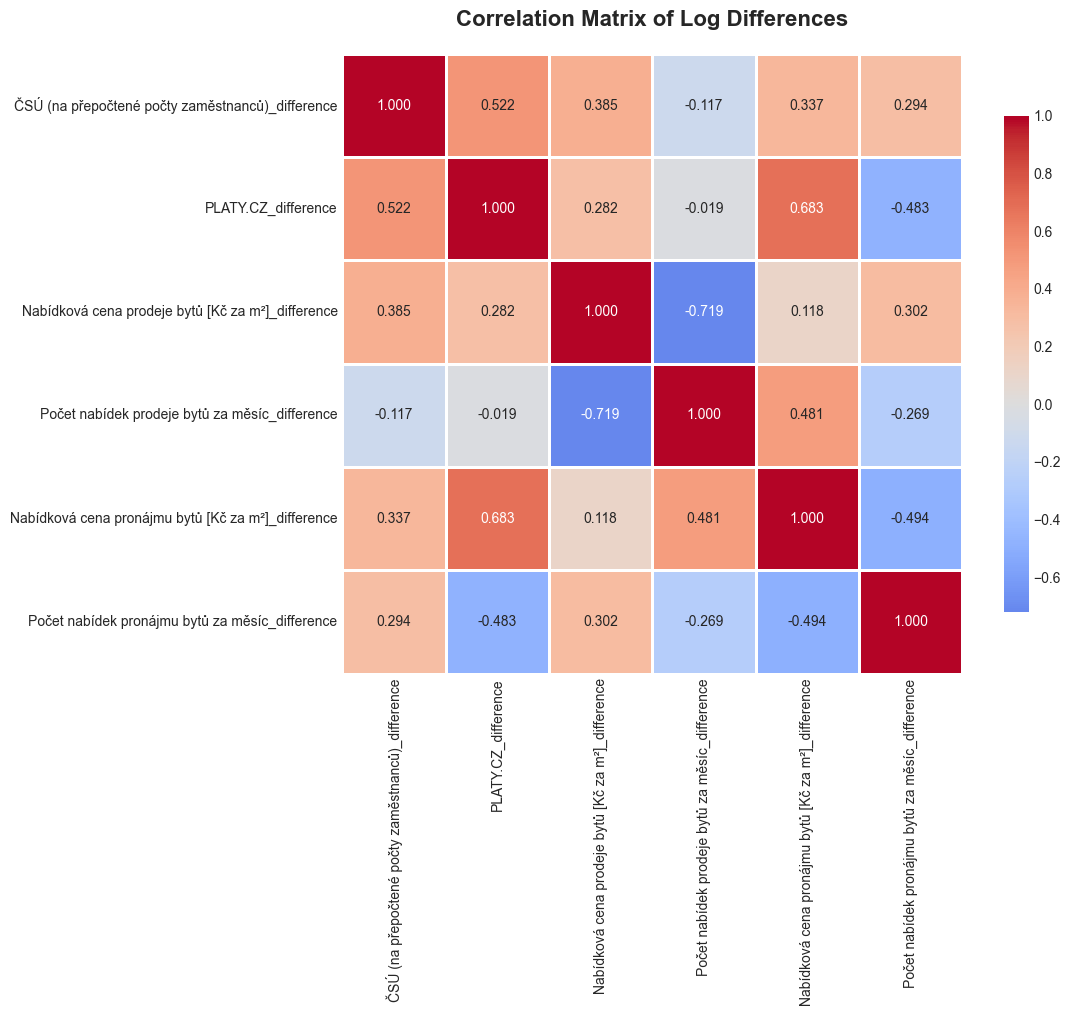

In [24]:
# Create correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Log Differences', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Analysis: Correlation Heatmap

The correlation heatmap reveals several important relationships between economic variables:

**Key Findings:**
1. **Strong Negative Correlation (-0.72)**: Sale price changes and number of sale offers move in opposite directions - when prices increase, fewer properties are offered for sale, suggesting sellers hold properties during price increases.

2. **Strong Positive Correlation (0.68)**: PLATY.CZ salary changes and rental price changes are highly correlated, indicating that rental prices respond strongly to salary changes in the job market.

3. **Moderate Positive Correlation (0.52)**: ČSÚ and PLATY.CZ salary measures are correlated, confirming both sources track similar trends.

4. **Moderate Positive Correlation (0.39)**: ČSÚ salary changes correlate with sale price changes, suggesting purchasing power affects real estate prices.

**Implications for the Future:**
- Rental markets are more responsive to salary changes than sale markets
- The inverse relationship between sale prices and offer counts suggests a supply constraint during price increases
- Salary growth is a key driver of both rental and sale price appreciation

### Pairwise Scatter Plots

Create scatter plots to visualize relationships between key variables.

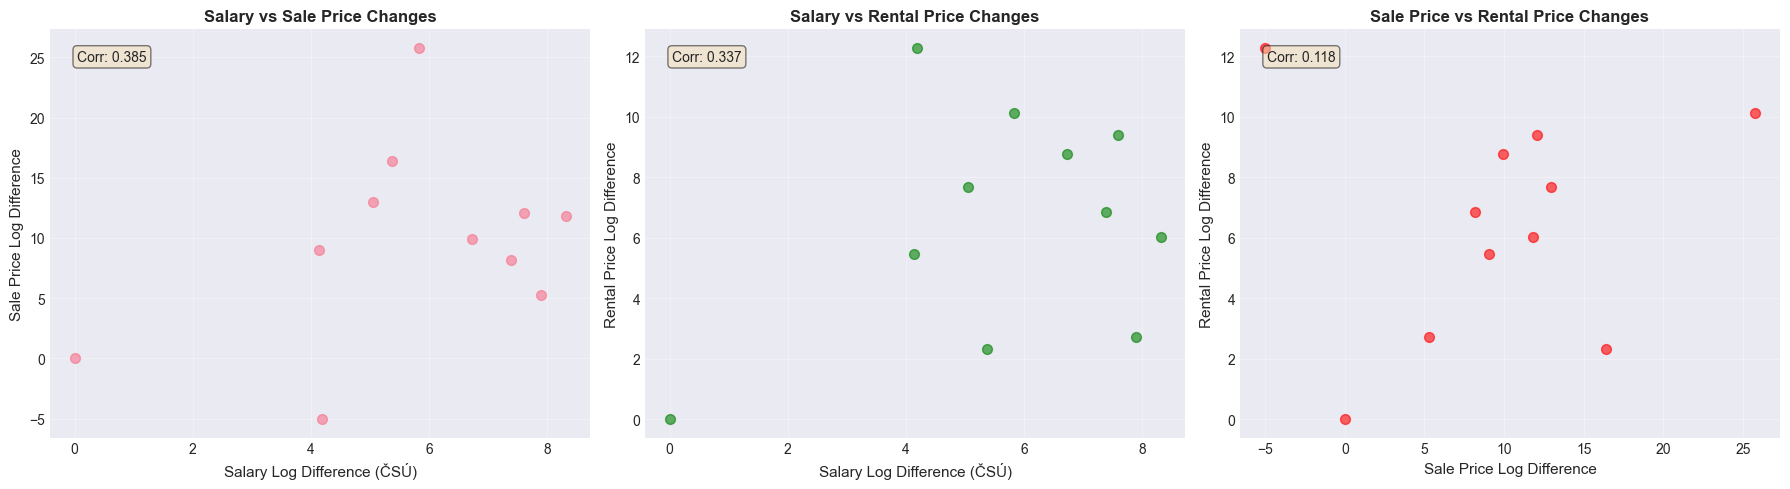

In [25]:
# Select key variables for pairwise plots
key_vars = [
    'ČSÚ (na přepočtené počty zaměstnanců)_difference',
    'Nabídková cena prodeje bytů [Kč za m²]_difference',
    'Nabídková cena pronájmu bytů [Kč za m²]_difference'
]

# Create pairwise scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Salary vs Sale Price
axes[0].scatter(df_all_diffs[key_vars[0]], df_all_diffs[key_vars[1]], alpha=0.6, s=50)
axes[0].set_xlabel('Salary Log Difference (ČSÚ)', fontsize=11)
axes[0].set_ylabel('Sale Price Log Difference', fontsize=11)
axes[0].set_title('Salary vs Sale Price Changes', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
corr_val = df_all_diffs[key_vars[0]].corr(df_all_diffs[key_vars[1]])
axes[0].text(0.05, 0.95, f'Corr: {corr_val:.3f}', transform=axes[0].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Salary vs Rental Price
axes[1].scatter(df_all_diffs[key_vars[0]], df_all_diffs[key_vars[2]], alpha=0.6, s=50, color='green')
axes[1].set_xlabel('Salary Log Difference (ČSÚ)', fontsize=11)
axes[1].set_ylabel('Rental Price Log Difference', fontsize=11)
axes[1].set_title('Salary vs Rental Price Changes', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
corr_val = df_all_diffs[key_vars[0]].corr(df_all_diffs[key_vars[2]])
axes[1].text(0.05, 0.95, f'Corr: {corr_val:.3f}', transform=axes[1].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Sale Price vs Rental Price
axes[2].scatter(df_all_diffs[key_vars[1]], df_all_diffs[key_vars[2]], alpha=0.6, s=50, color='red')
axes[2].set_xlabel('Sale Price Log Difference', fontsize=11)
axes[2].set_ylabel('Rental Price Log Difference', fontsize=11)
axes[2].set_title('Sale Price vs Rental Price Changes', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
corr_val = df_all_diffs[key_vars[1]].corr(df_all_diffs[key_vars[2]])
axes[2].text(0.05, 0.95, f'Corr: {corr_val:.3f}', transform=axes[2].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### Analysis: Pairwise Scatter Plots

The scatter plots show the relationships between key economic variables:

**Salary vs Sale Price (Correlation: 0.39):**
- Moderate positive relationship suggests that salary increases contribute to sale price growth
- Some dispersion indicates other factors (interest rates, supply, demand) also influence prices
- The relationship is not perfectly linear, suggesting non-linear dynamics

**Salary vs Rental Price (Correlation: 0.34):**
- Positive relationship indicates rental affordability is tied to income levels
- Tighter clustering than sale prices suggests more direct relationship
- Rental markets respond more directly to income changes

**Sale Price vs Rental Price (Correlation: 0.12):**
- Weak correlation suggests these markets operate somewhat independently
- Sale prices may be driven more by investment/speculation, while rentals by affordability
- This disconnect could indicate market inefficiencies or different buyer motivations

**Implications for the Future:**
- Salary growth will continue to drive both markets, but rental markets will respond more quickly
- The weak sale-rental correlation suggests potential arbitrage opportunities
- Monitoring salary trends provides early indicators for real estate price movements

### Time Series Plots of Log Differences

Visualize how log differences evolve over time for all variables.

In [26]:
df_all_diffs

,ČSÚ (na přepočtené počty zaměstnanců)_difference,PLATY.CZ_difference,Nabídková cena prodeje bytů [Kč za m²]_difference,Počet nabídek prodeje bytů za měsíc_difference,Nabídková cena pronájmu bytů [Kč za m²]_difference,Počet nabídek pronájmu bytů za měsíc_difference
2015-12-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-12-31,4.142356,9.753126,9.030231,-24.407327,5.460413,-44.890943
2017-12-31,6.720856,9.009092,9.904939,-1.704074,8.781621,-19.926128
2018-12-31,7.381900,8.890179,8.162745,6.718044,6.840273,2.263304
2019-12-31,8.309265,10.825730,11.817280,-21.673609,6.013836,-1.400714
2020-12-31,5.373301,4.712682,16.373387,-24.059297,2.307795,23.813932
2021-12-31,5.826731,9.682243,25.773860,-20.613940,10.116923,1.976388
2022-12-31,4.180539,9.036438,-5.037367,60.941175,12.273448,-31.299491
2023-12-31,7.887226,4.040426,5.285556,-0.640643,2.698814,25.762434
2024-12-31,5.056791,5.613782,12.964355,-10.389617,7.685146,-10.665837


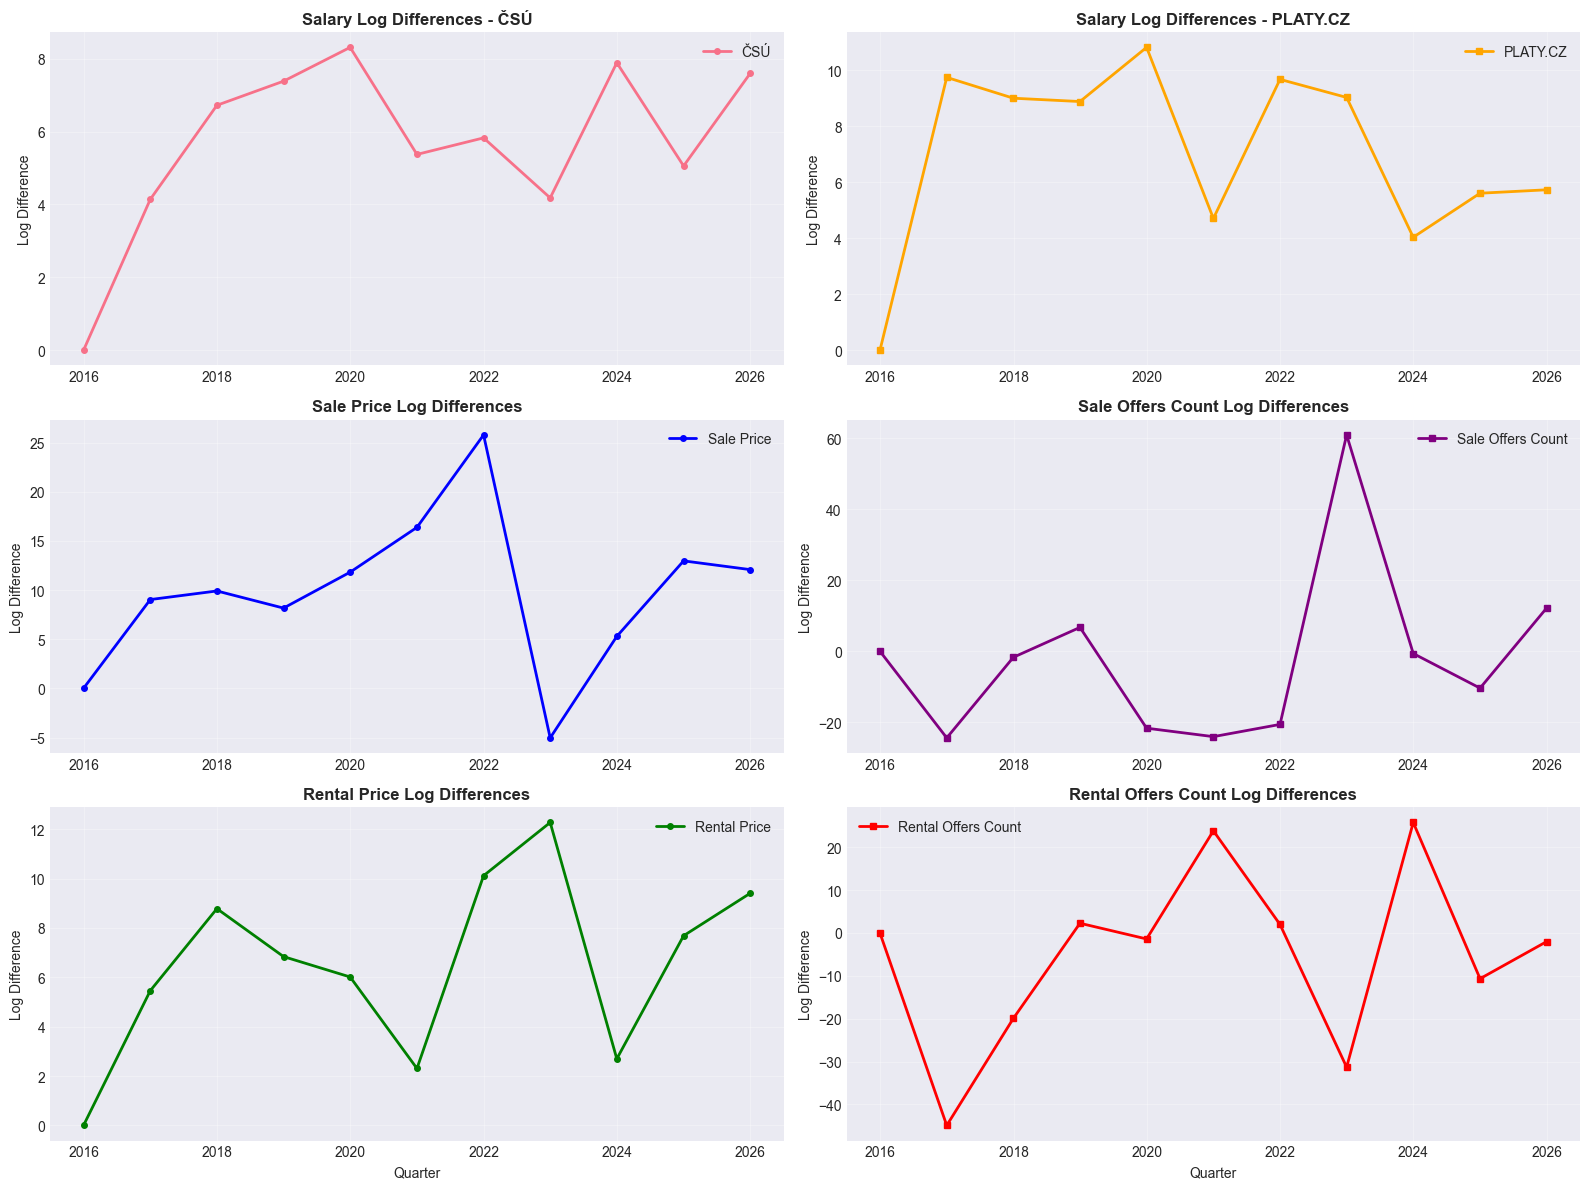

In [27]:
# Convert PeriodIndex to datetime for plotting
plot_index = df_all_diffs.index

# Create time series plots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Salary differences
axes[0, 0].plot(plot_index, df_all_diffs['ČSÚ (na přepočtené počty zaměstnanců)_difference'], 
                marker='o', linewidth=2, markersize=4, label='ČSÚ')
axes[0, 0].set_title('Salary Log Differences - ČSÚ', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Log Difference', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(plot_index, df_all_diffs['PLATY.CZ_difference'], 
                marker='s', linewidth=2, markersize=4, color='orange', label='PLATY.CZ')
axes[0, 1].set_title('Salary Log Differences - PLATY.CZ', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Log Difference', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Sale price differences
axes[1, 0].plot(plot_index, df_all_diffs['Nabídková cena prodeje bytů [Kč za m²]_difference'], 
                marker='o', linewidth=2, markersize=4, color='blue', label='Sale Price')
axes[1, 0].set_title('Sale Price Log Differences', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Log Difference', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(plot_index, df_all_diffs['Počet nabídek prodeje bytů za měsíc_difference'], 
                marker='s', linewidth=2, markersize=4, color='purple', label='Sale Offers Count')
axes[1, 1].set_title('Sale Offers Count Log Differences', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Log Difference', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# Rental price differences
axes[2, 0].plot(plot_index, df_all_diffs['Nabídková cena pronájmu bytů [Kč za m²]_difference'], 
                marker='o', linewidth=2, markersize=4, color='green', label='Rental Price')
axes[2, 0].set_title('Rental Price Log Differences', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('Log Difference', fontsize=10)
axes[2, 0].set_xlabel('Quarter', fontsize=10)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

axes[2, 1].plot(plot_index, df_all_diffs['Počet nabídek pronájmu bytů za měsíc_difference'], 
                marker='s', linewidth=2, markersize=4, color='red', label='Rental Offers Count')
axes[2, 1].set_title('Rental Offers Count Log Differences', fontsize=12, fontweight='bold')
axes[2, 1].set_ylabel('Log Difference', fontsize=10)
axes[2, 1].set_xlabel('Quarter', fontsize=10)
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend()

plt.tight_layout()
plt.show()

### Analysis: Time Series of Log Differences

The time series plots reveal temporal patterns in annual changes:

**Salary Trends:**
- Both ČSÚ and PLATY.CZ show relatively stable growth with some volatility
- PLATY.CZ shows more volatility, possibly reflecting market-sensitive salary data
- Growth rates have been positive overall, supporting real estate price appreciation

**Sale Price Trends:**
- High volatility in sale price changes, with some years showing strong growth and others decline
- Number of offers shows inverse relationship with prices (negative correlation visible)
- Recent years show more stability, possibly indicating market maturation

**Rental Price Trends:**
- More stable than sale prices, showing consistent positive growth
- Rental offer counts show moderate volatility
- Rental market appears more predictable and less speculative

**Implications for the Future:**
- Sale prices will likely continue to be more volatile than rentals
- Rental markets provide more stable investment returns
- The inverse relationship between prices and offer counts suggests supply constraints during booms

### Pairplot (All Variables)

Create a comprehensive pairplot showing relationships between all variables.

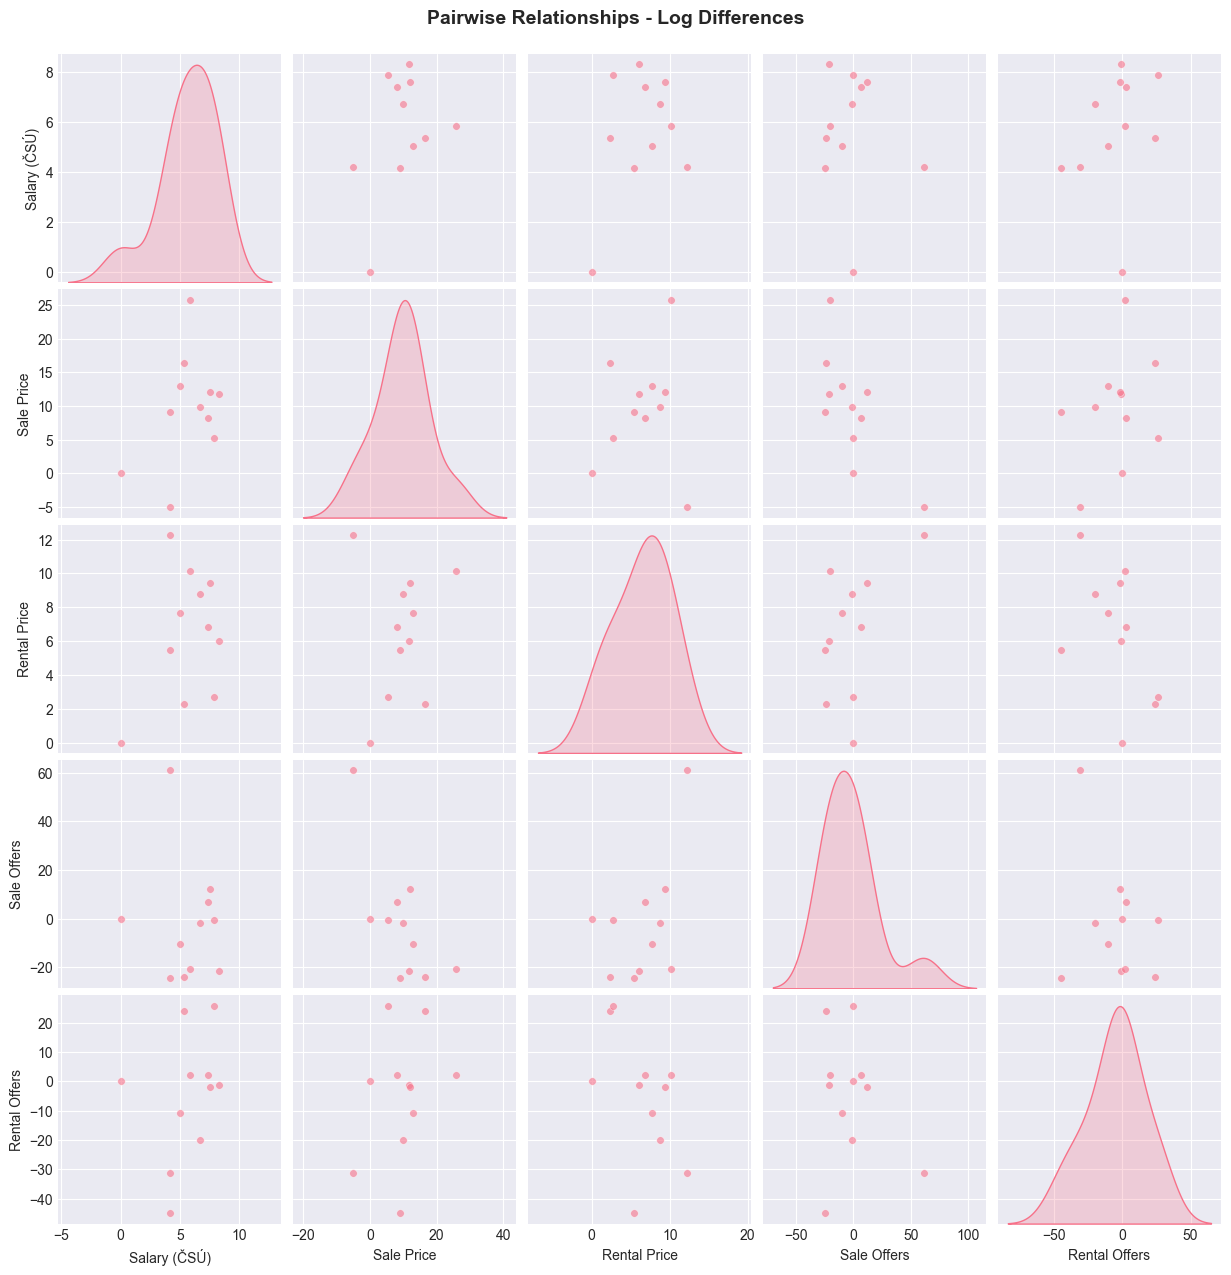

In [28]:
# Create pairplot for key variables
key_vars_pairplot = [
    'ČSÚ (na přepočtené počty zaměstnanců)_difference',
    'Nabídková cena prodeje bytů [Kč za m²]_difference',
    'Nabídková cena pronájmu bytů [Kč za m²]_difference',
    'Počet nabídek prodeje bytů za měsíc_difference',
    'Počet nabídek pronájmu bytů za měsíc_difference'
]

pairplot_df = df_all_diffs[key_vars_pairplot].copy()
# Shorten column names for better visualization
pairplot_df.columns = ['Salary (ČSÚ)', 'Sale Price', 'Rental Price', 'Sale Offers', 'Rental Offers']

sns.pairplot(pairplot_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle('Pairwise Relationships - Log Differences', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Analysis: Pairplot

The comprehensive pairplot reveals the distribution and relationships between all variables:

**Key Observations:**
1. **Distributions**: Most variables show approximately normal distributions with some skewness
2. **Sale price vs Offer count**: Strong negative relationship visible in scatter plots
3. **Rental price vs Offer count**: Moderate negative relationship, less pronounced than sales
4. **Salary relationships**: Positive correlations with both price types, stronger with rentals

**Implications for the Future:**
- The distributions suggest that log differences are reasonably well-behaved for modeling
- The negative price-offer relationships indicate supply-side constraints during price increases
- Multiple variables show similar patterns, suggesting common underlying economic drivers

### Statistical Summary

Display descriptive statistics for all difference variables.

In [29]:
# Statistical summary
print("Statistical Summary of Log Differences:")
print("="*80)
display(df_all_diffs.describe().round(2))

Statistical Summary of Log Differences:


,ČSÚ (na přepočtené počty zaměstnanců)_difference,PLATY.CZ_difference,Nabídková cena prodeje bytů [Kč za m²]_difference,Počet nabídek prodeje bytů za měsíc_difference,Nabídková cena pronájmu bytů [Kč za m²]_difference,Počet nabídek pronájmu bytů za měsíc_difference
count,11.00,11.00,11.00,11.00,11.00,11.00
mean,5.68,7.03,9.67,-2.15,6.51,-5.13
std,2.38,3.28,8.11,24.57,3.70,21.12
min,0.00,0.00,-5.04,-24.41,0.00,-44.89
25%,4.62,5.16,6.72,-21.14,4.08,-15.30
50%,5.83,8.89,9.90,-1.70,6.84,-1.40
75%,7.49,9.36,12.52,3.36,9.09,2.12
max,8.31,10.83,25.77,60.94,12.27,25.76


## Cumulative Sum of Log Differences

Calculate and visualize the cumulative sum of log differences for salary, sale price, and rental price. This shows the cumulative change over time.

### Calculate Cumulative Sums

Calculate cumulative sums of log differences for salary (ČSÚ), sale price, and rental price.

In [30]:
# Calculate cumulative sums of log differences
cumsum_salary = df_all_diffs['ČSÚ (na přepočtené počty zaměstnanců)_difference'].cumsum()
cumsum_sale_price = df_all_diffs['Nabídková cena prodeje bytů [Kč za m²]_difference'].cumsum()
cumsum_rental_price = df_all_diffs['Nabídková cena pronájmu bytů [Kč za m²]_difference'].cumsum()

# Convert index to datetime for plotting
plot_index = df_all_diffs.index

In [31]:
cumsum_rental_price

2015-12-31     0.000000
2016-12-31     5.460413
2017-12-31    14.242034
2018-12-31    21.082307
2019-12-31    27.096143
2020-12-31    29.403937
2021-12-31    39.520861
2022-12-31    51.794309
2023-12-31    54.493124
2024-12-31    62.178269
2025-12-31    71.584677
Name: Nabídková cena pronájmu bytů [Kč za m²]_difference, dtype: float64

### Plot Cumulative Sums

Visualize the cumulative sum of log differences showing the cumulative change over time.

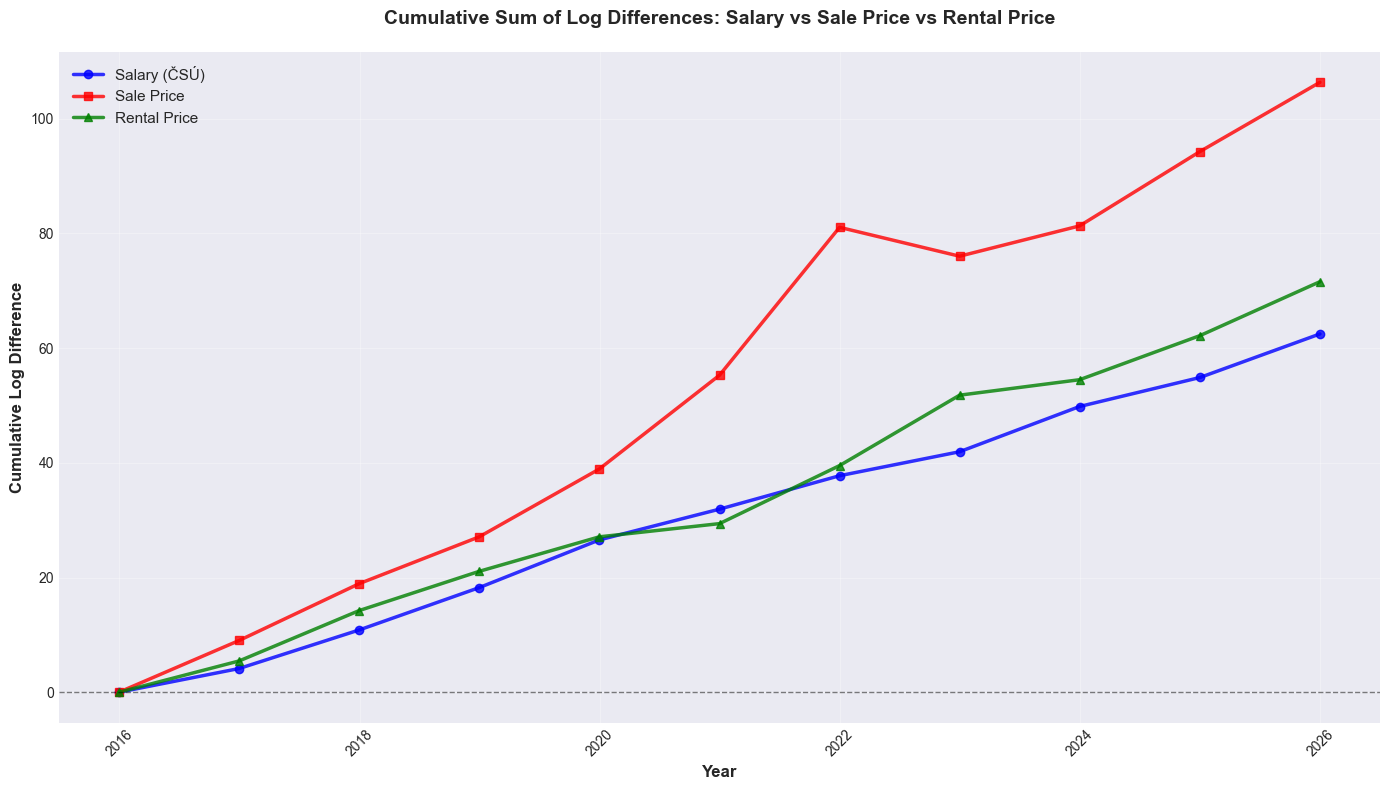

In [32]:
# Create cumulative sum plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot cumulative sums
ax.plot(plot_index, cumsum_salary, marker='o', linewidth=2.5, markersize=6, 
        label='Salary (ČSÚ)', color='blue', alpha=0.8)
ax.plot(plot_index, cumsum_sale_price, marker='s', linewidth=2.5, markersize=6, 
        label='Sale Price', color='red', alpha=0.8)
ax.plot(plot_index, cumsum_rental_price, marker='^', linewidth=2.5, markersize=6, 
        label='Rental Price', color='green', alpha=0.8)

# Add zero line
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Formatting
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Log Difference', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Sum of Log Differences: Salary vs Sale Price vs Rental Price', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis: Cumulative Sum of Log Differences

The cumulative sum plot shows the total accumulated change over time:

**Key Observations:**
1. **Salary Growth**: Steady cumulative increase, showing consistent positive growth over the period
2. **Sale Price Growth**: Strongest cumulative growth, indicating significant price appreciation
3. **Rental Price Growth**: Moderate cumulative growth, more stable than sale prices

**Relative Performance:**
- Sale prices have grown faster than salaries, suggesting affordability may be declining
- Rental prices have grown slower than sale prices, indicating different market dynamics
- The divergence between sale and rental prices suggests potential market correction or different valuation drivers

**Implications for the Future:**
- If current trends continue, sale prices may outpace salary growth, reducing affordability
- Rental markets appear more sustainable, growing in line with economic fundamentals
- The gap between sale and rental price growth may indicate overvaluation in the sale market or undervaluation in rentals

### Individual Cumulative Sum Plots

View each cumulative sum separately for better detail.

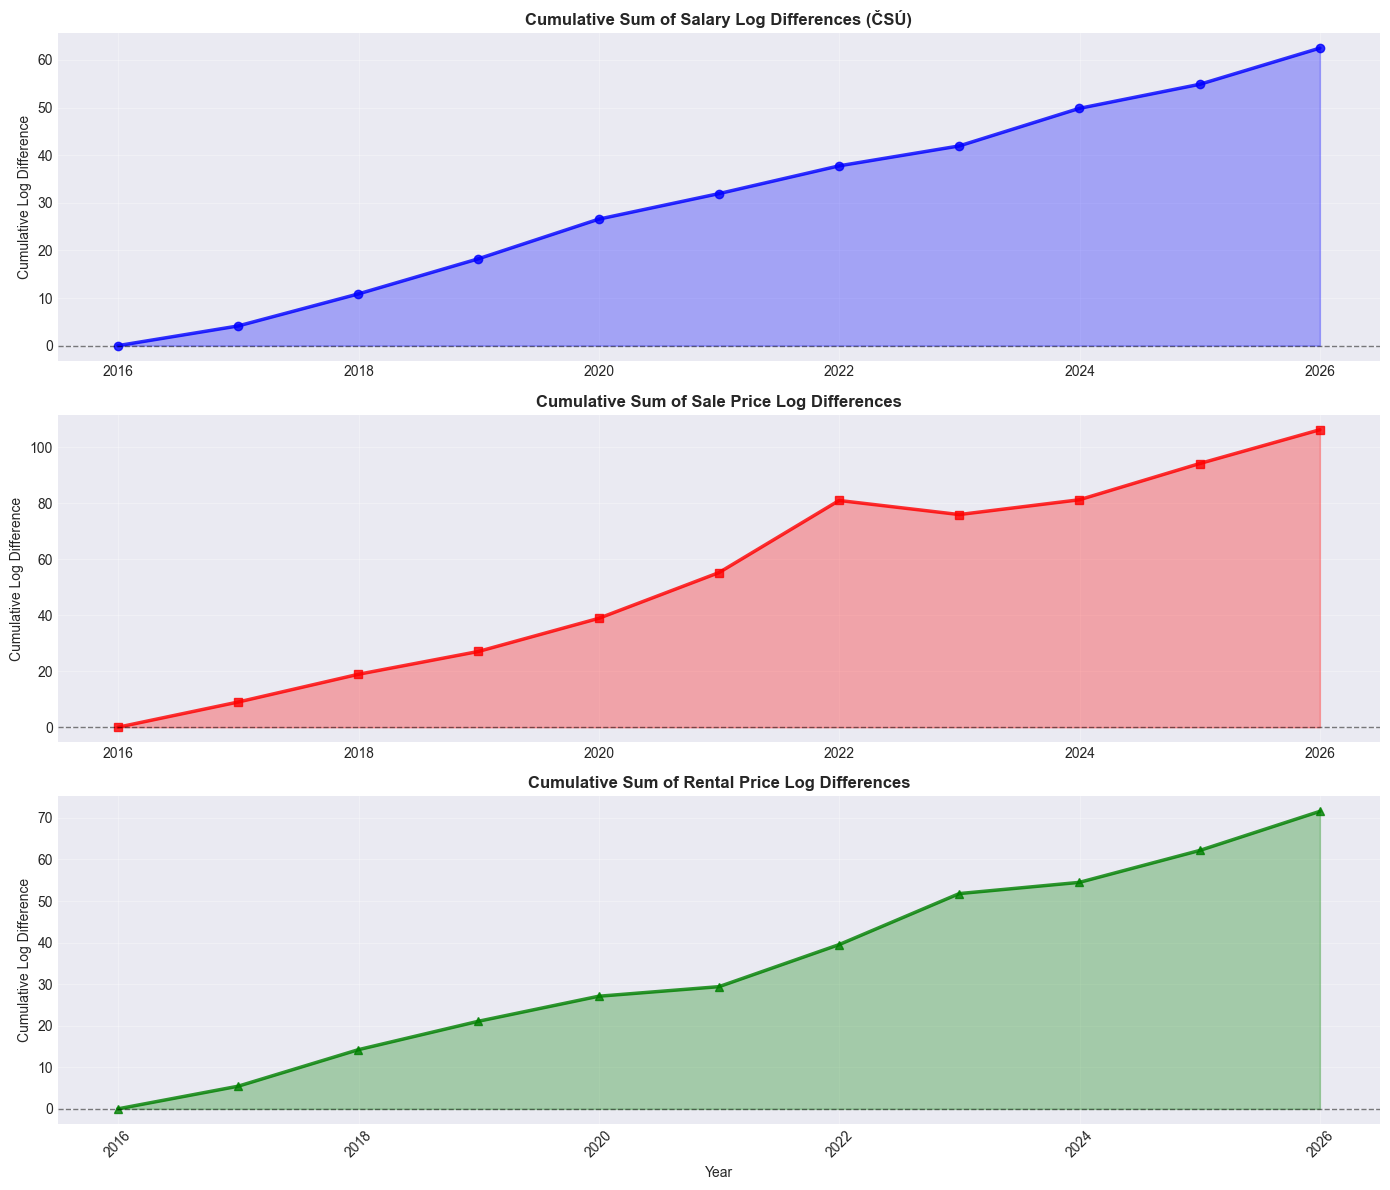

In [33]:
# Create individual plots
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Salary cumulative sum
axes[0].plot(plot_index, cumsum_salary, marker='o', linewidth=2.5, markersize=6, 
             color='blue', alpha=0.8)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title('Cumulative Sum of Salary Log Differences (ČSÚ)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cumulative Log Difference', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(plot_index, 0, cumsum_salary, alpha=0.3, color='blue')

# Sale price cumulative sum
axes[1].plot(plot_index, cumsum_sale_price, marker='s', linewidth=2.5, markersize=6, 
             color='red', alpha=0.8)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Cumulative Sum of Sale Price Log Differences', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Log Difference', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(plot_index, 0, cumsum_sale_price, alpha=0.3, color='red')

# Rental price cumulative sum
axes[2].plot(plot_index, cumsum_rental_price, marker='^', linewidth=2.5, markersize=6, 
             color='green', alpha=0.8)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_title('Cumulative Sum of Rental Price Log Differences', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Cumulative Log Difference', fontsize=10)
axes[2].set_xlabel('Year', fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].fill_between(plot_index, 0, cumsum_rental_price, alpha=0.3, color='green')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis: Individual Cumulative Sum Plots

Each individual plot provides detailed insights:

**Salary Cumulative Growth:**
- Consistent upward trajectory with minor fluctuations
- Shows steady economic growth in the region
- Provides foundation for real estate demand

**Sale Price Cumulative Growth:**
- Most volatile of the three, with periods of rapid growth
- Strong overall growth suggests strong demand or limited supply
- The volatility indicates market sensitivity to economic conditions

**Rental Price Cumulative Growth:**
- Most stable growth pattern
- Steady increase suggests sustainable market fundamentals
- Lower volatility makes rental investments more predictable

**Implications for the Future:**
- Salary growth provides sustainable demand for real estate
- Sale price volatility suggests potential for both gains and corrections
- Rental markets offer more stable long-term investment characteristics

### Box Plots

Visualize the distribution of log differences for each variable using box plots.

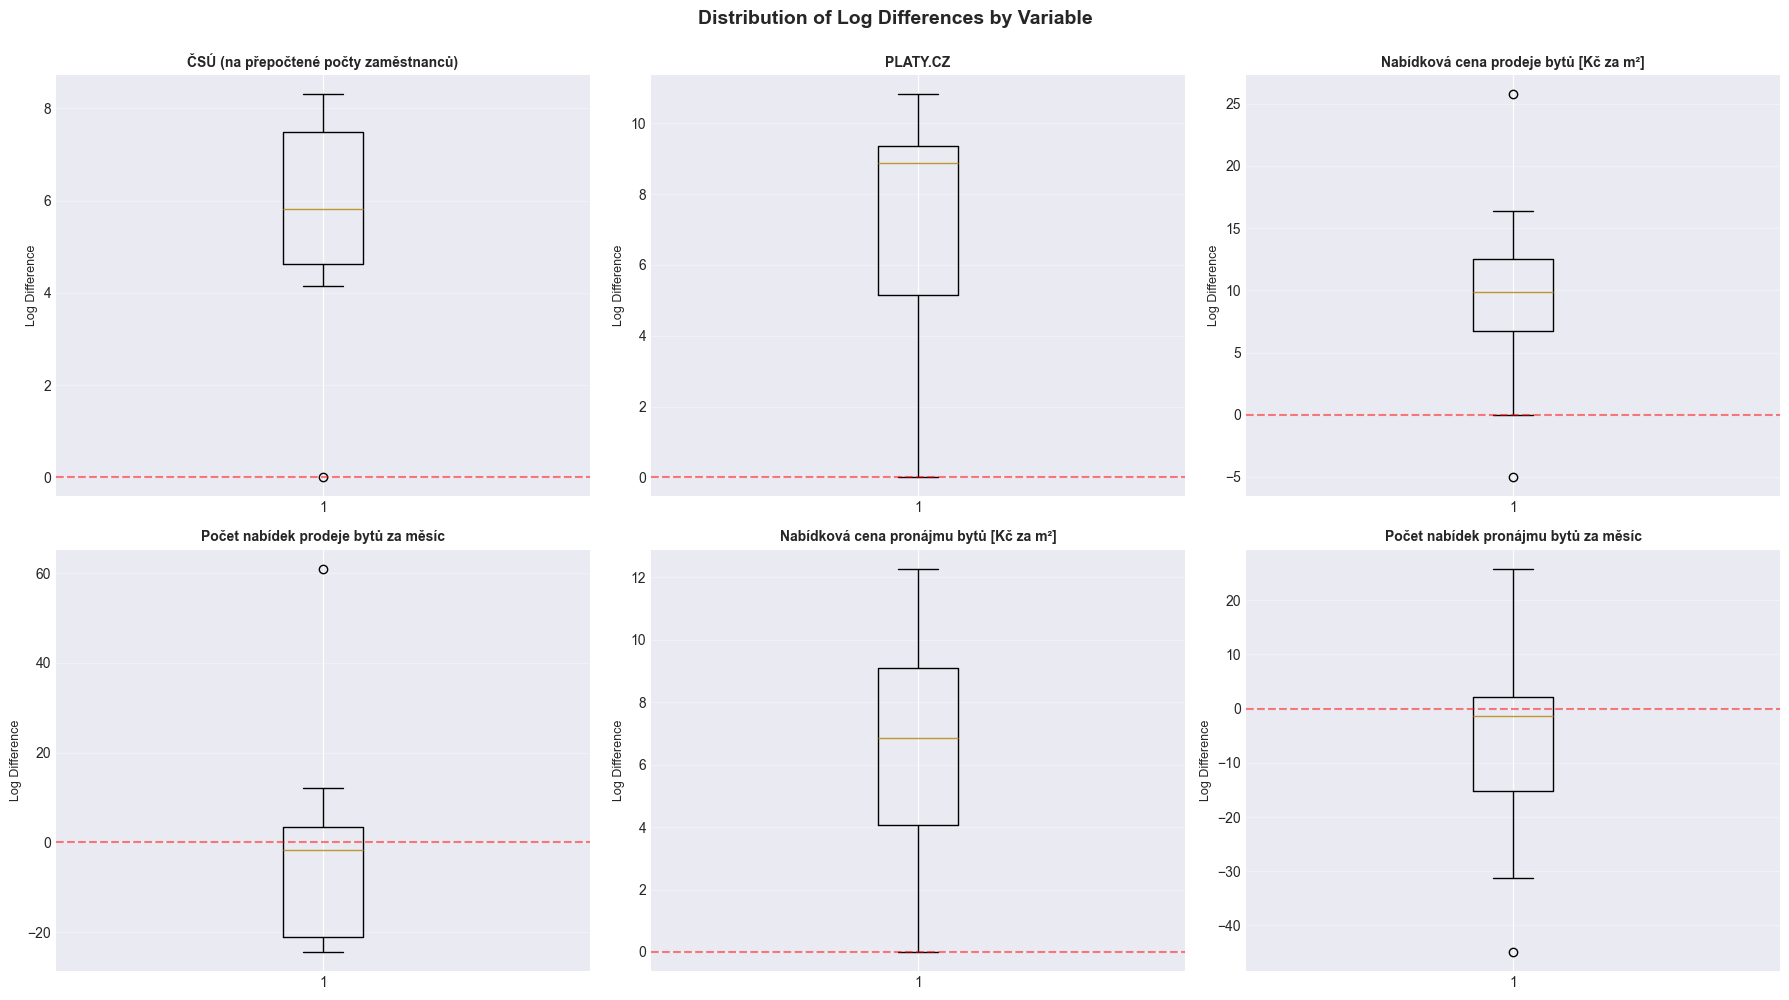

In [34]:
# Create box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Plot box plots for each variable
for idx, col in enumerate(df_all_diffs.columns):
    axes_flat[idx].boxplot(df_all_diffs[col].dropna(), vert=True)
    axes_flat[idx].set_title(col.replace('_difference', ''), fontsize=10, fontweight='bold')
    axes_flat[idx].set_ylabel('Log Difference', fontsize=9)
    axes_flat[idx].grid(True, alpha=0.3, axis='y')
    axes_flat[idx].axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.suptitle('Distribution of Log Differences by Variable', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Analysis: Box Plots of Log Differences

The box plots show the distribution characteristics of each variable:

**Key Findings:**
1. **Variability**: Sale price changes show the widest spread, indicating highest volatility
2. **Central Tendency**: Most variables are centered around positive values, indicating overall growth
3. **Outliers**: Some variables show outliers, suggesting occasional extreme years
4. **Skewness**: Distributions show varying degrees of skewness

**Implications for the Future:**
- High volatility in sale prices suggests need for risk management in investments
- Positive medians across most variables indicate continued growth expectations
- Outliers suggest occasional market shocks that should be considered in planning

# Monte Carlo Simulations

Simulate future sale price trajectories using Monte Carlo method. We'll use the historical distribution of log differences to project 20 years into the future.

In [35]:
# Monte Carlo Simulations

#Simulate future sale price trajectories using Monte Carlo method. We'll use the historical distribution of log differences to project 20 years into the future.
 
# Generate Monte Carlo trajectories
def Generate_trajectories(mean_log_diff, std_log_diff, n_steps, last_price, last_price_log):

    # Initialize array to store all trajectories
    # Shape: (n_trajectories, n_steps + 1) to include starting point (zero)
    
    n_trajectories = 1000
    trajectories = np.zeros((n_trajectories, n_steps + 1))
    trajectories_log = np.zeros((n_trajectories, n_steps + 1))

    # Generate trajectories
    for i in range(n_trajectories):
        # Draw log differences from normal distribution
        log_diffs_sim = np.random.normal(mean_log_diff, std_log_diff, n_steps)
        
        # Calculate cumulative sum of log differences, starting with zero
        cumsum_log_diffs = np.concatenate([[0], np.cumsum(log_diffs_sim)])
        
        # Convert back to price levels: price_t = price_0 * exp(cumsum_log_diffs)
        trajectory = last_price * np.exp(cumsum_log_diffs)
        
        trajectories[i, :] = trajectory
        trajectories_log[i, :]  = cumsum_log_diffs


    # Calculate 5th and 95th percentile intervals for each step
    percentile_10 = np.percentile(trajectories, 10, axis=0)
    percentile_90 = np.percentile(trajectories, 90, axis=0)
    median = np.median(trajectories, axis=0)

    # Create future years index starting from end of 2025
    future_years = pd.date_range(start='2025-12-31', periods=n_steps + 1, freq='YE')

    # Create DataFrame with results
    mc_results = pd.DataFrame({
        'Year': future_years,
        'Percentile_10': percentile_10,
        'Median': median,
        'Percentile_90': percentile_90
    })
    mc_results.set_index('Year', inplace=True)

    # Calculate 5th and 95th percentile intervals for each step (log trajectories)
    percentile_10_log = np.percentile(trajectories_log, 10, axis=0)
    percentile_90_log = np.percentile(trajectories_log, 90, axis=0)
    median_log = np.median(trajectories_log, axis=0)

    # Create DataFrame with results (log trajectories)
    mc_results_log = pd.DataFrame({
        'Year': future_years,
        'Percentile_10': percentile_10_log,
        'Median': median_log,
        'Percentile_90': percentile_90_log
    })
    mc_results_log.set_index('Year', inplace=True)
    
    # To percents
    mc_results_log = mc_results_log * 100

    # Add base
    mc_results_log = mc_results_log + last_price_log

    
    return mc_results, mc_results_log

## Future Sale Prices

In [36]:
# Generate Monte Carlo trajectories
np.random.seed(42)  # For reproducibility

n_steps = 5  # Number of future steps (years)

future_years = pd.date_range(start='2025-12-31', periods=n_steps + 1, freq='YE')

In [37]:
# Calculate distribution parameters from historical data
mean_log_diff =  0.06
std_log_diff  = 0.08

last_price = df_prodej_yearly['Nabídková cena prodeje bytů [Kč za m²]'].iloc[-1]
last_price_log = cumsum_sale_price[-1]
traj_sale, traj_sale_log = Generate_trajectories(mean_log_diff, std_log_diff, n_steps, last_price, last_price_log)

C:\Users\galet\AppData\Local\Temp\ipykernel_20652\3149931430.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_price_log = cumsum_sale_price[-1]


In [38]:
cumsum_sale_price[-1]

C:\Users\galet\AppData\Local\Temp\ipykernel_20652\3927452965.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cumsum_sale_price[-1]


np.float64(106.35061249038944)

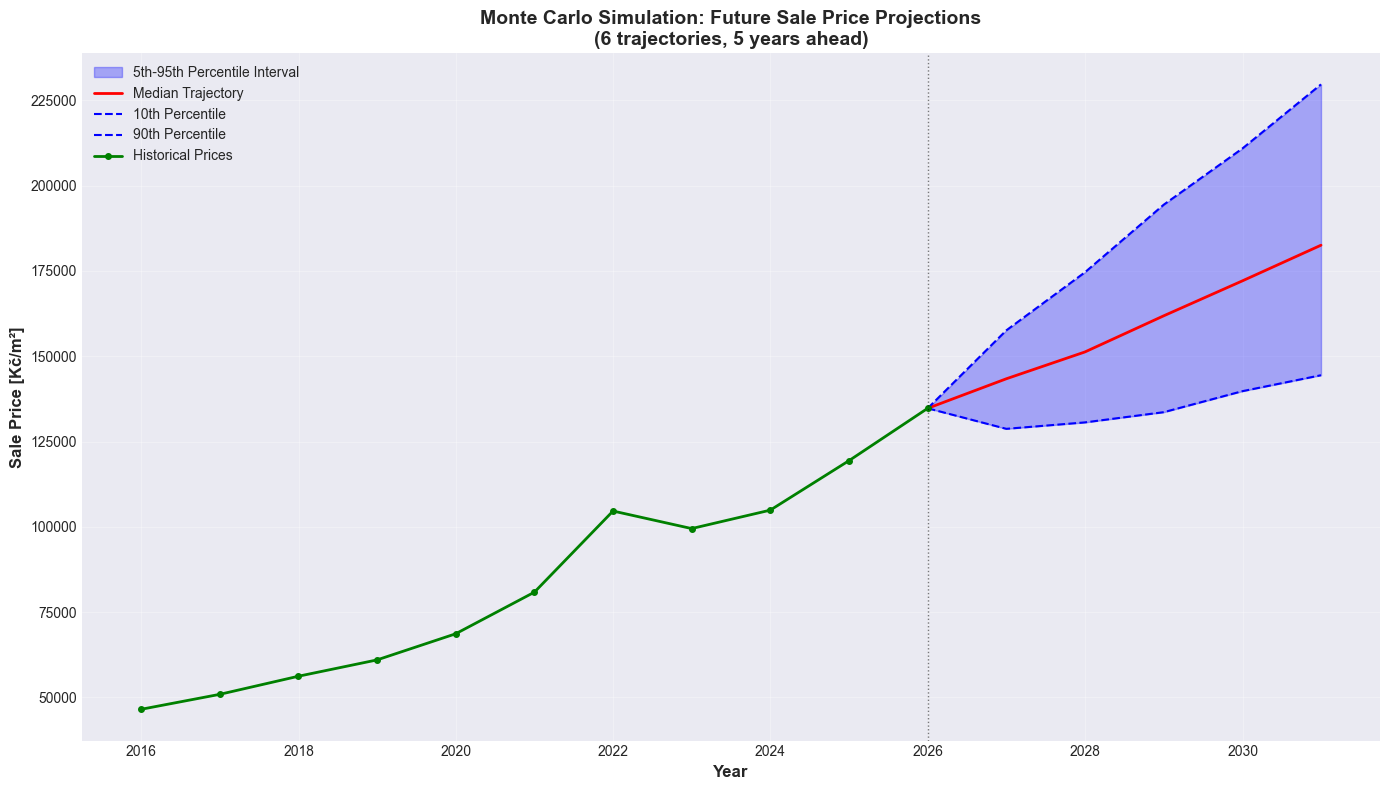

In [39]:
# Visualize Monte Carlo simulation results
fig, ax = plt.subplots(figsize=(14, 8))

# Plot percentiles
ax.fill_between(future_years, traj_sale['Percentile_10'], traj_sale['Percentile_90'], alpha=0.3, color='blue', label='5th-95th Percentile Interval')
ax.plot(future_years, traj_sale['Median'], color='red', linewidth=2, label='Median Trajectory')
ax.plot(future_years, traj_sale['Percentile_10'], color='blue', linewidth=1.5, linestyle='--', label='10th Percentile')
ax.plot(future_years, traj_sale['Percentile_90'], color='blue', linewidth=1.5, linestyle='--', label='90th Percentile')

# Plot historical data
historical_years = df_prodej_yearly.index
historical_prices = df_prodej_yearly['Nabídková cena prodeje bytů [Kč za m²]']
ax.plot(historical_years, historical_prices, color='green', linewidth=2, marker='o', label='Historical Prices', markersize=4)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price [Kč/m²]', fontsize=12, fontweight='bold')
ax.set_title(f'Monte Carlo Simulation: Future Sale Price Projections\n({len(traj_sale)} trajectories, {n_steps} years ahead)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axvline(x=historical_years[-1], color='black', linestyle=':', linewidth=1, alpha=0.5, label='Simulation Start')

plt.tight_layout()
plt.show()

### Analysis: Monte Carlo Simulation - Sale Price Projections (Levels)

The Monte Carlo simulation projects future sale prices based on historical volatility:

**Key Findings:**
1. **Median Projection**: Shows continued price growth over 5 years
2. **Uncertainty Bands**: Wide 10th-90th percentile range indicates significant uncertainty
3. **Historical Context**: Projections extend from current price levels
4. **Growth Trajectory**: Median suggests substantial price appreciation

**Implications for the Future:**
- Significant upside potential exists, but also downside risk
- The wide confidence intervals suggest high uncertainty in price forecasts
- Investors should prepare for both scenarios: continued growth or potential corrections
- The median projection suggests prices may continue rising, but with high variability

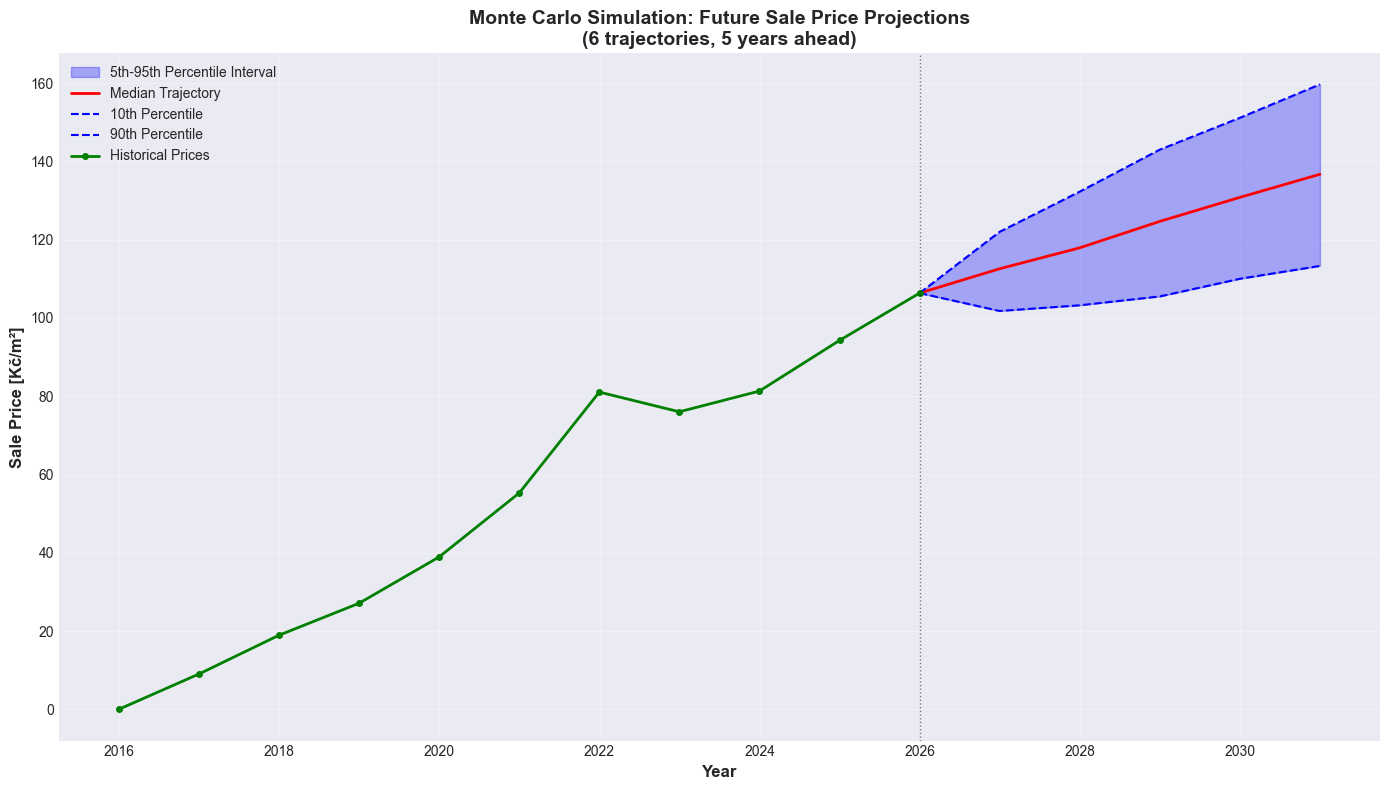

In [40]:
# Visualize Monte Carlo simulation results
fig, ax = plt.subplots(figsize=(14, 8))

# Plot percentiles
ax.fill_between(future_years, traj_sale_log['Percentile_10'], traj_sale_log['Percentile_90'], alpha=0.3, color='blue', label='5th-95th Percentile Interval')
ax.plot(future_years, traj_sale_log['Median'], color='red', linewidth=2, label='Median Trajectory')
ax.plot(future_years, traj_sale_log['Percentile_10'], color='blue', linewidth=1.5, linestyle='--', label='10th Percentile')
ax.plot(future_years, traj_sale_log['Percentile_90'], color='blue', linewidth=1.5, linestyle='--', label='90th Percentile')

# Plot historical data
historical_years = df_prodej_yearly.index
historical_prices = cumsum_sale_price
ax.plot(historical_years, historical_prices, color='green', linewidth=2, marker='o', label='Historical Prices', markersize=4)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price [Kč/m²]', fontsize=12, fontweight='bold')
ax.set_title(f'Monte Carlo Simulation: Future Sale Price Projections\n({len(traj_sale_log)} trajectories, {n_steps} years ahead)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axvline(x=historical_years[-1], color='black', linestyle=':', linewidth=1, alpha=0.5, label='Simulation Start')

plt.tight_layout()
plt.show()

In [41]:
# Display summary statistics
print("="*70)
print("MONTE CARLO SIMULATION SUMMARY")
print("="*70)
print(f"\nStarting Price: {last_price:.2f} Kč/m²")
print(f"\nAfter {n_steps} years:")
print(f"  10th Percentile:  {traj_sale['Percentile_10'][-1]:.2f} Kč/m²")
print(f"  Median:          {traj_sale['Median'][-1]:.2f} Kč/m²")
print(f"  90th Percentile: {traj_sale['Percentile_90'][-1]:.2f} Kč/m²")
print(f"\nProjected Change (Median):")
print(f"  Absolute: {traj_sale['Median'][-1] - last_price:.2f} Kč/m²")
print(f"  Relative: {(traj_sale['Median'][-1] / last_price - 1) * 100:.2f}%")

MONTE CARLO SIMULATION SUMMARY

Starting Price: 134734.00 Kč/m²

After 5 years:
  10th Percentile:  144424.46 Kč/m²
  Median:          182525.75 Kč/m²
  90th Percentile: 229656.33 Kč/m²

Projected Change (Median):
  Absolute: 47791.75 Kč/m²
  Relative: 35.47%


C:\Users\galet\AppData\Local\Temp\ipykernel_20652\1854431571.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  10th Percentile:  {traj_sale['Percentile_10'][-1]:.2f} Kč/m²")
C:\Users\galet\AppData\Local\Temp\ipykernel_20652\1854431571.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Median:          {traj_sale['Median'][-1]:.2f} Kč/m²")
C:\Users\galet\AppData\Local\Temp\ipykernel_20652\1854431571.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a 

## Parameterize Based on Real Data

Calculate distribution parameters from historical data for Monte Carlo simulations.

In [42]:
# Parametrize base on real data
# Statistical summary
print("Statistical Summary of Log Differences:")
print("="*80)
display(df_all_diffs.describe().round(2))

Statistical Summary of Log Differences:


,ČSÚ (na přepočtené počty zaměstnanců)_difference,PLATY.CZ_difference,Nabídková cena prodeje bytů [Kč za m²]_difference,Počet nabídek prodeje bytů za měsíc_difference,Nabídková cena pronájmu bytů [Kč za m²]_difference,Počet nabídek pronájmu bytů za měsíc_difference
count,11.00,11.00,11.00,11.00,11.00,11.00
mean,5.68,7.03,9.67,-2.15,6.51,-5.13
std,2.38,3.28,8.11,24.57,3.70,21.12
min,0.00,0.00,-5.04,-24.41,0.00,-44.89
25%,4.62,5.16,6.72,-21.14,4.08,-15.30
50%,5.83,8.89,9.90,-1.70,6.84,-1.40
75%,7.49,9.36,12.52,3.36,9.09,2.12
max,8.31,10.83,25.77,60.94,12.27,25.76


In [43]:
# For sale
# Calculate distribution parameters from historical data
mean_log_diff =  0.09
std_log_diff  = 0.081

last_price = df_prodej_yearly['Nabídková cena prodeje bytů [Kč za m²]'].iloc[-1]
last_price_log = cumsum_sale_price[-1]
traj_sale, traj_sale_log = Generate_trajectories(mean_log_diff, std_log_diff, n_steps, last_price, last_price_log)

#---------------------------------------------------------------------------------------
# For rental prices
# Calculate distribution parameters from historical data
mean_log_diff =  0.065
std_log_diff  = 0.037

last_price = df_pronajem_yearly['Nabídková cena pronájmu bytů [Kč za m²]'].iloc[-1]

last_price_log = cumsum_rental_price[-1]
traj_rents, traj_rents_log = Generate_trajectories(mean_log_diff, std_log_diff, n_steps, last_price, last_price_log)

#---------------------------------------------------------------------------------------
#For salary 
# Calculate distribution parameters from historical data
mean_log_diff =  0.07
std_log_diff  = 0.032

last_price = df_platy_yearly['ČSÚ (na přepočtené počty zaměstnanců)'].iloc[-1]

last_price_log = cumsum_salary[-1]

traj_salary, traj_salary_log = Generate_trajectories(mean_log_diff, std_log_diff, n_steps, last_price, last_price_log)


C:\Users\galet\AppData\Local\Temp\ipykernel_20652\3591348233.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_price_log = cumsum_sale_price[-1]
C:\Users\galet\AppData\Local\Temp\ipykernel_20652\3591348233.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_price_log = cumsum_rental_price[-1]
C:\Users\galet\AppData\Local\Temp\ipykernel_20652\3591348233.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_price_log 

### Combined Monte Carlo Projections Plot

Visualize all Monte Carlo simulation results (sale prices, rental prices, and salaries) on a single plot for comparison.

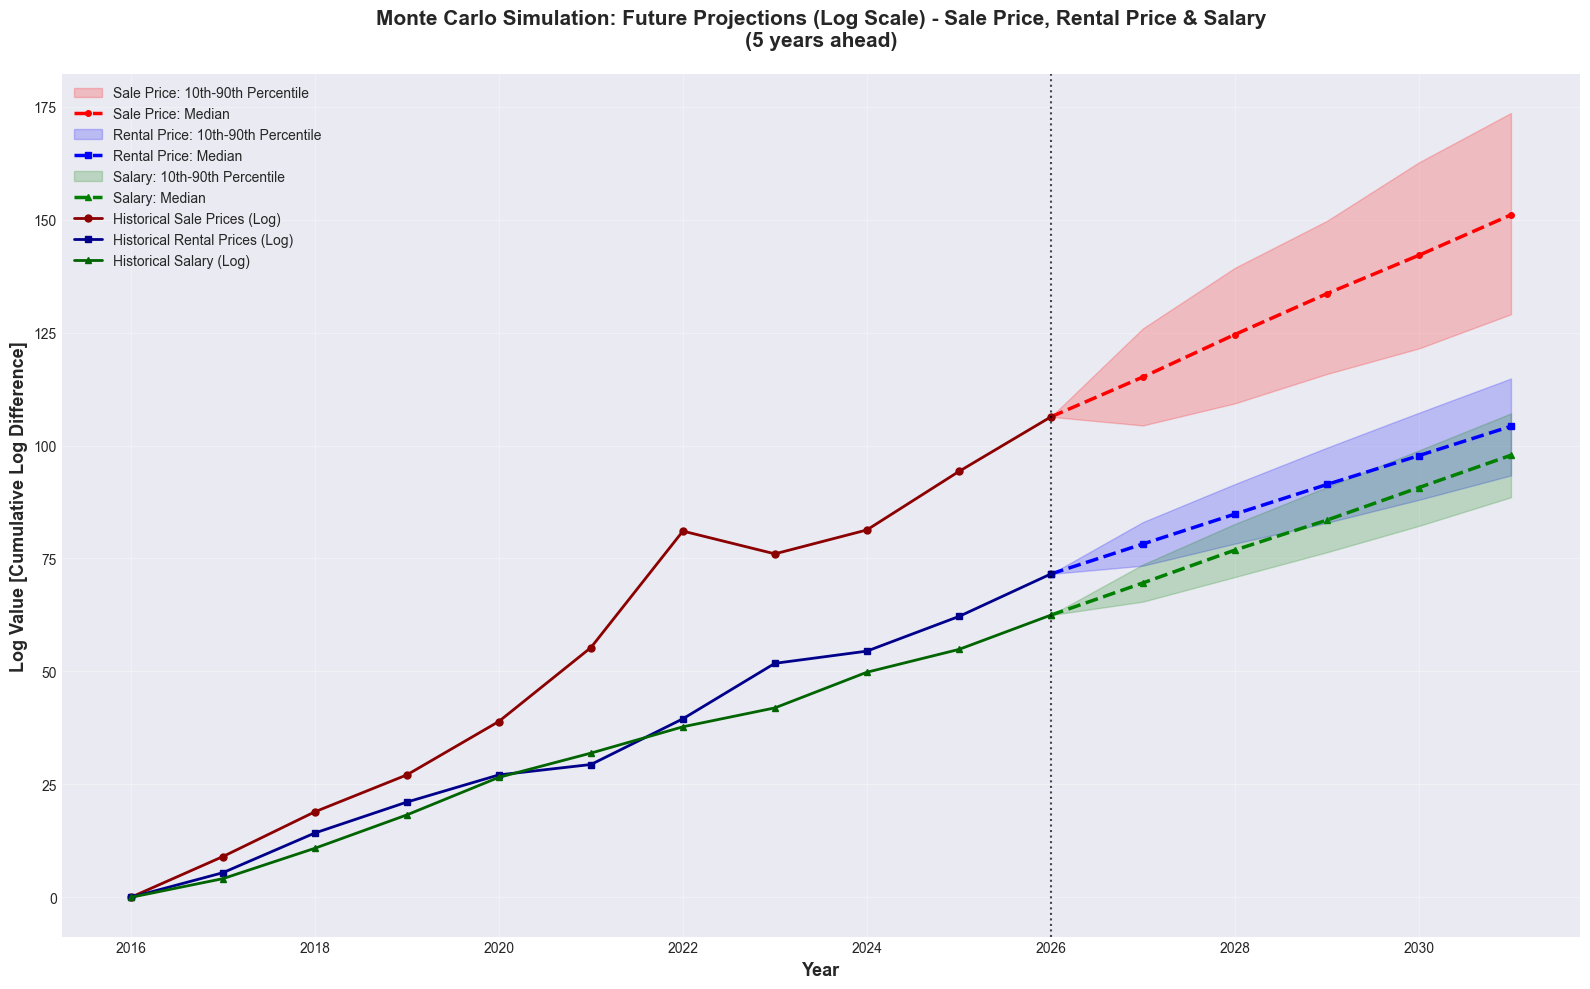

In [44]:
# Plot sales, rental income all to one plot!!!

# Visualize Monte Carlo simulation results with single y-axis
fig, ax = plt.subplots(figsize=(16, 10))

# Plot Sale Price trajectories (log)
ax.fill_between(future_years, traj_sale_log['Percentile_10'], traj_sale_log['Percentile_90'], 
                  alpha=0.2, color='red', label='Sale Price: 10th-90th Percentile')
ax.plot(future_years, traj_sale_log['Median'], color='red', linewidth=2.5, linestyle='--', 
         label='Sale Price: Median', marker='o', markersize=4)

# Plot Rental Price trajectories (log)
ax.fill_between(future_years, traj_rents_log['Percentile_10'], traj_rents_log['Percentile_90'], 
                  alpha=0.2, color='blue', label='Rental Price: 10th-90th Percentile')
ax.plot(future_years, traj_rents_log['Median'], color='blue', linewidth=2.5, linestyle='--', 
         label='Rental Price: Median', marker='s', markersize=4)

# Plot Salary trajectories (log)
ax.fill_between(future_years, traj_salary_log['Percentile_10'], traj_salary_log['Percentile_90'], 
                 alpha=0.2, color='green', label='Salary: 10th-90th Percentile')
ax.plot(future_years, traj_salary_log['Median'], color='green', linewidth=2.5, linestyle='--', 
         label='Salary: Median', marker='^', markersize=4)

# Plot historical data (log)
historical_years = df_prodej_yearly.index
historical_sale_prices_log = cumsum_sale_price
historical_rental_prices_log = cumsum_rental_price
historical_salary_log = cumsum_salary

ax.plot(historical_years, historical_sale_prices_log, color='darkred', linewidth=2, 
         marker='o', label='Historical Sale Prices (Log)', markersize=5, linestyle='-')
ax.plot(historical_years, historical_rental_prices_log, color='darkblue', linewidth=2, 
         marker='s', label='Historical Rental Prices (Log)', markersize=5, linestyle='-')
ax.plot(historical_years, historical_salary_log, color='darkgreen', linewidth=2, 
         marker='^', label='Historical Salary (Log)', markersize=5, linestyle='-')

ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Log Value [Cumulative Log Difference]', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

ax.set_title(f'Monte Carlo Simulation: Future Projections (Log Scale) - Sale Price, Rental Price & Salary\n({n_steps} years ahead)', 
             fontsize=15, fontweight='bold', pad=20)
ax.axvline(x=historical_years[-1], color='black', linestyle=':', linewidth=1.5, alpha=0.7, label='Simulation Start')

plt.tight_layout()
plt.show()

### Analysis: Combined Monte Carlo Projections

The combined plot allows comparison of sale prices, rental prices, and salaries:

**Key Observations:**
1. **Divergence**: Sale prices show the strongest projected growth, followed by salaries, then rentals
2. **Volatility**: Sale prices have the widest uncertainty bands, rentals the narrowest
3. **Convergence/Divergence**: The trajectories show different growth rates, which may indicate market imbalances

**Implications for the Future:**
- **Affordability Concerns**: If sale prices grow faster than salaries, housing affordability will decline
- **Investment Strategy**: Rental yields may improve if rental prices grow slower than sale prices
- **Market Sustainability**: The divergence suggests potential market correction if prices outpace fundamentals
- **Risk Assessment**: Sale price investments carry higher risk (wider bands) but potentially higher returns
- **Rental Market**: More stable growth suggests sustainable rental market fundamentals

In [45]:
cumsum_salary

2015-12-31     0.000000
2016-12-31     4.142356
2017-12-31    10.863213
2018-12-31    18.245112
2019-12-31    26.554377
2020-12-31    31.927679
2021-12-31    37.754410
2022-12-31    41.934948
2023-12-31    49.822175
2024-12-31    54.878966
2025-12-31    62.475804
Name: ČSÚ (na přepočtené počty zaměstnanců)_difference, dtype: float64

# Economic Entities Analysis (Ekonomické Subjekty Brno)

Analyze economic entities data to understand business trends, company size distributions, and growth patterns in Brno.

In [46]:
# Load economic entities data
df_ekonomicke = pd.read_csv('ekonomicke_subjekty_brno.csv', index_col=0)

# Display first few rows
print("Raw data shape:", df_ekonomicke.shape)
print("\nFirst few rows:")
df_ekonomicke.head()

Raw data shape: (21, 19)

First few rows:


,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
celkem,56 736,61 984,61 635,64 802,68 410,71 078,69 409,68 546,67 816,67 838,70 920,72 781,74 700,76 480,79 053,81 863,84 637,88 205,92 580
neuvedeno,13 345,13 847,12 119,14 200,15 933,18 570,18 646,16 896,16 317,15 892,18 150,18 783,19 511,20 178,21 055,22 120,23 688,22 394,22 869
bez zaměstnanců,28 302,32 578,34 106,35 053,36 683,36 386,34 883,35 330,35 182,35 071,35 673,36 767,37 521,39 209,40 797,41 934,43 519,43 957,46 161
1 - 5,10 140,10 370,10 451,10 488,10 774,11 256,11 097,11 547,11 465,11 929,11 979,12 109,12 540,12 058,12 054,12 541,12 163,14 345,15 426
6 - 9,1 658,1 744,1 740,1 763,1 731,1 713,1 695,1 634,1 710,1 733,1 819,1 773,1 749,1 727,1 752,1 778,1 746,2 644,2 849


### Data Cleaning and Preparation

Clean the data by removing spaces (thousand separators), handling special characters, and transposing for easier analysis.

In [47]:
# Transpose the dataframe so years are rows and categories are columns
df_ekonomicke = df_ekonomicke.T

# Convert column names (years) to datetime index
df_ekonomicke.index = pd.to_datetime(df_ekonomicke.index, format='%Y')

# Clean numeric columns: remove spaces, handle special characters
for col in df_ekonomicke.columns:
    # Replace spaces (thousand separators)
    df_ekonomicke[col] = df_ekonomicke[col].astype(str).str.replace(' ', '')
    # Replace special characters with NaN
    df_ekonomicke[col] = df_ekonomicke[col].replace(['-', '.', ''], np.nan)
    # Convert to numeric
    df_ekonomicke[col] = pd.to_numeric(df_ekonomicke[col], errors='coerce')

print("Cleaned data shape:", df_ekonomicke.shape)
print("\nColumn names (categories):")
print(list(df_ekonomicke.columns))
print("\nDate range:", df_ekonomicke.index.min(), "to", df_ekonomicke.index.max())
print("\nFirst few rows:")
df_ekonomicke.head()

Cleaned data shape: (19, 21)

Column names (categories):
['celkem', 'neuvedeno', 'bez zaměstnanců', '1 - 5', '6 - 9', '10 - 19', '20 - 24', '25 - 49', '50 - 99', '100 - 199', '200 - 249', '250 - 499', '500 - 999', '1000 - 1499', '1500 - 1999', '2000 - 2499', '2500 - 2999', '3000 - 3999', '4000 - 4999', '5000 - 9999', '10000 a více']

Date range: 2007-01-01 00:00:00 to 2025-01-01 00:00:00

First few rows:


,celkem,neuvedeno,bez zaměstnanců,1 - 5,6 - 9,10 - 19,20 - 24,25 - 49,50 - 99,100 - 199,...,250 - 499,500 - 999,1000 - 1499,1500 - 1999,2000 - 2499,2500 - 2999,3000 - 3999,4000 - 4999,5000 - 9999,10000 a více
2007-01-01,56736,13345,28302,10140,1658,1558,350,665,363,188,...,62,40,6,3,2,2,3,1.0,1,1.0
2008-01-01,61984,13847,32578,10370,1744,1651,355,694,375,200,...,63,42,8,4,1,3,3,1.0,1,1.0
2009-01-01,61635,12119,34106,10451,1740,1539,328,638,360,190,...,63,40,9,3,1,2,5,1.0,1,1.0
2010-01-01,64802,14200,35053,10488,1763,1594,315,668,369,186,...,63,43,5,2,3,1,5,NaN,2,1.0
2011-01-01,68410,15933,36683,10774,1731,1603,332,660,355,179,...,65,37,7,4,2,3,3,NaN,2,1.0


### Data Overview and Summary Statistics

In [48]:
# Display summary statistics
print("="*80)
print("ECONOMIC ENTITIES DATA - SUMMARY STATISTICS")
print("="*80)
print(f"\nTotal number of categories: {len(df_ekonomicke.columns)}")
print(f"Time period: {df_ekonomicke.index.min().year} - {df_ekonomicke.index.max().year}")
print(f"Number of years: {len(df_ekonomicke)}")

print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)
display(df_ekonomicke.describe().round(0))

print("\n" + "="*80)
print("TOTAL ENTITIES OVER TIME (celkem)")
print("="*80)
if 'celkem' in df_ekonomicke.columns:
    print(df_ekonomicke['celkem'].describe().round(0))

ECONOMIC ENTITIES DATA - SUMMARY STATISTICS

Total number of categories: 21
Time period: 2007 - 2025
Number of years: 19

DESCRIPTIVE STATISTICS


,celkem,neuvedeno,bez zaměstnanců,1 - 5,6 - 9,10 - 19,20 - 24,25 - 49,50 - 99,100 - 199,...,250 - 499,500 - 999,1000 - 1499,1500 - 1999,2000 - 2499,2500 - 2999,3000 - 3999,4000 - 4999,5000 - 9999,10000 a více
count,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,...,19.0,19.0,19.0,19.0,19.0,19.0,19.0,17.0,19.0,6.0
mean,72604.0,18132.0,37322.0,11828.0,1840.0,1658.0,360.0,717.0,386.0,189.0,...,67.0,42.0,9.0,3.0,3.0,1.0,3.0,2.0,2.0,1.0
std,9354.0,3419.0,4351.0,1322.0,324.0,283.0,65.0,135.0,55.0,22.0,...,6.0,7.0,4.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0
min,56736.0,12119.0,28302.0,10140.0,1634.0,1456.0,315.0,623.0,339.0,171.0,...,59.0,34.0,5.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0
25%,67827.0,15912.0,35062.0,10936.0,1720.0,1535.0,329.0,652.0,360.0,176.0,...,63.0,37.0,6.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0
50%,70920.0,18570.0,36386.0,11929.0,1744.0,1593.0,344.0,668.0,373.0,183.0,...,67.0,40.0,9.0,3.0,2.0,1.0,3.0,2.0,2.0,1.0
75%,77766.0,20616.0,40003.0,12136.0,1768.0,1618.0,352.0,707.0,386.0,191.0,...,72.0,44.0,12.0,4.0,3.0,2.0,4.0,3.0,3.0,1.0
max,92580.0,23688.0,46161.0,15426.0,2849.0,2553.0,563.0,1128.0,552.0,254.0,...,77.0,59.0,16.0,7.0,5.0,3.0,5.0,4.0,4.0,1.0



TOTAL ENTITIES OVER TIME (celkem)
count       19.0
mean     72604.0
std       9354.0
min      56736.0
25%      67827.0
50%      70920.0
75%      77766.0
max      92580.0
Name: celkem, dtype: float64


### Visualization 1: Total Economic Entities Trend

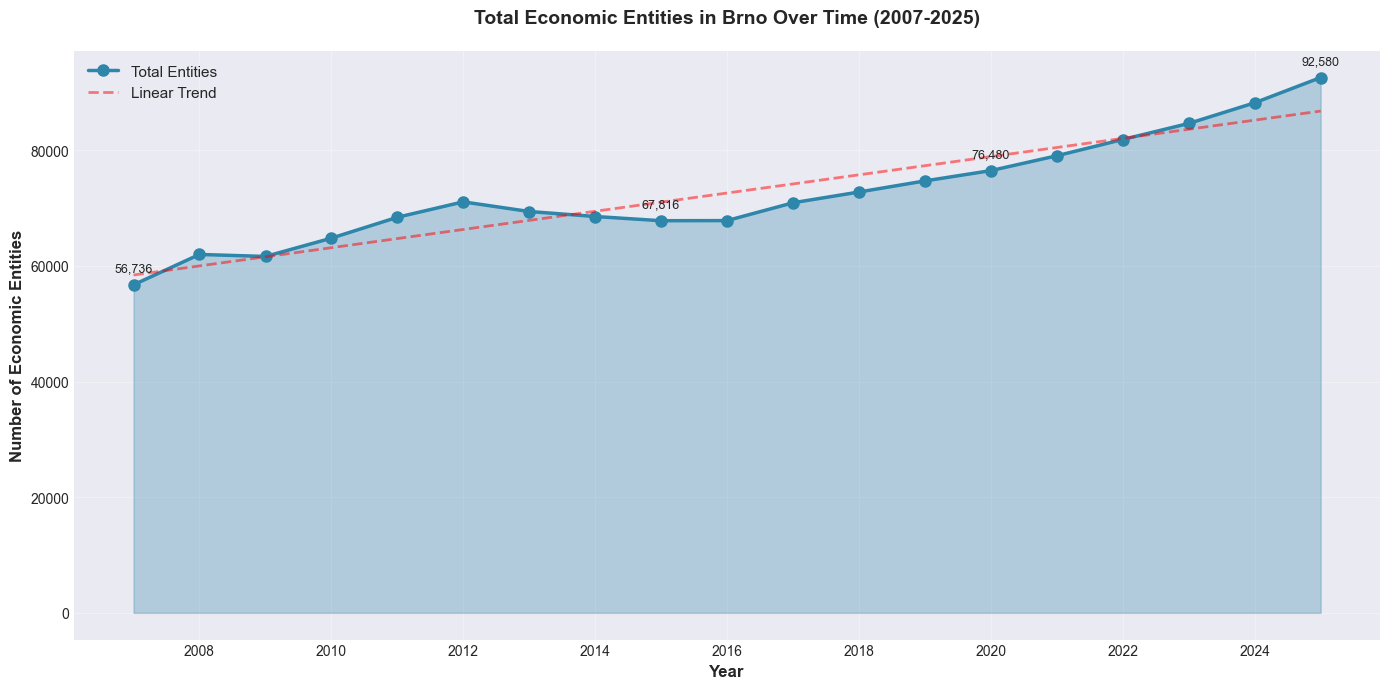


Total Growth (2007-2025): 63.18%
Average Annual Growth: 3.51%


In [49]:
# Plot total economic entities over time
fig, ax = plt.subplots(figsize=(14, 7))

if 'celkem' in df_ekonomicke.columns:
    ax.plot(df_ekonomicke.index, df_ekonomicke['celkem'], 
            marker='o', linewidth=2.5, markersize=8, color='#2E86AB', label='Total Entities')
    
    # Add trend line
    z = np.polyfit(range(len(df_ekonomicke)), df_ekonomicke['celkem'], 1)
    p = np.poly1d(z)
    ax.plot(df_ekonomicke.index, p(range(len(df_ekonomicke))), 
            "--", alpha=0.5, color='red', linewidth=2, label='Linear Trend')
    
    # Fill area under curve
    ax.fill_between(df_ekonomicke.index, df_ekonomicke['celkem'], alpha=0.3, color='#2E86AB')
    
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Economic Entities', fontsize=12, fontweight='bold')
    ax.set_title('Total Economic Entities in Brno Over Time (2007-2025)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    # Add value annotations for key years
    for year in [2007, 2015, 2020, 2025]:
        if pd.Timestamp(f'{year}-01-01') in df_ekonomicke.index:
            idx = df_ekonomicke.index.get_loc(pd.Timestamp(f'{year}-01-01'))
            ax.annotate(f'{int(df_ekonomicke["celkem"].iloc[idx]):,}', 
                       (df_ekonomicke.index[idx], df_ekonomicke['celkem'].iloc[idx]),
                       textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate growth rate
if 'celkem' in df_ekonomicke.columns:
    total_growth = ((df_ekonomicke['celkem'].iloc[-1] / df_ekonomicke['celkem'].iloc[0]) - 1) * 100
    print(f"\nTotal Growth (2007-2025): {total_growth:.2f}%")
    print(f"Average Annual Growth: {(total_growth / (len(df_ekonomicke) - 1)):.2f}%")

### Analysis: Total Economic Entities Trend

The total economic entities trend shows strong growth in Brno's business ecosystem:

**Key Findings:**
1. **Steady Growth**: 63% growth from 2007 to 2025 indicates a thriving business environment
2. **Linear Trend**: The consistent upward trajectory suggests sustainable economic expansion
3. **Acceleration**: Recent years show continued growth, indicating strong economic momentum

**Implications for the Future:**
- Continued business growth will drive demand for commercial and residential real estate
- More businesses mean more employment opportunities, supporting population and salary growth
- The growth trend suggests Brno is an attractive location for entrepreneurs and businesses
- This economic activity supports long-term real estate value appreciation

### Visualization 2: Distribution by Company Size (Stacked Area Chart)

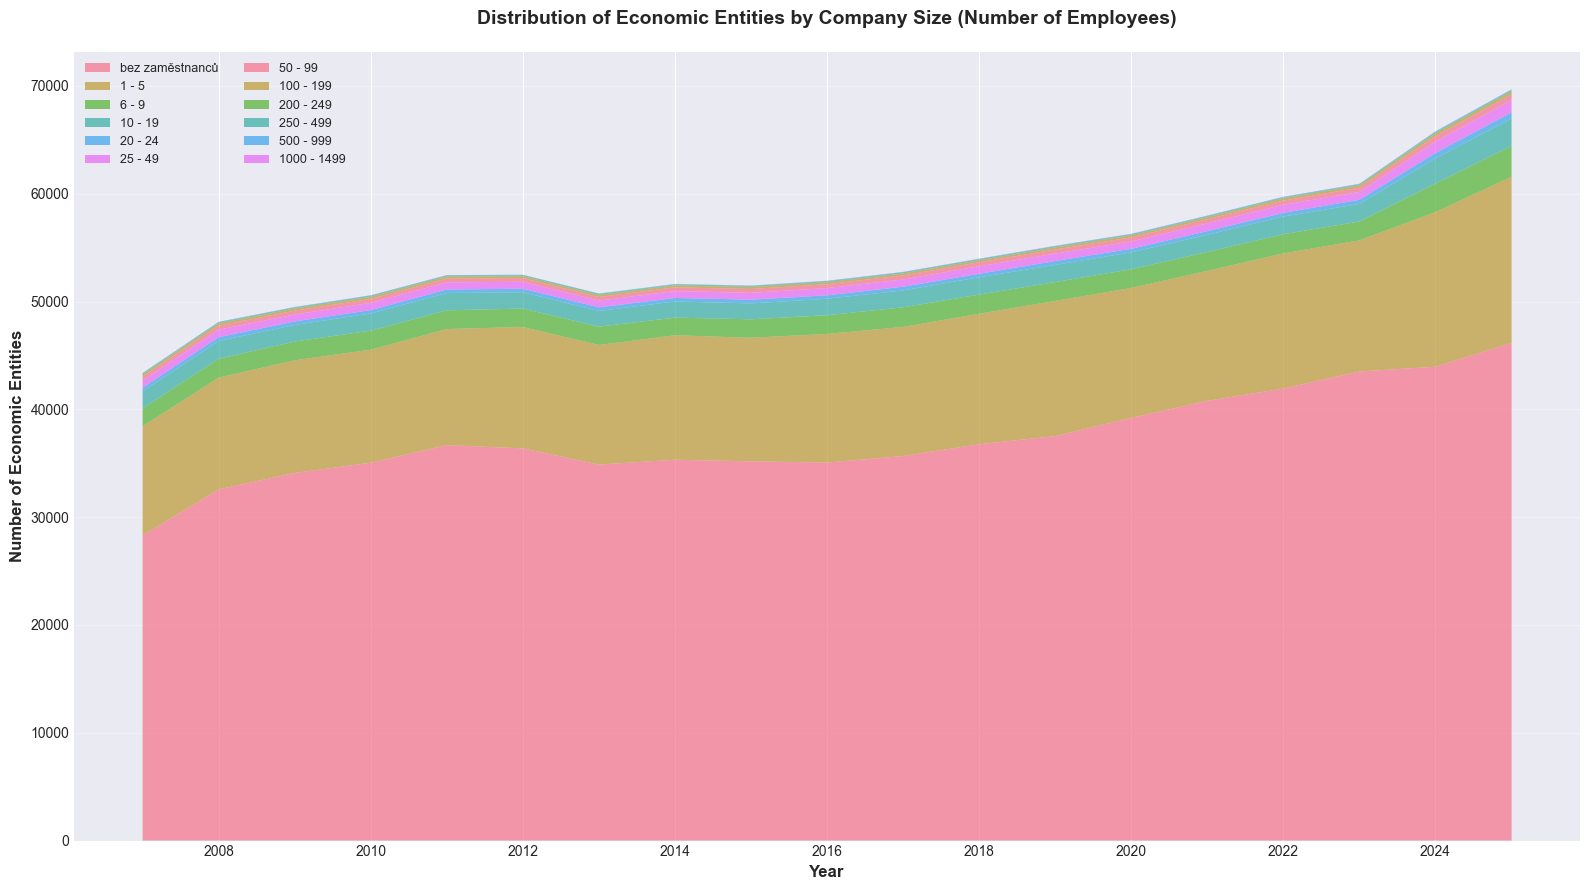

In [50]:
# Create stacked area chart showing distribution by company size
# Select key categories for visualization
key_categories = ['bez zaměstnanců', '1 - 5', '6 - 9', '10 - 19', '20 - 24', 
                  '25 - 49', '50 - 99', '100 - 199', '200 - 249', '250 - 499', 
                  '500 - 999', '1000 - 1499']

# Filter to only include categories that exist in the data
available_categories = [cat for cat in key_categories if cat in df_ekonomicke.columns]

fig, ax = plt.subplots(figsize=(16, 9))

# Create stacked area plot
ax.stackplot(df_ekonomicke.index, 
             *[df_ekonomicke[cat] for cat in available_categories],
             labels=available_categories,
             alpha=0.7)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Economic Entities', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Economic Entities by Company Size (Number of Employees)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Analysis: Distribution by Company Size

The stacked area chart reveals the composition of Brno's business ecosystem:

**Key Findings:**
1. **Small Business Dominance**: Companies with few employees (1-19) form the largest segment
2. **Micro-enterprises**: Companies without employees (sole proprietorships) are the largest single category
3. **Growth Across Sizes**: All size categories show growth, indicating a diverse and healthy economy

**Implications for the Future:**
- Small businesses drive local economic activity and employment
- The dominance of micro-enterprises suggests a flexible, entrepreneurial economy
- Diverse company sizes indicate a robust economic ecosystem less vulnerable to single-industry shocks
- This diversity supports stable demand for various types of commercial real estate

### Visualization 3: Percentage Distribution by Company Size

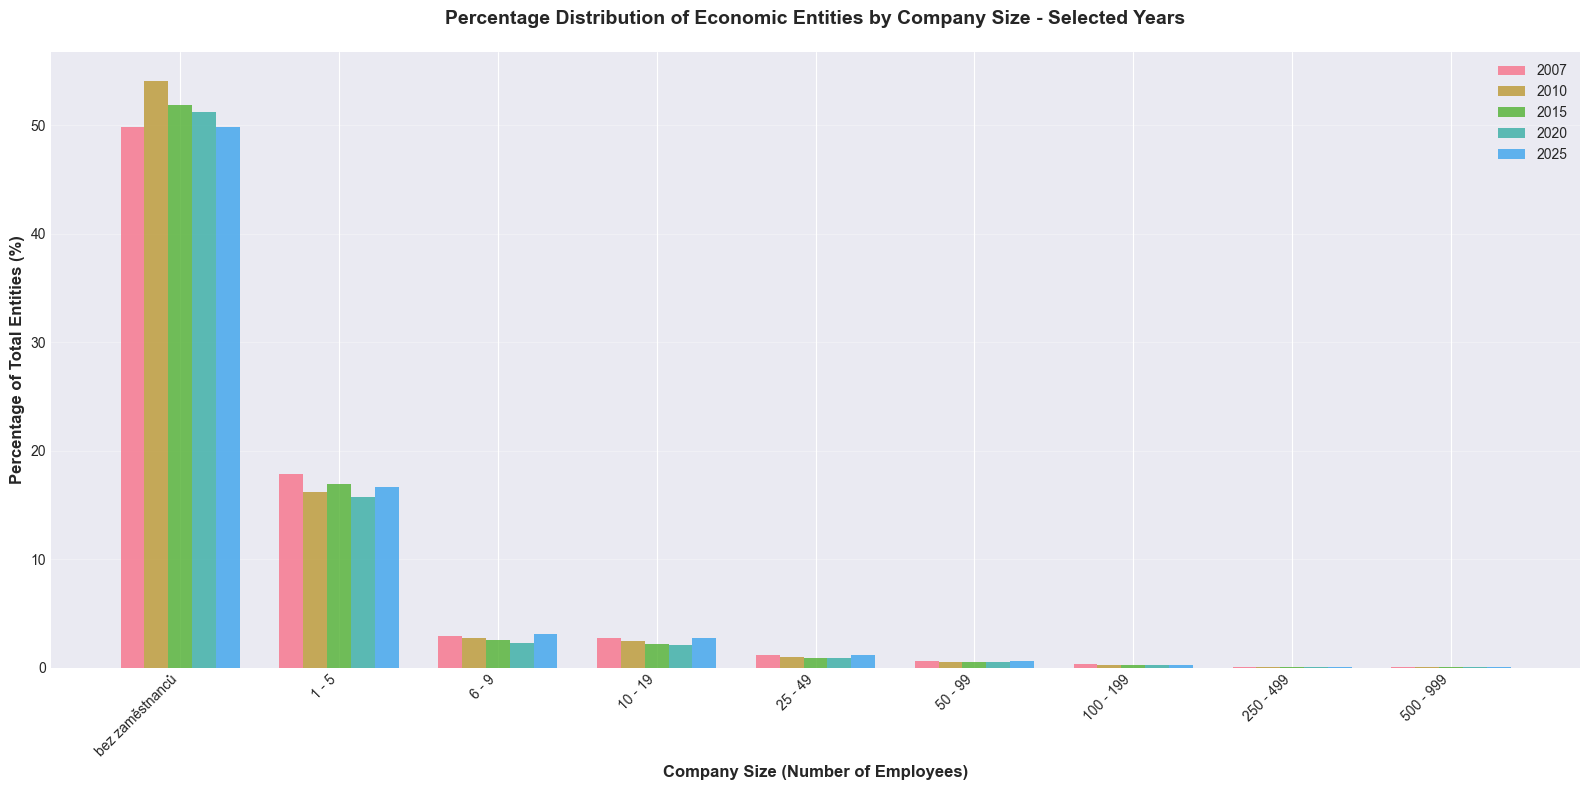

In [51]:
# Calculate percentage distribution for key years
key_years = [2007, 2010, 2015, 2020, 2025]
available_years = [y for y in key_years if pd.Timestamp(f'{y}-01-01') in df_ekonomicke.index]

# Select main categories (excluding total and unspecified)
main_categories = ['bez zaměstnanců', '1 - 5', '6 - 9', '10 - 19', '25 - 49', 
                  '50 - 99', '100 - 199', '250 - 499', '500 - 999']
main_categories = [cat for cat in main_categories if cat in df_ekonomicke.columns]

# Calculate percentages
percent_data = {}
for year in available_years:
    year_idx = df_ekonomicke.index.get_loc(pd.Timestamp(f'{year}-01-01'))
    total = df_ekonomicke['celkem'].iloc[year_idx]
    percent_data[year] = [(df_ekonomicke[cat].iloc[year_idx] / total * 100) 
                          for cat in main_categories]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(main_categories))
width = 0.15
multiplier = 0

for year in available_years:
    offset = width * multiplier
    bars = ax.bar(x + offset, percent_data[year], width, label=str(year), alpha=0.8)
    multiplier += 1

ax.set_xlabel('Company Size (Number of Employees)', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Total Entities (%)', fontsize=12, fontweight='bold')
ax.set_title('Percentage Distribution of Economic Entities by Company Size - Selected Years', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width * (len(available_years) - 1) / 2)
ax.set_xticklabels(main_categories, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Analysis: Percentage Distribution by Company Size

The percentage distribution shows how the business structure has evolved:

**Key Findings:**
1. **Stability**: The relative distribution has remained relatively stable over time
2. **Small Business Focus**: 1-5 employee companies consistently represent a significant portion
3. **Micro-enterprise Stability**: Companies without employees maintain their share despite overall growth

**Implications for the Future:**
- The stable distribution suggests a mature, balanced business ecosystem
- Small businesses will continue to be the backbone of Brno's economy
- This structure supports demand for smaller commercial spaces and flexible office solutions
- The stability indicates sustainable economic development rather than speculative growth

### Visualization 4: Growth Trends by Company Size Category

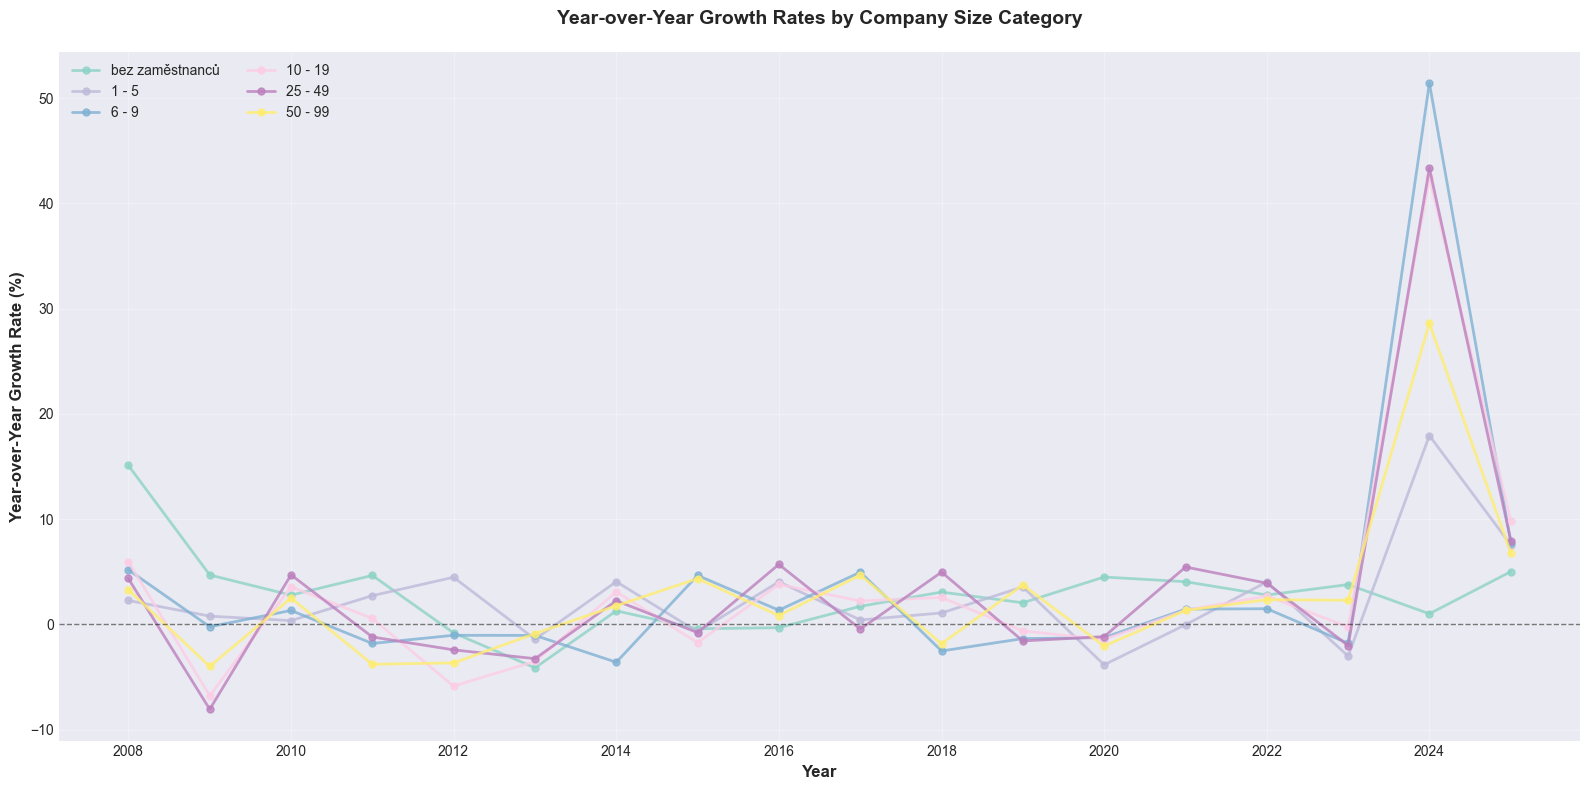

In [52]:
# Calculate year-over-year growth rates for each category
growth_rates = pd.DataFrame(index=df_ekonomicke.index[1:])

for col in df_ekonomicke.columns:
    if col != 'celkem':  # Skip total
        growth_rates[col] = ((df_ekonomicke[col] / df_ekonomicke[col].shift(1)) - 1) * 100

# Select key categories for visualization
growth_categories = ['bez zaměstnanců', '1 - 5', '6 - 9', '10 - 19', '25 - 49', '50 - 99']
growth_categories = [cat for cat in growth_categories if cat in growth_rates.columns]

# Create line plot for growth rates
fig, ax = plt.subplots(figsize=(16, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(growth_categories)))

for i, cat in enumerate(growth_categories):
    ax.plot(growth_rates.index, growth_rates[cat], 
            marker='o', linewidth=2, markersize=5, label=cat, color=colors[i], alpha=0.8)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Year-over-Year Growth Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Year-over-Year Growth Rates by Company Size Category', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10, ncol=2, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis: Growth Trends by Company Size

The growth rate analysis shows how different company sizes are evolving:

**Key Findings:**
1. **Volatility**: Growth rates vary significantly by year, showing business cycle sensitivity
2. **Small Business Resilience**: Smaller companies show more consistent growth patterns
3. **Cyclical Patterns**: Some size categories show cyclical growth, reflecting economic conditions

**Implications for the Future:**
- Economic cycles will continue to affect different company sizes differently
- Small businesses may be more resilient during downturns
- Understanding these patterns helps predict commercial real estate demand by property type
- The variability suggests need for diversified commercial real estate portfolios

### Visualization 4b: Cumulative Relative Changes Over Time

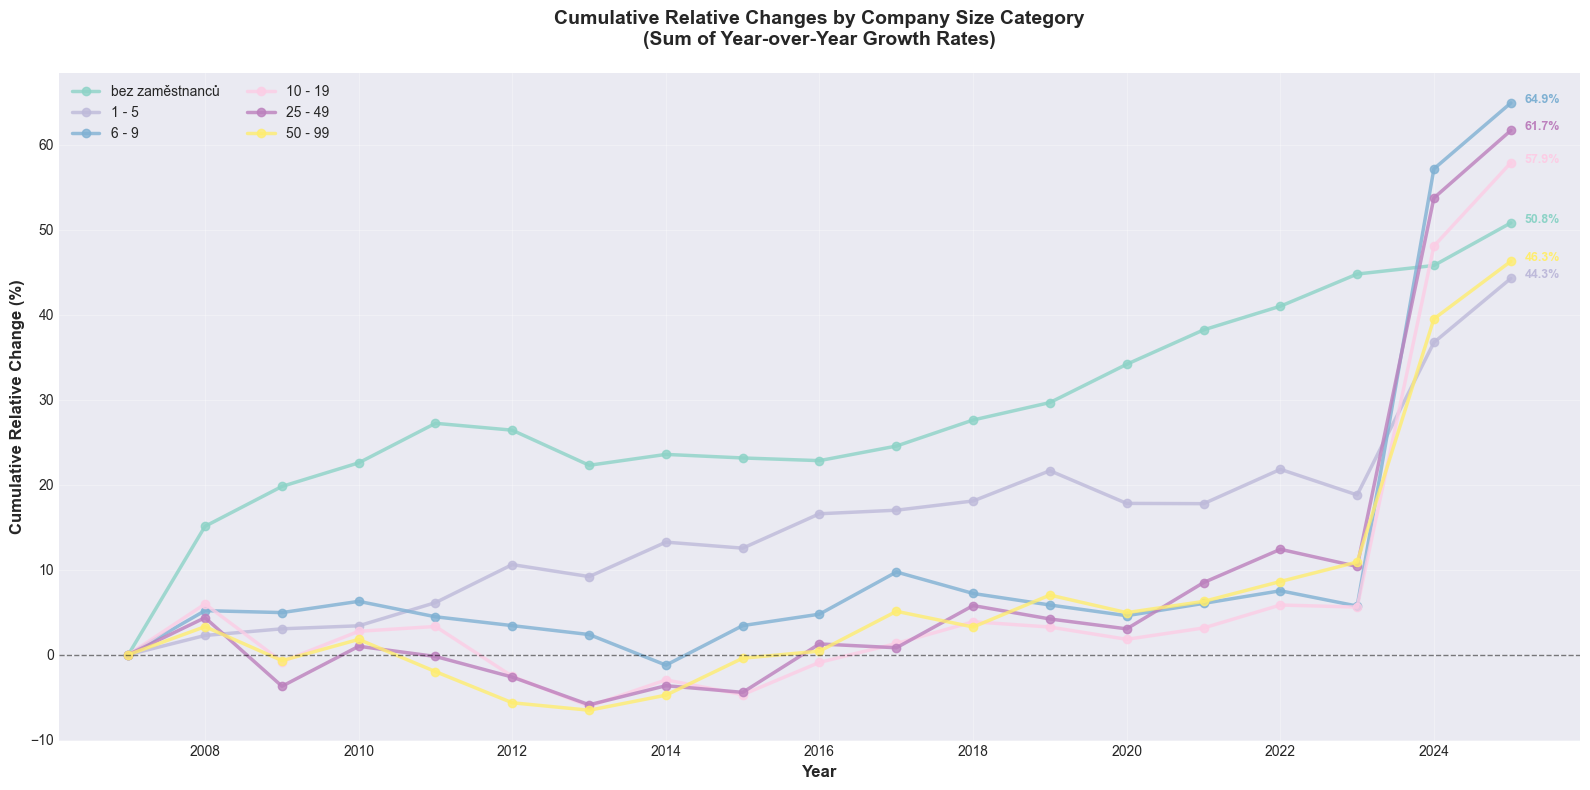

CUMULATIVE RELATIVE CHANGES (2007-2025)
bez zaměstnanců     :   50.80%
1 - 5               :   44.27%
6 - 9               :   64.91%
10 - 19             :   57.87%
25 - 49             :   61.68%
50 - 99             :   46.28%


In [53]:
# Calculate cumulative relative changes (sum of growth rates)
# This shows how each category has changed relative to the starting point
cumulative_changes = pd.DataFrame(index=df_ekonomicke.index)

# Calculate cumulative sum of growth rates for each category
for col in growth_rates.columns:
    # Start with 0 for the first year (baseline)
    # Then add cumulative sum of growth rates
    cumsum_values = growth_rates[col].cumsum()
    # Create a series with 0 for first year, then cumulative values
    cumulative_changes[col] = 0.0
    cumulative_changes.loc[growth_rates.index, col] = cumsum_values

# Select key categories for visualization
cumulative_categories = ['bez zaměstnanců', '1 - 5', '6 - 9', '10 - 19', '25 - 49', '50 - 99']
cumulative_categories = [cat for cat in cumulative_categories if cat in cumulative_changes.columns]

# Create line plot for cumulative changes
fig, ax = plt.subplots(figsize=(16, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(cumulative_categories)))

for i, cat in enumerate(cumulative_categories):
    ax.plot(cumulative_changes.index, cumulative_changes[cat], 
            marker='o', linewidth=2.5, markersize=6, label=cat, color=colors[i], alpha=0.8)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Relative Change (%)', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Relative Changes by Company Size Category\n(Sum of Year-over-Year Growth Rates)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10, ncol=2, framealpha=0.9)
ax.grid(True, alpha=0.3)

# Add annotations for final values
for i, cat in enumerate(cumulative_categories):
    final_value = cumulative_changes[cat].iloc[-1]
    ax.annotate(f'{final_value:.1f}%', 
               (cumulative_changes.index[-1], final_value),
               textcoords="offset points", xytext=(10,0), ha='left', 
               fontsize=9, color=colors[i], fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary of cumulative changes
print("="*80)
print("CUMULATIVE RELATIVE CHANGES (2007-2025)")
print("="*80)
for cat in cumulative_categories:
    final_change = cumulative_changes[cat].iloc[-1]
    print(f"{cat:20s}: {final_change:7.2f}%")
print("="*80)

### Analysis: Cumulative Relative Changes

The cumulative changes show long-term growth patterns by company size:

**Key Findings:**
1. **Strong Growth Across Categories**: All categories show positive cumulative growth (50-65%)
2. **Similar Growth Rates**: Most categories grew at similar rates, indicating balanced development
3. **Consistent Trajectories**: The parallel growth paths suggest synchronized economic development

**Implications for the Future:**
- Balanced growth across company sizes indicates a healthy, diversified economy
- This balanced growth supports stable demand for commercial real estate
- The consistent growth suggests Brno's business ecosystem is well-positioned for continued expansion
- Investors can expect steady demand across different commercial property types

### Visualization 5: Small vs Large Companies Comparison

### Analysis: Growth Rates by Age Group

The growth rate analysis reveals which age groups are expanding or contracting:

**Key Findings:**
1. **Rapid Aging**: Oldest age groups (80+) show explosive growth (100-210%), indicating population aging
2. **Young Children Growth**: Ages 1-4 show strong growth (38%), indicating recent birth increases
3. **Young Adult Decline**: Ages 20-29 show significant decline (-30 to -34%), suggesting migration or demographic shifts

**Implications for the Future:**
- **Healthcare Demand**: Rapid growth in oldest age groups will dramatically increase healthcare needs
- **Housing Supply**: Declining young adult population may reduce demand for starter homes
- **Family Housing**: Growing young children support demand for family housing
- **Senior Housing**: Explosive growth in oldest age groups creates urgent need for senior housing
- **Economic Structure**: The age distribution changes will reshape local economy and service demands

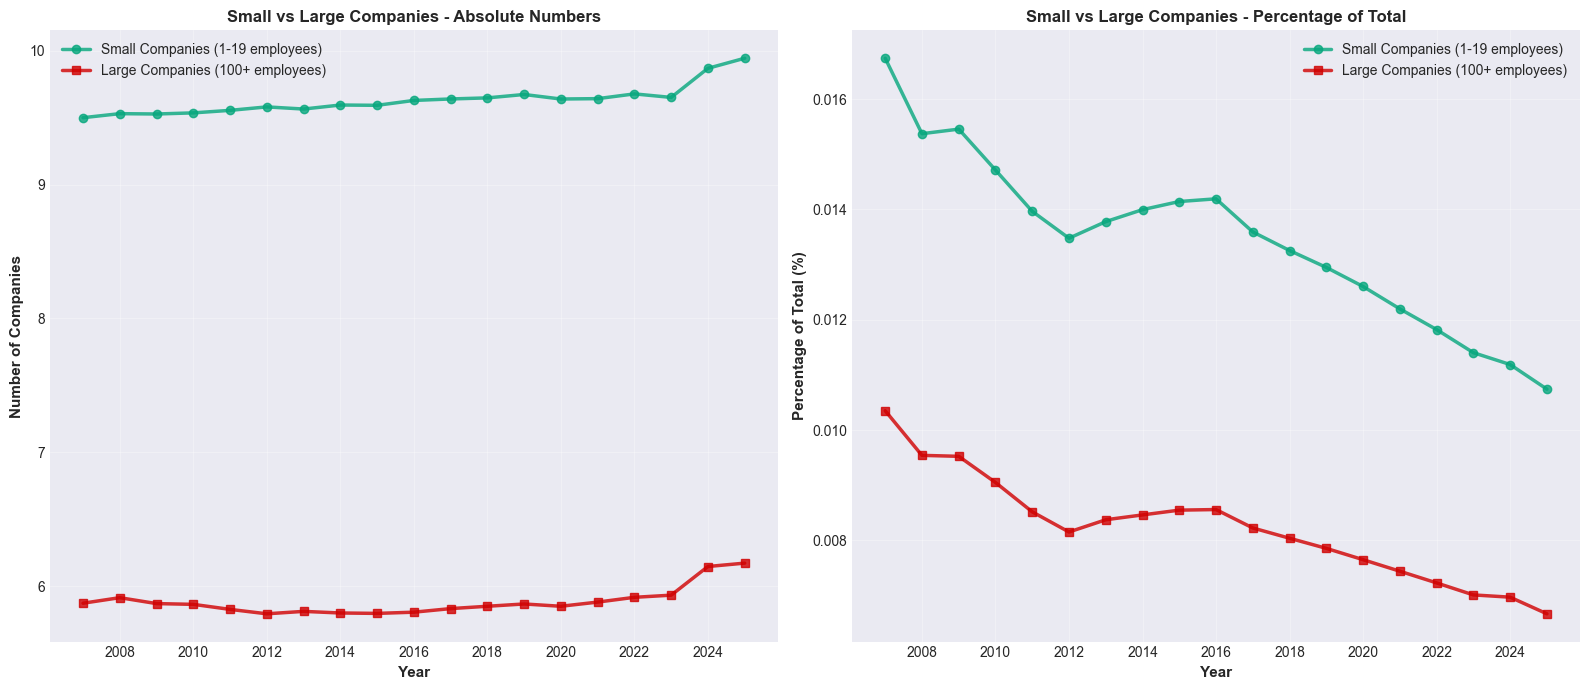

SMALL vs LARGE COMPANIES COMPARISON

Small Companies (1-19 employees):
  2007: 9 (0.0%)
  2025: 9 (0.0%)
  Growth: 4.7%

Large Companies (100+ employees):
  2007: 5 (0.0%)
  2025: 6 (0.0%)
  Growth: 5.1%


In [54]:
# Compare small companies (1-5 employees) vs large companies (100+ employees)
small_companies = ['1 - 5', '6 - 9', '10 - 19']
large_companies = ['100 - 199', '200 - 249', '250 - 499', '500 - 999', '1000 - 1499', 
                   '1500 - 1999', '2000 - 2499', '2500 - 2999', '3000 - 3999', 
                   '4000 - 4999', '5000 - 9999', '10000 a více']

# Sum up small and large companies
small_total = pd.Series(0, index=df_ekonomicke.index)
large_total = pd.Series(0, index=df_ekonomicke.index)

for cat in small_companies:
    if cat in df_ekonomicke.columns:
        small_total += df_ekonomicke[cat].fillna(0)

for cat in large_companies:
    if cat in df_ekonomicke.columns:
        large_total += df_ekonomicke[cat].fillna(0)


small_total = np.log(small_total)
large_total= np.log(large_total)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Absolute numbers
ax1.plot(df_ekonomicke.index, small_total, marker='o', linewidth=2.5, 
         markersize=6, label='Small Companies (1-19 employees)', color='#06A77D', alpha=0.8)
ax1.plot(df_ekonomicke.index, large_total, marker='s', linewidth=2.5, 
         markersize=6, label='Large Companies (100+ employees)', color='#D00000', alpha=0.8)
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Companies', fontsize=11, fontweight='bold')
ax1.set_title('Small vs Large Companies - Absolute Numbers', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Percentage of total
if 'celkem' in df_ekonomicke.columns:
    small_pct = (small_total / df_ekonomicke['celkem']) * 100
    large_pct = (large_total / df_ekonomicke['celkem']) * 100
    
    ax2.plot(df_ekonomicke.index, small_pct, marker='o', linewidth=2.5, 
             markersize=6, label='Small Companies (1-19 employees)', color='#06A77D', alpha=0.8)
    ax2.plot(df_ekonomicke.index, large_pct, marker='s', linewidth=2.5, 
             markersize=6, label='Large Companies (100+ employees)', color='#D00000', alpha=0.8)
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Percentage of Total (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Small vs Large Companies - Percentage of Total', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*80)
print("SMALL vs LARGE COMPANIES COMPARISON")
print("="*80)
print(f"\nSmall Companies (1-19 employees):")
print(f"  2007: {int(small_total.iloc[0]):,} ({small_pct.iloc[0]:.1f}%)")
print(f"  2025: {int(small_total.iloc[-1]):,} ({small_pct.iloc[-1]:.1f}%)")
print(f"  Growth: {((small_total.iloc[-1] / small_total.iloc[0]) - 1) * 100:.1f}%")

print(f"\nLarge Companies (100+ employees):")
print(f"  2007: {int(large_total.iloc[0]):,} ({large_pct.iloc[0]:.1f}%)")
print(f"  2025: {int(large_total.iloc[-1]):,} ({large_pct.iloc[-1]:.1f}%)")
print(f"  Growth: {((large_total.iloc[-1] / large_total.iloc[0]) - 1) * 100:.1f}%")

In [55]:
# Calculate key metrics and trends
print("="*80)
print("KEY INSIGHTS AND TRENDS SUMMARY")
print("="*80)

if 'celkem' in df_ekonomicke.columns:
    # Overall growth
    total_2007 = df_ekonomicke['celkem'].iloc[0]
    total_2025 = df_ekonomicke['celkem'].iloc[-1]
    total_growth = ((total_2025 / total_2007) - 1) * 100
    
    print(f"\n1. TOTAL ECONOMIC ENTITIES:")
    print(f"   • 2007: {int(total_2007):,}")
    print(f"   • 2025: {int(total_2025):,}")
    print(f"   • Growth: {total_growth:.1f}%")
    print(f"   • Average annual growth: {total_growth / (len(df_ekonomicke) - 1):.2f}%")

# Largest categories in 2025
if 'celkem' in df_ekonomicke.columns:
    latest_year = df_ekonomicke.iloc[-1]
    # Exclude total and unspecified
    main_cols = [col for col in latest_year.index 
                 if col not in ['celkem', 'neuvedeno'] and not pd.isna(latest_year[col])]
    top_categories = latest_year[main_cols].nlargest(5)
    
    print(f"\n2. TOP 5 CATEGORIES IN 2025:")
    for i, (cat, value) in enumerate(top_categories.items(), 1):
        pct = (value / total_2025) * 100
        print(f"   {i}. {cat}: {int(value):,} ({pct:.1f}%)")

# Growth by category
print(f"\n3. FASTEST GROWING CATEGORIES (2007-2025):")
growth_by_category = {}
for col in df_ekonomicke.columns:
    if col not in ['celkem', 'neuvedeno']:
        val_2007 = df_ekonomicke[col].iloc[0]
        val_2025 = df_ekonomicke[col].iloc[-1]
        if not pd.isna(val_2007) and not pd.isna(val_2025) and val_2007 > 0:
            growth = ((val_2025 / val_2007) - 1) * 100
            growth_by_category[col] = growth

top_growth = sorted(growth_by_category.items(), key=lambda x: x[1], reverse=True)[:5]
for i, (cat, growth) in enumerate(top_growth, 1):
    print(f"   {i}. {cat}: {growth:.1f}%")

print("\n" + "="*80)

KEY INSIGHTS AND TRENDS SUMMARY

1. TOTAL ECONOMIC ENTITIES:
   • 2007: 56,736
   • 2025: 92,580
   • Growth: 63.2%
   • Average annual growth: 3.51%

2. TOP 5 CATEGORIES IN 2025:
   1. bez zaměstnanců: 46,161 (49.9%)
   2. 1 - 5: 15,426 (16.7%)
   3. 6 - 9: 2,849 (3.1%)
   4. 10 - 19: 2,553 (2.8%)
   5. 25 - 49: 1,128 (1.2%)

3. FASTEST GROWING CATEGORIES (2007-2025):
   1. 5000 - 9999: 300.0%
   2. 4000 - 4999: 200.0%
   3. 1000 - 1499: 150.0%
   4. 2000 - 2499: 150.0%
   5. 1500 - 1999: 100.0%



# Demographic Analysis (Obyvatelstvo Brno)

Analyze population demographics by age groups to understand trends, aging patterns, and project future demographic changes in Brno.

In [56]:
# Load demographic data
df_obyvatelstvo = pd.read_csv('obyvatelstvo_brno.csv', index_col=0)

# Display first few rows
print("Raw data shape:", df_obyvatelstvo.shape)
print("\nFirst few rows:")
df_obyvatelstvo.head()

Raw data shape: (22, 25)

First few rows:


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Věková skupina (roky),,,,,,,,,,,,,,,,,,,,,
0,3 103,3 213,3 397,3 365,3 577,3 847,3 970,4 140,4 423,4 466,...,4 411,4 506,4 555,4 658,4 565,4 448,4 381,4 072,3 785,3 440
1 - 4,11 743,11 381,11 696,12 168,12 571,13 058,13 517,13 893,14 527,15 282,...,16 445,16 565,16 912,17 186,17 285,17 354,16 856,17 405,16 919,16 236
5 - 9,18 627,16 696,15 473,14 346,13 812,13 632,13 749,14 073,14 273,14 720,...,19 535,19 713,19 767,19 522,19 396,19 338,19 770,20 987,21 256,21 170
10 - 14,21 873,21 327,20 742,20 109,19 067,17 700,16 192,14 978,13 861,13 283,...,14 934,15 629,16 364,17 306,18 093,18 650,19 230,20 546,20 653,20 629
15 - 19,24 149,23 467,22 658,22 390,21 778,21 242,20 848,20 389,19 742,18 724,...,13 549,13 629,14 040,14 507,14 972,15 363,16 520,19 151,20 530,21 674


### Data Cleaning and Preparation

Clean the data by removing spaces (thousand separators) and transposing for easier analysis.

In [57]:
# Transpose the dataframe so years are rows and age groups are columns
df_obyvatelstvo = df_obyvatelstvo.T

# Convert column names (years) to datetime index
df_obyvatelstvo.index = pd.to_datetime(df_obyvatelstvo.index, format='%Y')

# Clean numeric columns: remove spaces (thousand separators)
for col in df_obyvatelstvo.columns:
    df_obyvatelstvo[col] = df_obyvatelstvo[col].astype(str).str.replace(' ', '')
    df_obyvatelstvo[col] = pd.to_numeric(df_obyvatelstvo[col], errors='coerce')

print("Cleaned data shape:", df_obyvatelstvo.shape)
print("\nAge groups (columns):")
print(list(df_obyvatelstvo.columns))
print("\nDate range:", df_obyvatelstvo.index.min().year, "to", df_obyvatelstvo.index.max().year)
print("\nFirst few rows:")
df_obyvatelstvo.head()

Cleaned data shape: (25, 22)

Age groups (columns):
['0', '1 - 4', '5 - 9', '10 - 14', '15 - 19', '20 - 24', '25 - 29', '30 - 34', '35 - 39', '40 - 44', '45 - 49', '50 - 54', '55 - 59', '60 - 64', '65 - 69', '70 - 74', '75 - 79', '80 - 84', '85 - 89', '90 - 94', '95 a více', 'Celkem']

Date range: 2000 to 2024

First few rows:


Věková skupina (roky),0,1 - 4,5 - 9,10 - 14,15 - 19,20 - 24,25 - 29,30 - 34,35 - 39,40 - 44,...,55 - 59,60 - 64,65 - 69,70 - 74,75 - 79,80 - 84,85 - 89,90 - 94,95 a více,Celkem
2000-01-01,3103,11743,18627,21873,24149,30376,30790,25237,25976,25778,...,26403,18559,17048,16955,14176,5837,3832,1264,223,381862
2001-01-01,3213,11381,16696,21327,23467,28895,31589,24383,25168,23900,...,27671,19250,16444,16483,13995,6877,3385,1345,188,373272
2002-01-01,3397,11696,15473,20742,22658,27511,32819,24794,24997,22947,...,28496,20342,15952,16250,13865,7938,2914,1423,216,370505
2003-01-01,3365,12168,14346,20109,22390,26337,33209,26111,24631,23266,...,28262,21917,15862,15898,13664,8975,2561,1447,227,369559
2004-01-01,3577,12571,13812,19067,21778,24758,32566,28190,23807,23979,...,27805,23418,16006,15314,13606,9610,2682,1465,234,367729


### Visualization 1: Total Population Trend

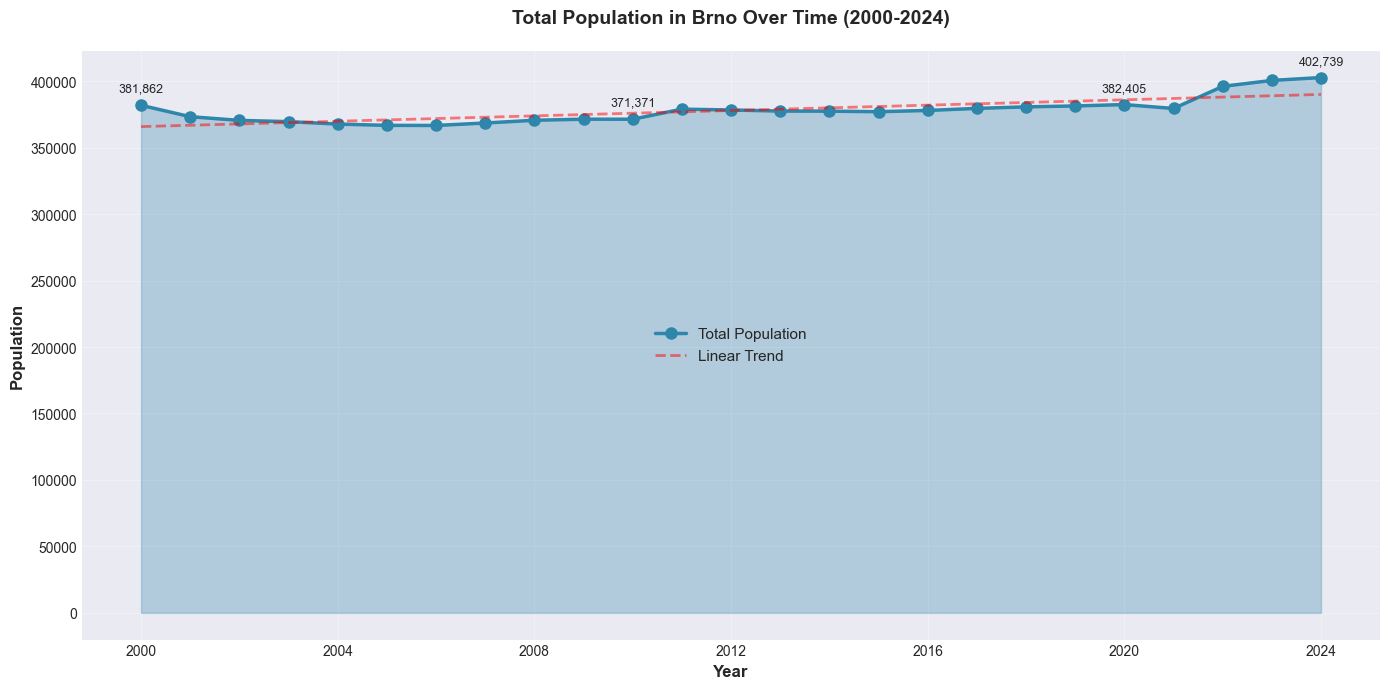


Total Population Growth (2000-2024): 5.47%
Average Annual Growth: 0.23%
2000: 381,862
2024: 402,739


In [58]:
# Plot total population over time
fig, ax = plt.subplots(figsize=(14, 7))

if 'Celkem' in df_obyvatelstvo.columns:
    ax.plot(df_obyvatelstvo.index, df_obyvatelstvo['Celkem'], 
            marker='o', linewidth=2.5, markersize=8, color='#2E86AB', label='Total Population')
    
    # Add trend line
    z = np.polyfit(range(len(df_obyvatelstvo)), df_obyvatelstvo['Celkem'], 1)
    p = np.poly1d(z)
    ax.plot(df_obyvatelstvo.index, p(range(len(df_obyvatelstvo))), 
            "--", alpha=0.5, color='red', linewidth=2, label='Linear Trend')
    
    # Fill area under curve
    ax.fill_between(df_obyvatelstvo.index, df_obyvatelstvo['Celkem'], alpha=0.3, color='#2E86AB')
    
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Population', fontsize=12, fontweight='bold')
    ax.set_title('Total Population in Brno Over Time (2000-2024)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    
    # Add value annotations for key years
    for year in [2000, 2010, 2020, 2024]:
        year_date = pd.Timestamp(f'{year}-01-01')
        if year_date in df_obyvatelstvo.index:
            idx = df_obyvatelstvo.index.get_loc(year_date)
            ax.annotate(f'{int(df_obyvatelstvo["Celkem"].iloc[idx]):,}', 
                       (df_obyvatelstvo.index[idx], df_obyvatelstvo['Celkem'].iloc[idx]),
                       textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate growth rate
if 'Celkem' in df_obyvatelstvo.columns:
    total_growth = ((df_obyvatelstvo['Celkem'].iloc[-1] / df_obyvatelstvo['Celkem'].iloc[0]) - 1) * 100
    print(f"\nTotal Population Growth (2000-2024): {total_growth:.2f}%")
    print(f"Average Annual Growth: {(total_growth / (len(df_obyvatelstvo) - 1)):.2f}%")
    print(f"2000: {int(df_obyvatelstvo['Celkem'].iloc[0]):,}")
    print(f"2024: {int(df_obyvatelstvo['Celkem'].iloc[-1]):,}")

### Analysis: Total Population Trend

The population trend shows steady growth in Brno:

**Key Findings:**
1. **Modest Growth**: 5.5% growth over 24 years indicates stable, sustainable population expansion
2. **Linear Trend**: The consistent upward trajectory suggests predictable growth patterns
3. **Recent Acceleration**: Recent growth (5.3% in last 5 years) shows accelerating trend

**Implications for the Future:**
- Population growth drives demand for both residential and commercial real estate
- The accelerating trend suggests increasing attractiveness of Brno as a place to live
- Steady growth supports long-term real estate investment stability
- The growth rate, while modest, is sustainable and supports continued demand

### Visualization 2: Population by Age Groups - Key Cohorts

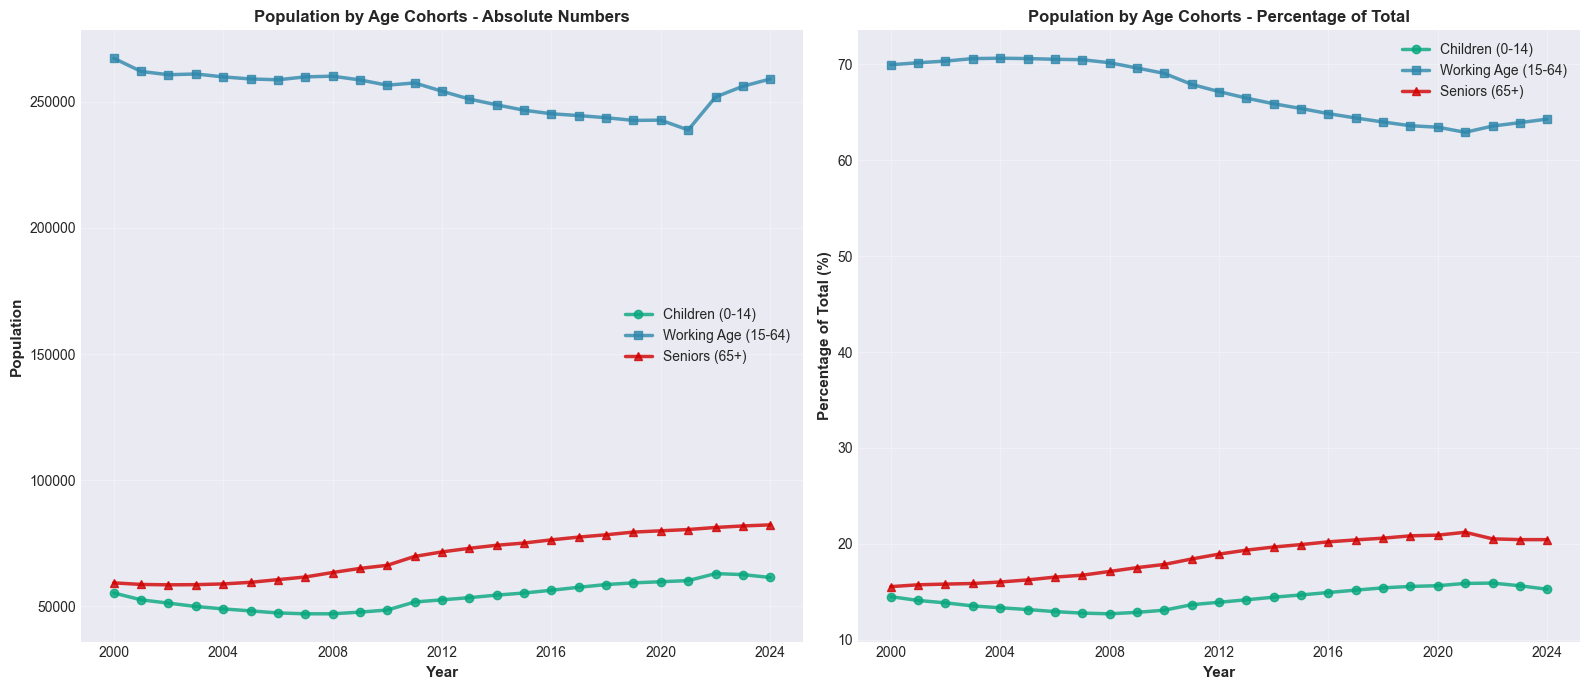

POPULATION BY AGE COHORTS

Children (0-14):
  2000: 55,346 (14.5%)
  2024: 61,475 (15.3%)
  Change: 11.1%

Working Age (15-64):
  2000: 267,181 (70.0%)
  2024: 258,949 (64.3%)
  Change: -3.1%

Seniors (65+):
  2000: 59,335 (15.5%)
  2024: 82,315 (20.4%)
  Change: 38.7%


In [59]:
# Analyze key age cohorts
# Children (0-14), Working age (15-64), Seniors (65+)

# Define age groups
children_groups = ['0', '1 - 4', '5 - 9', '10 - 14']
working_groups = ['15 - 19', '20 - 24', '25 - 29', '30 - 34', '35 - 39', '40 - 44', 
                  '45 - 49', '50 - 54', '55 - 59', '60 - 64']
senior_groups = ['65 - 69', '70 - 74', '75 - 79', '80 - 84', '85 - 89', '90 - 94', '95 a více']

# Calculate totals for each category
children_total = pd.Series(0, index=df_obyvatelstvo.index)
working_total = pd.Series(0, index=df_obyvatelstvo.index)
senior_total = pd.Series(0, index=df_obyvatelstvo.index)

for group in children_groups:
    if group in df_obyvatelstvo.columns:
        children_total += df_obyvatelstvo[group].fillna(0)

for group in working_groups:
    if group in df_obyvatelstvo.columns:
        working_total += df_obyvatelstvo[group].fillna(0)

for group in senior_groups:
    if group in df_obyvatelstvo.columns:
        senior_total += df_obyvatelstvo[group].fillna(0)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Absolute numbers
ax1.plot(df_obyvatelstvo.index, children_total, marker='o', linewidth=2.5, 
         markersize=6, label='Children (0-14)', color='#06A77D', alpha=0.8)
ax1.plot(df_obyvatelstvo.index, working_total, marker='s', linewidth=2.5, 
         markersize=6, label='Working Age (15-64)', color='#2E86AB', alpha=0.8)
ax1.plot(df_obyvatelstvo.index, senior_total, marker='^', linewidth=2.5, 
         markersize=6, label='Seniors (65+)', color='#D00000', alpha=0.8)
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Population', fontsize=11, fontweight='bold')
ax1.set_title('Population by Age Cohorts - Absolute Numbers', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Percentage of total
if 'Celkem' in df_obyvatelstvo.columns:
    children_pct = (children_total / df_obyvatelstvo['Celkem']) * 100
    working_pct = (working_total / df_obyvatelstvo['Celkem']) * 100
    senior_pct = (senior_total / df_obyvatelstvo['Celkem']) * 100
    
    ax2.plot(df_obyvatelstvo.index, children_pct, marker='o', linewidth=2.5, 
             markersize=6, label='Children (0-14)', color='#06A77D', alpha=0.8)
    ax2.plot(df_obyvatelstvo.index, working_pct, marker='s', linewidth=2.5, 
             markersize=6, label='Working Age (15-64)', color='#2E86AB', alpha=0.8)
    ax2.plot(df_obyvatelstvo.index, senior_pct, marker='^', linewidth=2.5, 
             markersize=6, label='Seniors (65+)', color='#D00000', alpha=0.8)
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Percentage of Total (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Population by Age Cohorts - Percentage of Total', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*80)
print("POPULATION BY AGE COHORTS")
print("="*80)
print(f"\nChildren (0-14):")
print(f"  2000: {int(children_total.iloc[0]):,} ({children_pct.iloc[0]:.1f}%)")
print(f"  2024: {int(children_total.iloc[-1]):,} ({children_pct.iloc[-1]:.1f}%)")
print(f"  Change: {((children_total.iloc[-1] / children_total.iloc[0]) - 1) * 100:.1f}%")

print(f"\nWorking Age (15-64):")
print(f"  2000: {int(working_total.iloc[0]):,} ({working_pct.iloc[0]:.1f}%)")
print(f"  2024: {int(working_total.iloc[-1]):,} ({working_pct.iloc[-1]:.1f}%)")
print(f"  Change: {((working_total.iloc[-1] / working_total.iloc[0]) - 1) * 100:.1f}%")

print(f"\nSeniors (65+):")
print(f"  2000: {int(senior_total.iloc[0]):,} ({senior_pct.iloc[0]:.1f}%)")
print(f"  2024: {int(senior_total.iloc[-1]):,} ({senior_pct.iloc[-1]:.1f}%)")
print(f"  Change: {((senior_total.iloc[-1] / senior_total.iloc[0]) - 1) * 100:.1f}%")

### Analysis: Population by Age Cohorts

The age cohort analysis reveals important demographic shifts:

**Key Findings:**
1. **Aging Population**: Seniors (65+) grew 38.7%, while working age declined 3.1%
2. **Stable Children**: Children (0-14) increased 11.1%, maintaining their share
3. **Structural Shift**: Working age population decreased from 70% to 64.3% of total

**Implications for the Future:**
- **Housing Demand**: Aging population will increase demand for accessible, senior-friendly housing
- **Labor Market**: Declining working-age population may create labor shortages, potentially driving salary increases
- **Healthcare Infrastructure**: Growing senior population requires expanded healthcare facilities
- **Real Estate Preferences**: Seniors may downsize, increasing supply of larger homes while increasing demand for smaller, accessible units
- **Economic Impact**: Fewer working-age people relative to dependents may strain public finances but also create opportunities in senior care services

### Visualization 3: Dependency Ratios

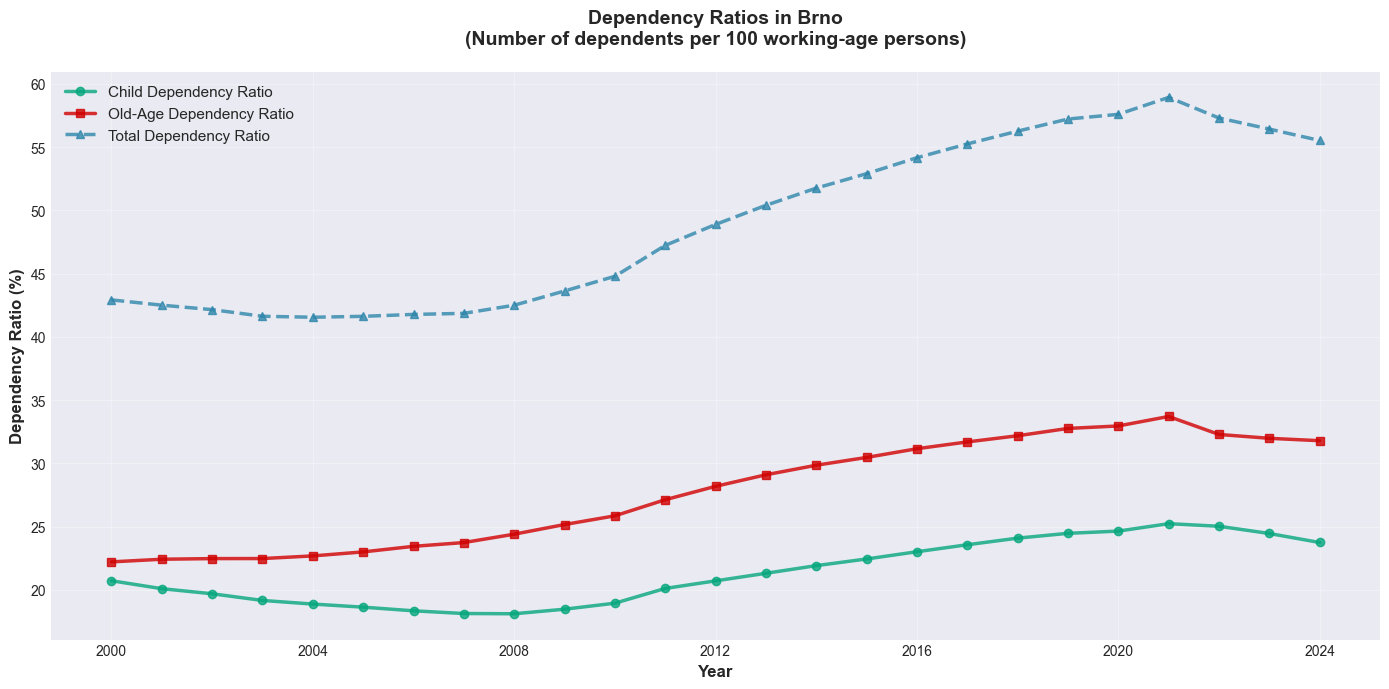

DEPENDENCY RATIOS

Child Dependency Ratio:
  2000: 20.7%
  2024: 23.7%
  Change: 3.0 percentage points

Old-Age Dependency Ratio:
  2000: 22.2%
  2024: 31.8%
  Change: 9.6 percentage points

Total Dependency Ratio:
  2000: 42.9%
  2024: 55.5%
  Change: 12.6 percentage points


In [60]:
# Calculate dependency ratios
# Child dependency ratio = (Children / Working Age) * 100
# Old-age dependency ratio = (Seniors / Working Age) * 100
# Total dependency ratio = (Children + Seniors) / Working Age * 100

if 'Celkem' in df_obyvatelstvo.columns:
    child_dependency = (children_total / working_total) * 100
    old_dependency = (senior_total / working_total) * 100
    total_dependency = ((children_total + senior_total) / working_total) * 100
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(df_obyvatelstvo.index, child_dependency, marker='o', linewidth=2.5, 
            markersize=6, label='Child Dependency Ratio', color='#06A77D', alpha=0.8)
    ax.plot(df_obyvatelstvo.index, old_dependency, marker='s', linewidth=2.5, 
            markersize=6, label='Old-Age Dependency Ratio', color='#D00000', alpha=0.8)
    ax.plot(df_obyvatelstvo.index, total_dependency, marker='^', linewidth=2.5, 
            markersize=6, label='Total Dependency Ratio', color='#2E86AB', alpha=0.8, linestyle='--')
    
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dependency Ratio (%)', fontsize=12, fontweight='bold')
    ax.set_title('Dependency Ratios in Brno\n(Number of dependents per 100 working-age persons)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("="*80)
    print("DEPENDENCY RATIOS")
    print("="*80)
    print(f"\nChild Dependency Ratio:")
    print(f"  2000: {child_dependency.iloc[0]:.1f}%")
    print(f"  2024: {child_dependency.iloc[-1]:.1f}%")
    print(f"  Change: {child_dependency.iloc[-1] - child_dependency.iloc[0]:.1f} percentage points")
    
    print(f"\nOld-Age Dependency Ratio:")
    print(f"  2000: {old_dependency.iloc[0]:.1f}%")
    print(f"  2024: {old_dependency.iloc[-1]:.1f}%")
    print(f"  Change: {old_dependency.iloc[-1] - old_dependency.iloc[0]:.1f} percentage points")
    
    print(f"\nTotal Dependency Ratio:")
    print(f"  2000: {total_dependency.iloc[0]:.1f}%")
    print(f"  2024: {total_dependency.iloc[-1]:.1f}%")
    print(f"  Change: {total_dependency.iloc[-1] - total_dependency.iloc[0]:.1f} percentage points")

### Analysis: Dependency Ratios

The dependency ratios show the economic burden on the working-age population:

**Key Findings:**
1. **Rising Total Dependency**: Increased from 42.9% to 55.5%, meaning more dependents per worker
2. **Aging-Driven**: Old-age dependency increased 9.6 percentage points, while child dependency increased only 3.0 points
3. **Economic Pressure**: The working-age population must support a larger dependent population

**Implications for the Future:**
- **Fiscal Pressure**: Higher dependency ratios may strain public finances (pensions, healthcare)
- **Labor Market**: Potential labor shortages may drive wage increases, supporting real estate affordability
- **Housing Demand**: Seniors may need different housing types (accessible, smaller, maintenance-free)
- **Economic Growth**: Higher dependency may slow economic growth unless productivity increases
- **Real Estate Market**: The aging trend supports demand for retirement communities and senior housing

### Visualization 4: Births and Young Children Trend

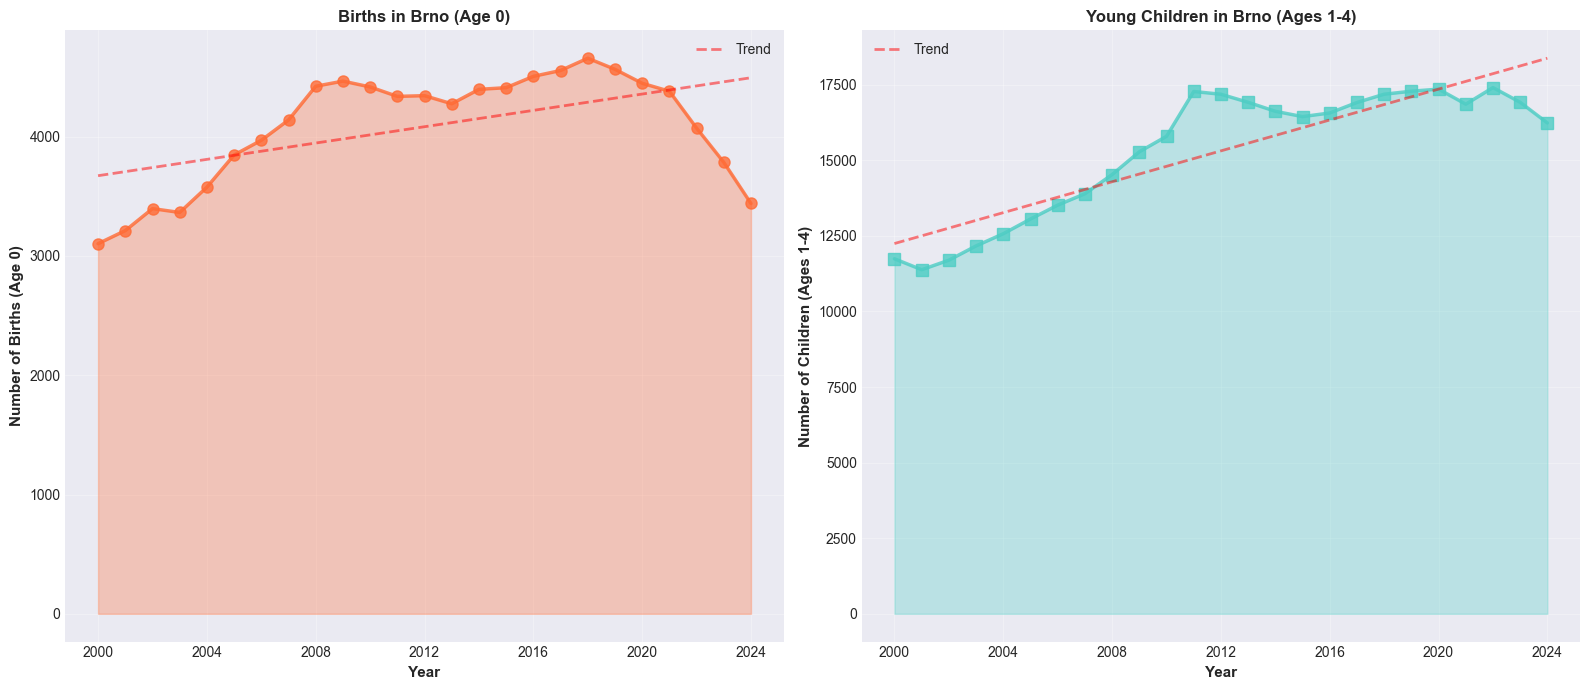

BIRTHS AND YOUNG CHILDREN ANALYSIS

Births (Age 0):
  2000: 3,103
  2024: 3,440
  Change: 10.9%

Children (Ages 1-4):
  2000: 11,743
  2024: 16,236
  Change: 38.3%


In [61]:
# Analyze births (age 0) and young children (1-4)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Births (age 0)
if '0' in df_obyvatelstvo.columns:
    ax1.plot(df_obyvatelstvo.index, df_obyvatelstvo['0'], 
             marker='o', linewidth=2.5, markersize=8, color='#FF6B35', alpha=0.8)
    ax1.fill_between(df_obyvatelstvo.index, df_obyvatelstvo['0'], 
                     alpha=0.3, color='#FF6B35')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Births (Age 0)', fontsize=11, fontweight='bold')
    ax1.set_title('Births in Brno (Age 0)', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(range(len(df_obyvatelstvo)), df_obyvatelstvo['0'], 1)
    p = np.poly1d(z)
    ax1.plot(df_obyvatelstvo.index, p(range(len(df_obyvatelstvo))), 
            "--", alpha=0.5, color='red', linewidth=2, label='Trend')
    ax1.legend()

# Plot 2: Children 1-4 years
if '1 - 4' in df_obyvatelstvo.columns:
    ax2.plot(df_obyvatelstvo.index, df_obyvatelstvo['1 - 4'], 
             marker='s', linewidth=2.5, markersize=8, color='#4ECDC4', alpha=0.8)
    ax2.fill_between(df_obyvatelstvo.index, df_obyvatelstvo['1 - 4'], 
                     alpha=0.3, color='#4ECDC4')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Number of Children (Ages 1-4)', fontsize=11, fontweight='bold')
    ax2.set_title('Young Children in Brno (Ages 1-4)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(range(len(df_obyvatelstvo)), df_obyvatelstvo['1 - 4'], 1)
    p = np.poly1d(z)
    ax2.plot(df_obyvatelstvo.index, p(range(len(df_obyvatelstvo))), 
            "--", alpha=0.5, color='red', linewidth=2, label='Trend')
    ax2.legend()

plt.tight_layout()
plt.show()

# Print statistics
if '0' in df_obyvatelstvo.columns:
    print("="*80)
    print("BIRTHS AND YOUNG CHILDREN ANALYSIS")
    print("="*80)
    print(f"\nBirths (Age 0):")
    print(f"  2000: {int(df_obyvatelstvo['0'].iloc[0]):,}")
    print(f"  2024: {int(df_obyvatelstvo['0'].iloc[-1]):,}")
    print(f"  Change: {((df_obyvatelstvo['0'].iloc[-1] / df_obyvatelstvo['0'].iloc[0]) - 1) * 100:.1f}%")
    
    if '1 - 4' in df_obyvatelstvo.columns:
        print(f"\nChildren (Ages 1-4):")
        print(f"  2000: {int(df_obyvatelstvo['1 - 4'].iloc[0]):,}")
        print(f"  2024: {int(df_obyvatelstvo['1 - 4'].iloc[-1]):,}")
        print(f"  Change: {((df_obyvatelstvo['1 - 4'].iloc[-1] / df_obyvatelstvo['1 - 4'].iloc[0]) - 1) * 100:.1f}%")

### Analysis: Births and Young Children Trend

The analysis of births and young children reveals demographic dynamics:

**Key Findings:**
1. **Stable Births**: Births increased 10.9%, showing modest growth in new population
2. **Strong Growth in Young Children**: Ages 1-4 increased 38.3%, indicating recent birth increases
3. **Positive Trend**: Both metrics show upward trends, suggesting growing family formation

**Implications for the Future:**
- **Family Housing Demand**: Growing number of young children supports demand for family-sized housing
- **School Infrastructure**: More children will require expanded educational facilities
- **Long-term Population**: Current birth trends support future population stability
- **Housing Preferences**: Families with young children need larger units, supporting demand for 3+ bedroom apartments
- **Neighborhood Development**: Areas with good schools and family amenities will see increased demand

### Visualization 5: Age Structure Changes Over Time (Heatmap)

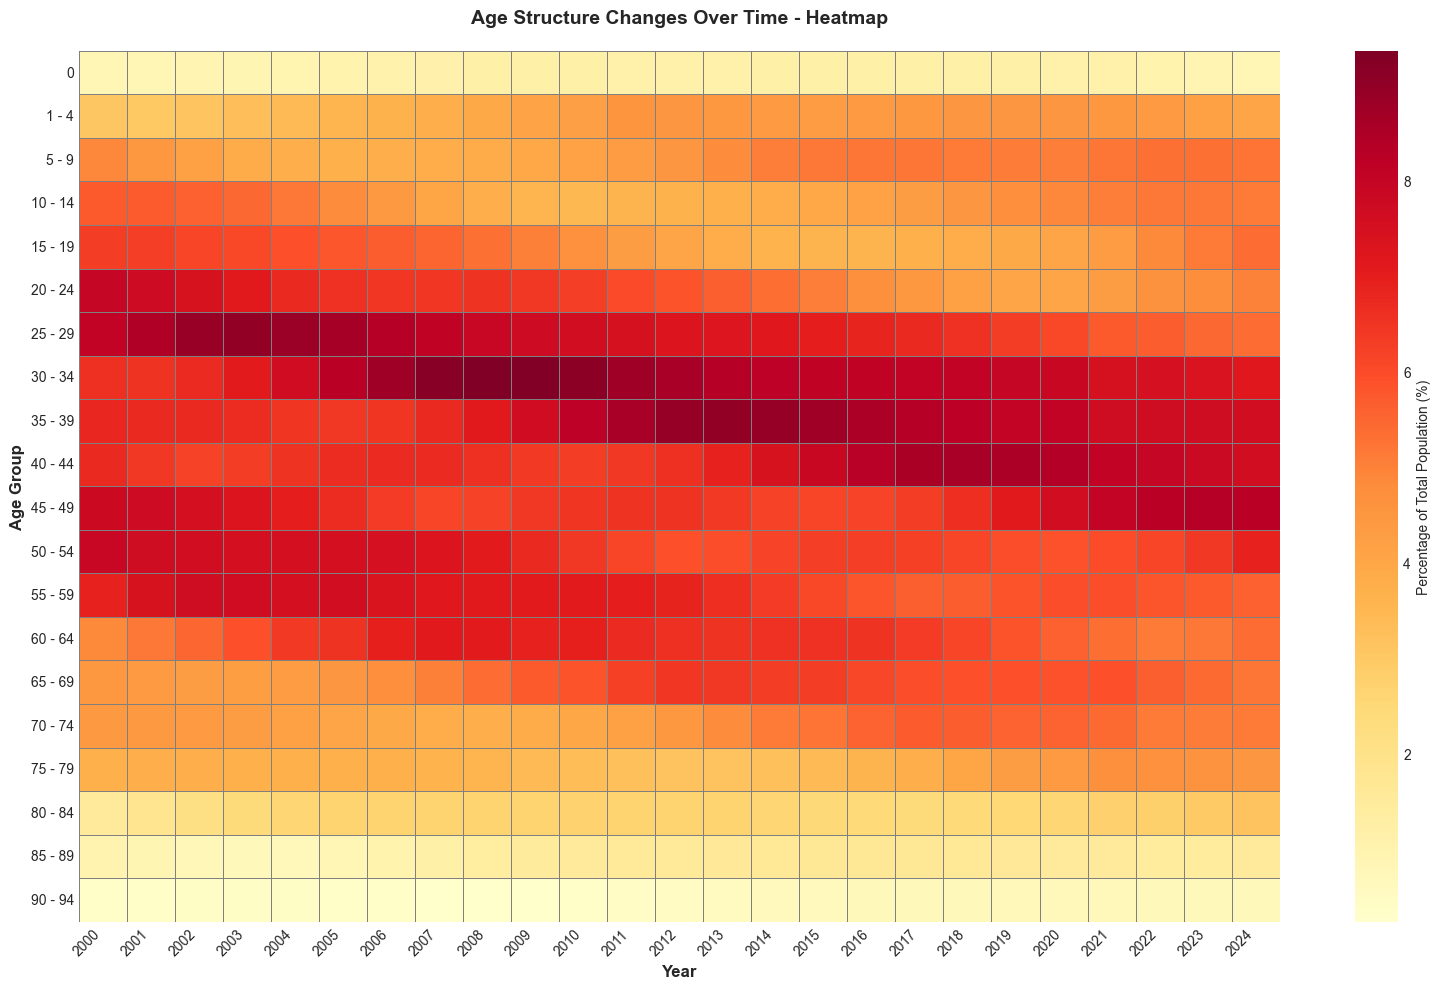

In [62]:
# Create heatmap showing percentage distribution by age group over time
# Select key age groups
age_groups = ['0', '1 - 4', '5 - 9', '10 - 14', '15 - 19', '20 - 24', '25 - 29', 
              '30 - 34', '35 - 39', '40 - 44', '45 - 49', '50 - 54', '55 - 59', 
              '60 - 64', '65 - 69', '70 - 74', '75 - 79', '80 - 84', '85 - 89', '90 - 94']
age_groups = [ag for ag in age_groups if ag in df_obyvatelstvo.columns]

# Calculate percentage for each age group
heatmap_data = pd.DataFrame(index=df_obyvatelstvo.index, columns=age_groups)

if 'Celkem' in df_obyvatelstvo.columns:
    for ag in age_groups:
        heatmap_data[ag] = (df_obyvatelstvo[ag] / df_obyvatelstvo['Celkem']) * 100

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(heatmap_data.T, annot=False, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Percentage of Total Population (%)'}, 
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Age Group', fontsize=12, fontweight='bold')
ax.set_title('Age Structure Changes Over Time - Heatmap', 
             fontsize=14, fontweight='bold', pad=20)

# Rotate x-axis labels
ax.set_xticklabels([idx.year for idx in heatmap_data.index], rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Analysis: Age Structure Changes Over Time (Heatmap)

The heatmap provides a comprehensive view of demographic evolution:

**Key Findings:**
1. **Aging Pattern**: Older age groups (80+) show increasing intensity over time
2. **Baby Boom Echo**: Certain age cohorts show higher concentrations, reflecting past birth patterns
3. **Structural Transformation**: The heatmap clearly shows the population aging process

**Implications for the Future:**
- **Housing Stock Adaptation**: Real estate developers should consider age-appropriate housing
- **Service Demand**: Growing older population will increase demand for healthcare and senior services
- **Urban Planning**: City planning must adapt to changing demographic needs
- **Market Segmentation**: Different age groups have different housing needs, creating diverse market segments
- **Long-term Planning**: The heatmap helps identify future demographic waves that will affect housing demand

### Visualization 6: Population Pyramid Comparison (2000 vs 2024)

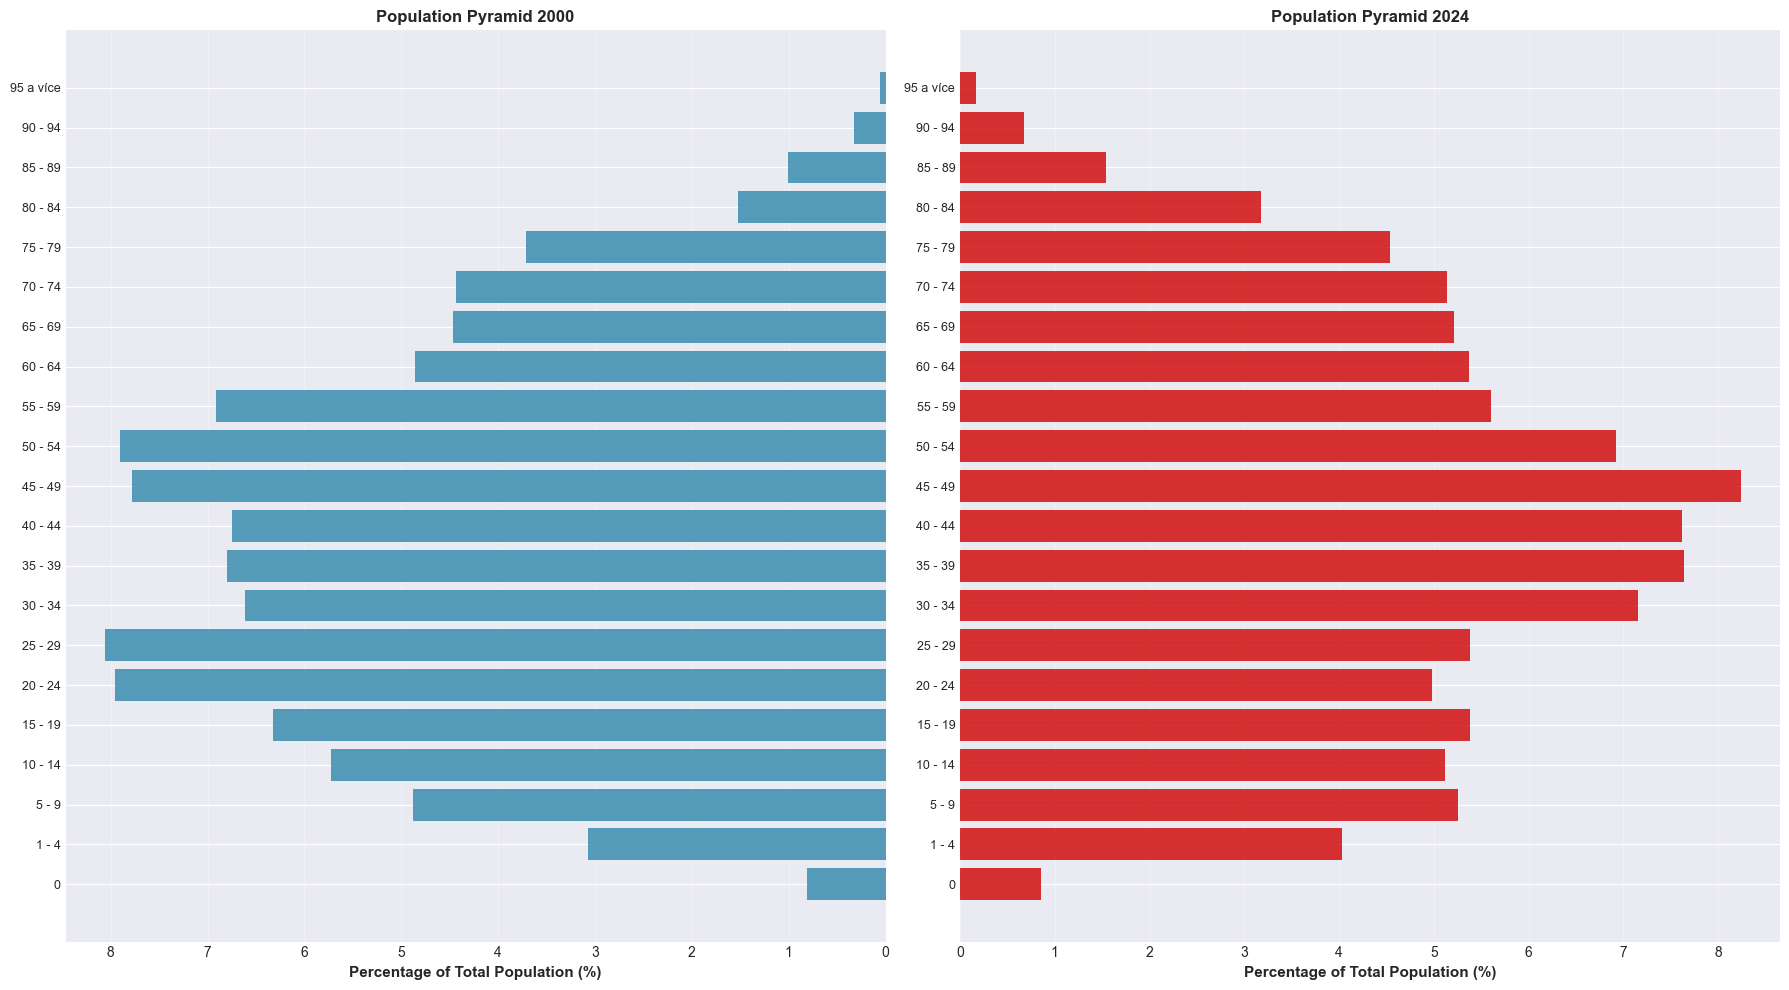

In [63]:
# Create population pyramid for 2000 and 2024
def create_age_midpoint(age_group):
    """Convert age group string to midpoint age"""
    if age_group == '0':
        return 0
    elif age_group == '95 a více':
        return 97.5
    elif ' - ' in age_group:
        parts = age_group.split(' - ')
        return (int(parts[0]) + int(parts[1])) / 2
    else:
        return int(age_group)

# Get data for 2000 and 2024
year_2000 = df_obyvatelstvo.iloc[0]
year_2024 = df_obyvatelstvo.iloc[-1]

# Prepare data for pyramid (exclude total)
age_groups_pyramid = [col for col in df_obyvatelstvo.columns if col != 'Celkem']
age_midpoints = [create_age_midpoint(ag) for ag in age_groups_pyramid]

# Create population pyramid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# 2000 Pyramid
y_pos = np.arange(len(age_groups_pyramid))
values_2000 = [year_2000[ag] for ag in age_groups_pyramid]
if 'Celkem' in df_obyvatelstvo.columns:
    pct_2000 = [(v / year_2000['Celkem']) * 100 for v in values_2000]
else:
    pct_2000 = values_2000

ax1.barh(y_pos, pct_2000, color='#2E86AB', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(age_groups_pyramid, fontsize=9)
ax1.set_xlabel('Percentage of Total Population (%)', fontsize=11, fontweight='bold')
ax1.set_title('Population Pyramid 2000', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_xaxis()

# 2024 Pyramid
values_2024 = [year_2024[ag] for ag in age_groups_pyramid]
if 'Celkem' in df_obyvatelstvo.columns:
    pct_2024 = [(v / year_2024['Celkem']) * 100 for v in values_2024]
else:
    pct_2024 = values_2024

ax2.barh(y_pos, pct_2024, color='#D00000', alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(age_groups_pyramid, fontsize=9)
ax2.set_xlabel('Percentage of Total Population (%)', fontsize=11, fontweight='bold')
ax2.set_title('Population Pyramid 2024', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Analysis: Population Pyramid Comparison

The population pyramids for 2000 and 2024 show dramatic structural changes:

**Key Findings:**
1. **Aging Structure**: 2024 pyramid shows wider base in older age groups compared to 2000
2. **Narrowing Middle**: Working-age population (25-45) shows relative decline
3. **Young Adult Decline**: Ages 20-29 show significant reduction, possibly due to migration or lower birth rates in past

**Implications for the Future:**
- **Housing Market Segmentation**: Different age groups will drive different housing demands
- **Downsizing Trend**: Aging population may increase supply of larger homes while demanding smaller units
- **Migration Patterns**: The narrowing in young adult ages may indicate out-migration or in-migration patterns
- **Economic Impact**: Fewer young adults may affect innovation and economic dynamism
- **Real Estate Strategy**: Investors should consider age-specific housing needs in their strategies

### Visualization 7: Growth Rates by Age Group

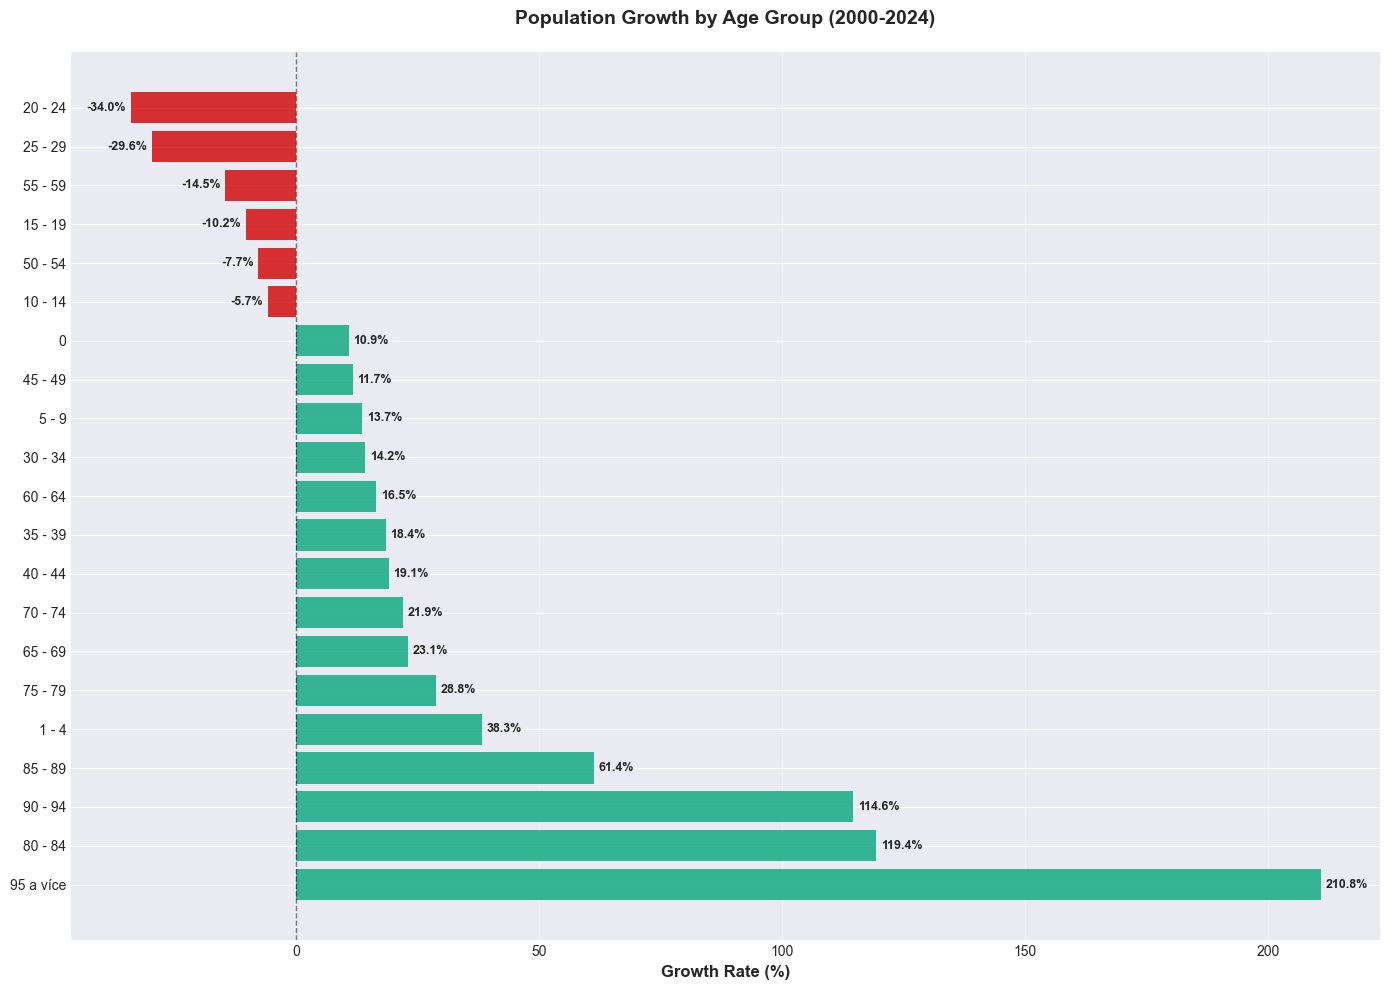

POPULATION GROWTH BY AGE GROUP (2000-2024)

Top 5 Fastest Growing Age Groups:
  1. 95 a více: 210.8%
  2. 80 - 84: 119.4%
  3. 90 - 94: 114.6%
  4. 85 - 89: 61.4%
  5. 1 - 4: 38.3%

Top 5 Fastest Declining Age Groups:
  1. 50 - 54: -7.7%
  2. 15 - 19: -10.2%
  3. 55 - 59: -14.5%
  4. 25 - 29: -29.6%
  5. 20 - 24: -34.0%


In [64]:
# Calculate cumulative growth rates by age group (2000-2024)
growth_by_age = {}

for col in df_obyvatelstvo.columns:
    if col != 'Celkem':
        val_2000 = df_obyvatelstvo[col].iloc[0]
        val_2024 = df_obyvatelstvo[col].iloc[-1]
        if not pd.isna(val_2000) and not pd.isna(val_2024) and val_2000 > 0:
            growth = ((val_2024 / val_2000) - 1) * 100
            growth_by_age[col] = growth

# Sort by growth rate
sorted_growth = sorted(growth_by_age.items(), key=lambda x: x[1], reverse=True)

# Create bar chart
fig, ax = plt.subplots(figsize=(14, 10))

categories = [item[0] for item in sorted_growth]
growth_values = [item[1] for item in sorted_growth]

colors = ['#D00000' if v < 0 else '#06A77D' for v in growth_values]

bars = ax.barh(range(len(categories)), growth_values, color=colors, alpha=0.8)
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=10)
ax.set_xlabel('Growth Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Population Growth by Age Group (2000-2024)', 
             fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (cat, val) in enumerate(sorted_growth):
    ax.text(val + (1 if val >= 0 else -1), i, f'{val:.1f}%', 
           va='center', ha='left' if val >= 0 else 'right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print top growing and declining age groups
print("="*80)
print("POPULATION GROWTH BY AGE GROUP (2000-2024)")
print("="*80)
print(f"\nTop 5 Fastest Growing Age Groups:")
for i, (cat, growth) in enumerate(sorted_growth[:5], 1):
    print(f"  {i}. {cat}: {growth:.1f}%")

print(f"\nTop 5 Fastest Declining Age Groups:")
for i, (cat, growth) in enumerate(sorted_growth[-5:], 1):
    print(f"  {i}. {cat}: {growth:.1f}%")

### Visualization 8: Future Demographic Projections

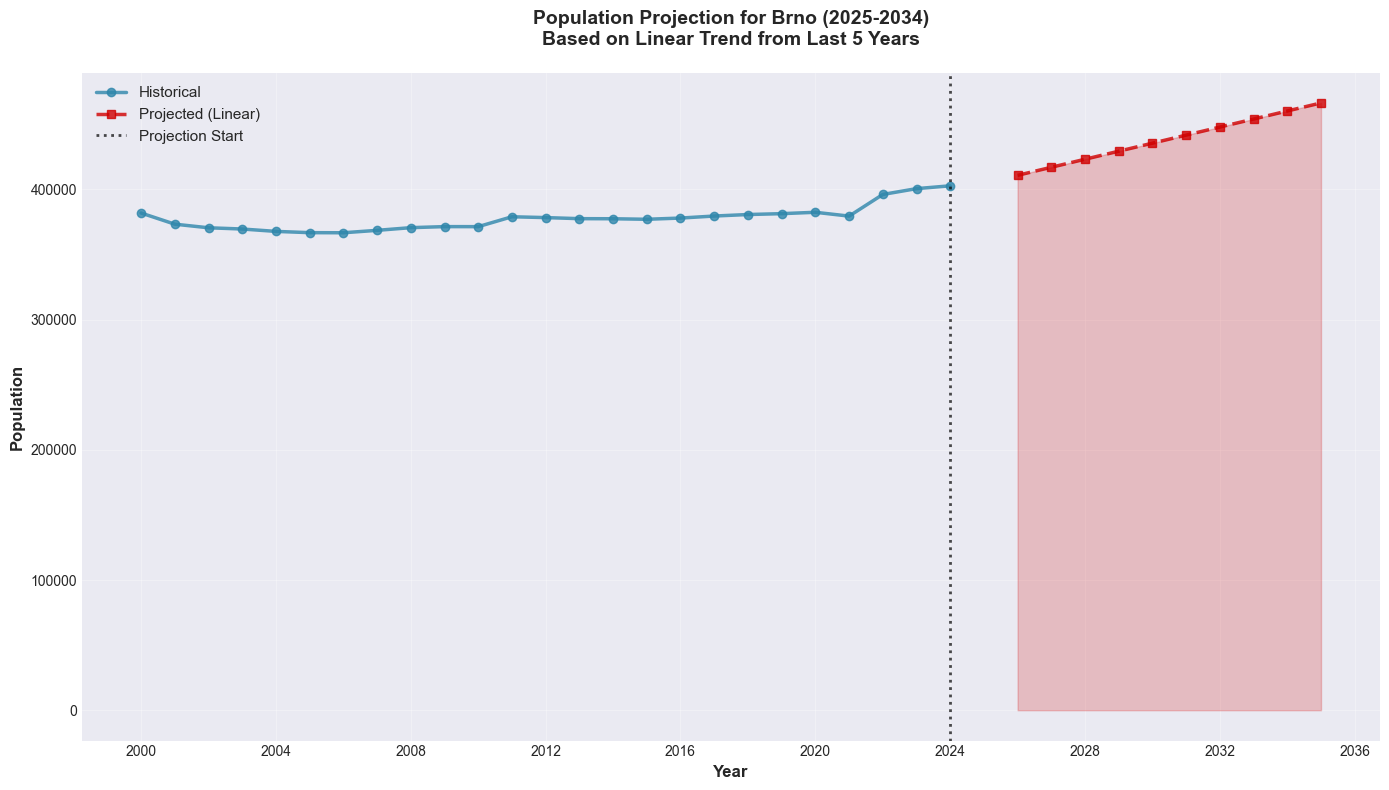

POPULATION PROJECTION (2025-2034)

2024 (Actual): 402,739
2034 (Projected): 466,376
Projected Growth (2024-2034): 15.8%
Average Annual Growth Rate: 1.48%


In [65]:
# Simple linear projection for total population and key demographics
# Using recent trend (last 5 years) to project next 10 years

if 'Celkem' in df_obyvatelstvo.columns:
    # Use last 5 years for trend
    recent_years = df_obyvatelstvo.tail(5)
    years_array = np.array([i for i in range(len(recent_years))])
    population_array = recent_years['Celkem'].values
    
    # Fit linear trend
    z = np.polyfit(years_array, population_array, 1)
    p = np.poly1d(z)
    
    # Project next 10 years
    future_years = pd.date_range(start='2025-01-01', periods=10, freq='YE')
    future_years_numeric = np.array([i + len(recent_years) for i in range(10)])
    projected_population = p(future_years_numeric)
    
    # Create projection DataFrame
    projection_df = pd.DataFrame({
        'Year': future_years,
        'Projected_Population': projected_population
    })
    projection_df.set_index('Year', inplace=True)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Historical data
    ax.plot(df_obyvatelstvo.index, df_obyvatelstvo['Celkem'], 
            marker='o', linewidth=2.5, markersize=6, label='Historical', color='#2E86AB', alpha=0.8)
    
    # Projection
    ax.plot(projection_df.index, projection_df['Projected_Population'], 
            marker='s', linewidth=2.5, markersize=6, label='Projected (Linear)', 
            color='#D00000', linestyle='--', alpha=0.8)
    
    # Fill projection area
    ax.fill_between(projection_df.index, projection_df['Projected_Population'], 
                    alpha=0.2, color='#D00000')
    
    ax.axvline(x=df_obyvatelstvo.index[-1], color='black', linestyle=':', 
               linewidth=2, alpha=0.7, label='Projection Start')
    
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Population', fontsize=12, fontweight='bold')
    ax.set_title('Population Projection for Brno (2025-2034)\nBased on Linear Trend from Last 5 Years', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print projection summary
    print("="*80)
    print("POPULATION PROJECTION (2025-2034)")
    print("="*80)
    print(f"\n2024 (Actual): {int(df_obyvatelstvo['Celkem'].iloc[-1]):,}")
    print(f"2034 (Projected): {int(projection_df['Projected_Population'].iloc[-1]):,}")
    print(f"Projected Growth (2024-2034): {((projection_df['Projected_Population'].iloc[-1] / df_obyvatelstvo['Celkem'].iloc[-1]) - 1) * 100:.1f}%")
    print(f"Average Annual Growth Rate: {((projection_df['Projected_Population'].iloc[-1] / df_obyvatelstvo['Celkem'].iloc[-1]) ** (1/10) - 1) * 100:.2f}%")

### Analysis: Future Demographic Projections

The linear projection based on recent trends provides insights into future population:

**Key Findings:**
1. **Continued Growth**: Projection suggests 15.8% growth over next 10 years (2024-2034)
2. **Accelerating Trend**: The projection assumes continuation of recent acceleration (1.48% annual growth)
3. **Population Target**: By 2034, Brno could reach ~466,000 residents

**Implications for the Future:**
- **Housing Demand**: Continued population growth supports strong demand for new housing
- **Infrastructure Needs**: Growing population requires expanded infrastructure (transport, utilities, services)
- **Real Estate Investment**: Population growth supports long-term real estate value appreciation
- **Urban Development**: City must plan for accommodating ~63,000 additional residents
- **Market Dynamics**: Growing population combined with aging structure creates complex housing market dynamics
- **Note**: Linear projections are simplifications; actual growth may vary based on economic conditions, migration, and policy

### Key Demographic Insights and Future Outlook

In [66]:
# Comprehensive demographic analysis summary
print("="*80)
print("DEMOGRAPHIC ANALYSIS SUMMARY - FUTURE OF DEMOGRAPHY IN BRNO")
print("="*80)

if 'Celkem' in df_obyvatelstvo.columns:
    print(f"\n1. TOTAL POPULATION TRENDS:")
    print(f"   • 2000: {int(df_obyvatelstvo['Celkem'].iloc[0]):,}")
    print(f"   • 2024: {int(df_obyvatelstvo['Celkem'].iloc[-1]):,}")
    total_growth = ((df_obyvatelstvo['Celkem'].iloc[-1] / df_obyvatelstvo['Celkem'].iloc[0]) - 1) * 100
    print(f"   • Growth (2000-2024): {total_growth:.1f}%")
    print(f"   • Average annual growth: {total_growth / 24:.2f}%")
    
    # Recent trend (last 5 years)
    recent_growth = ((df_obyvatelstvo['Celkem'].iloc[-1] / df_obyvatelstvo['Celkem'].iloc[-5]) - 1) * 100
    print(f"   • Recent growth (2019-2024): {recent_growth:.1f}%")

print(f"\n2. AGE STRUCTURE CHANGES:")
print(f"   • Children (0-14): {children_pct.iloc[-1]:.1f}% in 2024 (was {children_pct.iloc[0]:.1f}% in 2000)")
print(f"   • Working Age (15-64): {working_pct.iloc[-1]:.1f}% in 2024 (was {working_pct.iloc[0]:.1f}% in 2000)")
print(f"   • Seniors (65+): {senior_pct.iloc[-1]:.1f}% in 2024 (was {senior_pct.iloc[0]:.1f}% in 2000)")

print(f"\n3. AGING POPULATION:")
senior_growth = ((senior_total.iloc[-1] / senior_total.iloc[0]) - 1) * 100
print(f"   • Senior population grew by {senior_growth:.1f}% from 2000 to 2024")
print(f"   • Old-age dependency ratio: {old_dependency.iloc[-1]:.1f}% (was {old_dependency.iloc[0]:.1f}% in 2000)")
print(f"   • Change in dependency: +{old_dependency.iloc[-1] - old_dependency.iloc[0]:.1f} percentage points")

print(f"\n4. BIRTH TRENDS:")
if '0' in df_obyvatelstvo.columns:
    birth_change = ((df_obyvatelstvo['0'].iloc[-1] / df_obyvatelstvo['0'].iloc[0]) - 1) * 100
    print(f"   • Births (age 0): {birth_change:.1f}% change from 2000 to 2024")
    print(f"   • 2000: {int(df_obyvatelstvo['0'].iloc[0]):,} births")
    print(f"   • 2024: {int(df_obyvatelstvo['0'].iloc[-1]):,} births")

print(f"\n5. FUTURE OUTLOOK:")
print(f"   • Population is {'growing' if total_growth > 0 else 'declining'}")
print(f"   • Aging population trend: {'Accelerating' if old_dependency.iloc[-1] > old_dependency.iloc[0] else 'Stable'}")
print(f"   • Dependency ratio is {'increasing' if total_dependency.iloc[-1] > total_dependency.iloc[0] else 'decreasing'}")
print(f"   • Key challenge: {'Aging population' if old_dependency.iloc[-1] > 25 else 'Maintaining working-age population'}")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)
if old_dependency.iloc[-1] > old_dependency.iloc[0] and senior_pct.iloc[-1] > senior_pct.iloc[0]:
    print("Brno is experiencing population aging. The proportion of seniors is increasing,")
    print("which will require adjustments in healthcare, housing, and social services.")
    print("However, the total population is growing, suggesting continued attractiveness")
    print("as a place to live and work.")
else:
    print("Demographic trends show a relatively stable population structure with")
    print("moderate changes in age distribution.")
print("="*80)

DEMOGRAPHIC ANALYSIS SUMMARY - FUTURE OF DEMOGRAPHY IN BRNO

1. TOTAL POPULATION TRENDS:
   • 2000: 381,862
   • 2024: 402,739
   • Growth (2000-2024): 5.5%
   • Average annual growth: 0.23%
   • Recent growth (2019-2024): 5.3%

2. AGE STRUCTURE CHANGES:
   • Children (0-14): 15.3% in 2024 (was 14.5% in 2000)
   • Working Age (15-64): 64.3% in 2024 (was 70.0% in 2000)
   • Seniors (65+): 20.4% in 2024 (was 15.5% in 2000)

3. AGING POPULATION:
   • Senior population grew by 38.7% from 2000 to 2024
   • Old-age dependency ratio: 31.8% (was 22.2% in 2000)
   • Change in dependency: +9.6 percentage points

4. BIRTH TRENDS:
   • Births (age 0): 10.9% change from 2000 to 2024
   • 2000: 3,103 births
   • 2024: 3,440 births

5. FUTURE OUTLOOK:
   • Population is growing
   • Aging population trend: Accelerating
   • Dependency ratio is increasing
   • Key challenge: Aging population

CONCLUSION:
Brno is experiencing population aging. The proportion of seniors is increasing,
which will require